# **PyMC Kalman Filter Price Target Model — GaussianRandomWalk state-space**

## Uses PyMC GaussianRandomWalk for latent price state with an observation model for noisy price targets.

### Schema-aligned with:
- MV: `pml.mv_pymc_kalman_pt`
- Catalogue: `SELECT * FROM pml.vw_pymc_feature_catalogue WHERE model_target = 'kalman_pt' ORDER BY pymc_role, feature_role, feature_alias`
- Coords: `SELECT column_name FROM pml.vw_pml_df_coords` (rows where `pymc_role = 'coord'`)

All feature aliases, coords and observed targets derive from the **pml** schema as the single source of truth. `KalmanFilterPriceTarget._resolve_kalman_feature_aliases()` reads the `mutable_predictor` aliases for `model_target = 'kalman_pt'` directly from `pml.vw_pymc_feature_catalogue` (no `public.calculated_features_registry` lookup).




In [1]:
%%sql
SELECT * FROM pml.mv_pymc_kalman_pt mpkp WHERE observed_pt IS NOT NULL AND next_earnings >= '2026-01-01'

,isin,ticker,region,country,trading_country,exchange,unit,style_class,size_class,sector,...,feat_pt_median_drift,feat_coverage_drift,feat_pt_noise_drift,feat_pt_noise_sigma,feat_pt_range_norm,feat_vol_1m,feat_vol_3m,feat_vol_6m,feat_vol_1y,feat_total_return_ytd
0,US67066G1040,NVDA,United States and Canada,US,US,NasdaqGS,USD,Growth,Large Cap,Information Technology,...,0.114942,0.014288,0.215239,52.7013,1.072301,47.39,39.54,37.44,34.72,0.1011
1,CA53681J1030,LAC,United States and Canada,CA,CA,TSX,CAD,Core,Small Cap,Materials,...,-0.007726,0.066667,-0.094226,0.4341,0.145477,78.12,74.49,73.90,135.74,0.0586
2,US3773221029,GKOS,United States and Canada,US,US,NYSE,USD,Growth,Small Cap,Health Care,...,0.069647,-0.013187,-0.118310,11.9896,0.220065,67.82,68.02,59.28,52.56,0.1071
3,US02215L2097,KNTK,United States and Canada,US,US,NYSE,USD,Core,Small Cap,Energy,...,-0.003422,0.015385,-0.105222,2.9451,0.247283,27.15,27.67,32.95,35.62,0.3008
4,US0378331005,AAPL,United States and Canada,US,US,NasdaqGS,USD,Core,Large Cap,Information Technology,...,0.062742,0.014640,0.083754,39.4462,0.595800,17.54,21.71,22.50,22.32,0.1326
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6279,BRVITTACNOR4,VITT3,Latin America and Caribbean,BR,BR,BOVESPA,BRL,Value,Small Cap,Materials,...,-0.040954,-0.066667,2.062658,0.0500,0.019802,54.03,43.12,41.36,41.59,-0.1741
6280,BRPOSIACNOR9,POSI3,Latin America and Caribbean,BR,BR,BOVESPA,BRL,Value,Small Cap,Information Technology,...,-0.058824,-0.050000,-0.131341,0.7364,0.296702,43.63,44.99,41.00,36.99,-0.0451
6281,BRLJQQACNOR5,LJQQ3,Latin America and Caribbean,BR,BR,BOVESPA,BRL,Value,Small Cap,Consumer Discretionary,...,-0.020000,-0.080000,-0.097901,0.5436,0.305087,46.57,74.82,66.90,60.79,-0.4027
6282,BRENJUACNOR9,ENJU3,Latin America and Caribbean,BR,BR,BOVESPA,BRL,Core,Small Cap,Communication Services,...,0.000000,0.000000,0.000000,0.3500,0.424242,43.90,51.46,49.80,44.49,-0.0093


## 1. Notebook Setup & Imports

In [2]:
%%sql
SELECT *
FROM pml.vw_pymc_feature_catalogue
WHERE model_target = 'kalman_pt'
ORDER BY pymc_role, feature_role, feature_alias

,model_target,pymc_role,column_name,category,feature_role,feature_alias,data_type,description
0,kalman_pt,constant_data,price_target_num,analyst_targets,count,n_analysts,double precision,Number of analyst price targets
1,kalman_pt,coord,country,classification,categorical,country,text,Country of incorporation
2,kalman_pt,coord,exchange,classification,categorical,exchange,text,Stock exchange
3,kalman_pt,coord,industry,classification,categorical,industry,text,GICS industry classification
4,kalman_pt,coord,region,classification,categorical,region,text,Geographic region
...,...,...,...,...,...,...,...,...
88,kalman_pt,observed,total_return_ytd,total_return,target,feat_total_return_ytd,double precision,Total return year-to-date
89,kalman_pt,observed,price_target,analyst_targets,target,observed_pt,double precision,Analyst consensus price target
90,kalman_pt,observed,price_target_high,analyst_targets,target,price_target_high,double precision,High analyst price target
91,kalman_pt,observed,price_target_low,analyst_targets,target,price_target_low,double precision,Low analyst price target


## 1. Notebook Setup & Imports

In [3]:
import warnings

# ArviZ 1.0 split-package imports: arviz-plots owns `style` + plotting,
# arviz-stats owns `summary` / `rhat` / `ess`. Address each submodule directly.
import arviz_plots as azp
import arviz_stats as azs
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import pytensor.tensor as pt
import seaborn as sns
import xarray as xr
from arviz_plots import visuals as azv  # low-level primitives for custom composition

warnings.filterwarnings('ignore', category=FutureWarning)
RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

# --- Plotting backend + theme ------------------------------------------------
# Pin the arviz-plots backend so PlotCollection / plot_* render through
# matplotlib (the notebook's dark-theme target). `arviz-vibrant` is the bright
# arviz 1.x palette that reads well on a dark background — the old 0.x
# `arviz-darkgrid` style does not exist in arviz-plots 1.x (its silent failure
# in the previous revision is why the arviz plots were rendering un-themed).
azp.backend = 'matplotlib'
plt.style.use('dark_background')
try:
    azp.style.use('arviz-vibrant')
except (OSError, ValueError, AttributeError):
    pass
sns.set_theme(style='darkgrid', context='notebook',
              rc={
                  'figure.facecolor': '#1e1e1e',
                  'axes.facecolor': '#2a2a2a',
                  'savefig.facecolor': '#1e1e1e',
                  'axes.edgecolor': '#cccccc',
                  'axes.labelcolor': '#e6e6e6',
                  'xtick.color': '#e6e6e6',
                  'ytick.color': '#e6e6e6',
                  'text.color': '#e6e6e6',
                  'grid.color': '#555555',
              })

# arviz_plots builds its per-chain colour aesthetic by reshaping the *active*
# matplotlib colour cycle. seaborn.set_theme() installs that cycle as RGB
# tuples (e.g. (0.29, 0.44, 0.69)); arviz_plots then does
# `np.array(colours[:n_chains]).reshape((n_chains,))`, which for 4 chains turns
# 4 RGB triples into an array of size 12 and raises
# 'cannot reshape array of size 12 into shape (4,)'. Re-express the cycle as
# hex strings so plot_trace / PlotCollection work under the seaborn theme.
from cycler import cycler as _cycler
import matplotlib.colors as _mcolors
_cycle_cols = plt.rcParams['axes.prop_cycle'].by_key().get('color', [])
if _cycle_cols and not all(isinstance(_c, str) for _c in _cycle_cols):
    plt.rcParams['axes.prop_cycle'] = _cycler(
        color=[_mcolors.to_hex(_c) for _c in _cycle_cols]
    )
plt.rcParams['figure.dpi'] = 110

print(f'kalman_df         : {kalman_df.shape}')
print(f'feature_catalogue : {feature_catalogue.shape}')
if 'model_target' in feature_catalogue.columns:
    _mt = feature_catalogue['model_target']
    if not (_mt == 'kalman_pt').all():
        warnings.warn("feature_catalogue is not fully filtered to model_target='kalman_pt'.")

C:\Users\markm\PML_Finance_Project\.venv\Lib\site-packages\pytensor\configparser.py:309: UserWarning: PyTensor does not recognise this flag: device
  warnings.warn(f"PyTensor does not recognise this flag: {key}")


kalman_df         : (6284, 44)
feature_catalogue : (93, 8)


### 1.1 Custom visualization — Kalman price-target path (`arviz_plots` composition)

The headline view for this model is the **Kalman-smoothed price target over time**:
the latent state is a noisy walk through the observed analyst targets, and the value
of a state-space filter is that it returns a *credible band*, not just a point.

`plot_price_target_path()` composes that view with the `arviz_plots` low-level API
(`PlotCollection.grid` + `arviz_plots.visuals`) rather than a one-shot `plot_*`
helper — see the [compose-your-own-plot tutorial](https://python.arviz.org/projects/plots/en/latest/tutorials/compose_own_plot.html).
It layers, on a single time axis:

- **nested HDI bands** (94% + 50%) of the posterior latent `state`, darkening inward;
- the **posterior-median** smoothed path;
- the **observed** analyst price targets as points;
- a dashed **last-price** reference line.

It reads the `time` coordinate straight off the posterior (a `DatetimeIndex` when the
model was fit with `dates=`), so it works for both the single-ISIN time-series filter
(Section 11) and any future per-ISIN posterior carrying a `state`/`time` pair.

In [4]:
from typing import Optional, Sequence


def plot_price_target_path(
    idata,
    *,
    state_var: str = "state",
    observed: Optional[np.ndarray] = None,
    dates: Optional[pd.DatetimeIndex] = None,
    last_price: Optional[float] = None,
    ticker: Optional[str] = None,
    hdi_probs: Sequence[float] = (0.94, 0.5),
    figsize: tuple[float, float] = (11, 5),
    color: str = "#56b4e9",
    observed_color: str = "#ffb000",
):
    """Compose a Kalman-smoothed price-target trajectory with ``arviz_plots``.

    Builds the plot from the low-level composition API
    (:meth:`arviz_plots.PlotCollection.grid` + :mod:`arviz_plots.visuals`) so the
    posterior latent state, its credible bands, and the raw observations share a
    single time axis.

    Parameters
    ----------
    idata
        Inference object whose ``posterior`` holds ``state_var`` over a ``time``
        dim (e.g. the output of :meth:`KalmanFilterPriceTarget.fit`).
    state_var
        Posterior variable carrying the price-space latent state. Default ``"state"``.
    observed
        Observed analyst price targets aligned to the ``time`` axis. Plotted as
        points when supplied.
    dates
        Time index aligned to the ``time`` dim. When omitted, the ``time`` coord on
        the posterior is used (and treated as datetime if it parses as such).
    last_price
        Reference last price; drawn as a dashed horizontal line when finite.
    ticker
        Optional label for the title.
    hdi_probs
        Credible-interval masses to shade, widest first.
    figsize, color, observed_color
        Cosmetic controls.

    Returns
    -------
    arviz_plots.PlotCollection
        The composed collection (already drawn); call ``.show()`` to display.
    """
    post = idata.posterior[state_var]
    if "time" not in post.dims:
        raise ValueError(f"{state_var!r} has no 'time' dim; dims={post.dims}.")
    n_time = post.sizes["time"]

    # Resolve the x-axis: prefer explicit `dates`, else the posterior `time` coord.
    # Only treat the coord as datetime when its dtype actually is one -- otherwise
    # pd.to_datetime would silently coerce a plain integer time index into
    # 1970-epoch timestamps. `bool(np.asarray(...).all())` collapses the mask to a
    # scalar (a bare `.all()` on a Series/Index is ambiguous as a truth value).
    if dates is None and "time" in post.coords:
        coord_vals = np.asarray(post["time"].values)
        if np.issubdtype(coord_vals.dtype, np.datetime64):
            dates = pd.DatetimeIndex(coord_vals)
        elif coord_vals.dtype == object:
            parsed = pd.to_datetime(coord_vals, errors="coerce")
            if not bool(np.asarray(pd.isna(parsed)).all()):
                dates = pd.DatetimeIndex(parsed)
    use_dates = (
        dates is not None
        and len(dates) == n_time
        and not bool(np.asarray(pd.isna(dates)).all())
    )
    x = xr.DataArray(
        mdates.date2num(np.asarray(dates)) if use_dates else np.arange(n_time),
        dims="time",
    )

    median = post.median(("chain", "draw"))
    ds = post.to_dataset()

    pc = azp.PlotCollection.grid(
        ds, backend="matplotlib", figure_kwargs={"figsize": figsize}
    )
    target = pc.get_target(state_var, {})  # raw matplotlib Axes

    # Nested HDI bands: widest first with the lightest alpha so inner masses darken.
    band_alphas = (0.16, 0.28, 0.40, 0.50)
    for prob, alpha in zip(sorted(hdi_probs, reverse=True), band_alphas):
        band = post.azstats.hdi(prob=prob)
        azv.fill_between_y(
            median, target, x=x,
            y_bottom=band.sel(ci_bound="lower"),
            y_top=band.sel(ci_bound="upper"),
            facecolor=color, alpha=alpha, edgecolor="none",
        )

    azv.line_xy(median, target, x=x, y=median, color=color, linewidth=2.2, zorder=4)

    if observed is not None:
        obs = xr.DataArray(np.asarray(observed, dtype="float64"), dims="time")
        azv.scatter_xy(
            median, target, x=x, y=obs,
            color=observed_color, s=34, zorder=6,
            edgecolor="#1e1e1e", linewidth=0.6,
        )

    if last_price is not None and np.isfinite(last_price):
        target.axhline(float(last_price), ls="--", color="#bbbbbb", lw=1.2, zorder=2)

    if use_dates:
        target.xaxis_date()
        target.xaxis.set_major_formatter(mdates.DateFormatter("%b %y"))

    azv.labelled_x(median, target, text="as-of date" if use_dates else "time step")
    azv.labelled_y(median, target, text="price target")
    title = "Kalman-smoothed price-target path"
    if ticker:
        title += f" — {ticker}"
    target.set_title(title)

    # Hand-built legend (composition primitives don't auto-register labels).
    from matplotlib.lines import Line2D
    from matplotlib.patches import Patch

    handles = [
        Line2D([0], [0], color=color, lw=2.2, label="posterior median state"),
        Patch(facecolor=color, alpha=0.40,
              label=f"{int(max(hdi_probs) * 100)}% / {int(min(hdi_probs) * 100)}% HDI"),
    ]
    if observed is not None:
        handles.append(Line2D([0], [0], marker="o", linestyle="none",
                              markerfacecolor=observed_color, markeredgecolor="#1e1e1e",
                              label="observed price target"))
    if last_price is not None and np.isfinite(last_price):
        handles.append(Line2D([0], [0], ls="--", color="#bbbbbb", label="last price"))
    target.legend(handles=handles, fontsize=8, loc="best", framealpha=0.25)

    return pc


print("Defined plot_price_target_path() — Kalman price-target path via arviz_plots composition.")

Defined plot_price_target_path() — Kalman price-target path via arviz_plots composition.


## 2. Exploratory Data Analysis (EDA) — `kalman_df`

Source: `pml.mv_pymc_kalman_pt` (one row per ISIN, filtered to `observed_pt IS NOT NULL`).
We resolve column roles from `pml.vw_pymc_feature_catalogue` and fall back to the
known MV schema where the catalogue has no `kalman_pt` rows yet.

In [5]:
# Map feature_catalogue -> columns actually present in kalman_df
catalogue = feature_catalogue.copy()
catalogue['present'] = catalogue['feature_alias'].isin(kalman_df.columns)

role_summary = (
    catalogue.groupby(['pymc_role', 'feature_role'])['present']
    .agg(n_columns='size', n_present='sum')
    .reset_index()
)
role_summary

,pymc_role,feature_role,n_columns,n_present
0,constant_data,count,1,1
1,coord,categorical,9,9
2,coord,date,6,6
3,derived_input,historical,60,0
4,mutable_predictor,predictor,11,11
5,observed,target,6,6


In [6]:
# Resolve column groups by pymc_role from pml.vw_pymc_feature_catalogue (single
# source of truth). PREDICTOR_COLS mirrors
# KalmanFilterPriceTarget._resolve_kalman_feature_aliases() — i.e. the
# mutable_predictor aliases for model_target='kalman_pt'. KNOWN_FEATURES below is
# only a resilience fallback for MV columns absent from the catalogue snapshot.
present = catalogue.loc[catalogue['present']]
PREDICTOR_COLS = present.loc[present['pymc_role'] == 'mutable_predictor', 'feature_alias'].tolist()
COORD_COLS = present.loc[present['pymc_role'] == 'coord', 'feature_alias'].tolist()
RESPONSE_COLS = present.loc[present['pymc_role'].isin(['response', 'observed']), 'feature_alias'].tolist()

# Canonical schema of pml.mv_pymc_kalman_pt (single source of truth in SQL).
# The extended MV emits a per-trail drift feature for every price_* / price_target_*
# family (mean / high / low / median / raw price / analyst-count / dispersion).
KNOWN_FEATURES = ['feat_pt_drift', 'feat_price_drift',
                  'feat_pt_high_drift', 'feat_pt_low_drift', 'feat_pt_median_drift',
                  'feat_coverage_drift', 'feat_pt_noise_drift',
                  'feat_pt_noise_sigma', 'feat_pt_range_norm',
                  'feat_vol_1m', 'feat_vol_3m', 'feat_vol_6m', 'feat_vol_1y',
                  'feat_total_return_ytd']
for col in KNOWN_FEATURES:
    if col in kalman_df.columns and col not in PREDICTOR_COLS:
        PREDICTOR_COLS.append(col)
if 'observed_pt' in kalman_df.columns and 'observed_pt' not in RESPONSE_COLS:
    RESPONSE_COLS.append('observed_pt')

# Hierarchical classification coords (categorical group effects) are distinct
# from the fiscal-calendar DATE anchors. Both carry pymc_role='coord' (sourced
# from pml.vw_pml_df_coords), but the
# date anchors define the single-security *time axis* (used in section 11) and
# must NOT be treated as categorical effects in the cross-sectional model.
CLASSIFICATION_COORDS = [c for c in (
    'isin', 'ticker', 'region', 'country', 'trading_country',
    'exchange', 'unit', 'style_class', 'size_class', 'sector', 'industry'
) if c in kalman_df.columns]
FISCAL_CALENDAR_COLS = [c for c in (
    'income_statement_report_date', 'next_earnings', 'fy_end_date',
    'next_income_statement_report_date', 'next_fy_end_date', 'expected_report_date'
) if c in kalman_df.columns]
DAY_COUNT_COLS = [c for c in (
    'days_to_next_earnings', 'days_since_last_report', 'days_to_next_fy_end',
    'days_to_next_report', 'days_to_expected_report', 'days_to_fy_end'
) if c in kalman_df.columns]
# Keep only non-date coords as categorical-effect candidates; fall back to the
# curated classification list (mirrors pml.vw_pml_df_coords) when the catalogue
# exposes no plain coords.
COORD_COLS = [c for c in COORD_COLS if c not in FISCAL_CALENDAR_COLS] or CLASSIFICATION_COORDS.copy()

print(f'#predictors     : {len(PREDICTOR_COLS)} -> {PREDICTOR_COLS}')
print(f'#response       : {len(RESPONSE_COLS)} -> {RESPONSE_COLS}')
print(f'#coords         : {len(COORD_COLS)} -> {COORD_COLS}')
print(f'#classification : {len(CLASSIFICATION_COORDS)} -> {CLASSIFICATION_COORDS}')
print(f'#fiscal-calendar: {len(FISCAL_CALENDAR_COLS)} -> {FISCAL_CALENDAR_COLS}')
print(f'#day-count      : {len(DAY_COUNT_COLS)} -> {DAY_COUNT_COLS}')

#predictors     : 21 -> ['days_since_last_report', 'days_to_expected_report', 'days_to_fy_end', 'days_to_next_earnings', 'days_to_next_fy_end', 'days_to_next_report', 'feat_vol_1m', 'feat_vol_1y', 'feat_vol_3m', 'feat_vol_6m', 'last_price', 'feat_pt_drift', 'feat_price_drift', 'feat_pt_high_drift', 'feat_pt_low_drift', 'feat_pt_median_drift', 'feat_coverage_drift', 'feat_pt_noise_drift', 'feat_pt_noise_sigma', 'feat_pt_range_norm', 'feat_total_return_ytd']
#response       : 6 -> ['feat_pt_noise_sigma', 'feat_total_return_ytd', 'observed_pt', 'price_target_high', 'price_target_low', 'price_target_median']
#coords         : 9 -> ['country', 'exchange', 'industry', 'region', 'sector', 'size_class', 'style_class', 'trading_country', 'unit']
#classification : 11 -> ['isin', 'ticker', 'region', 'country', 'trading_country', 'exchange', 'unit', 'style_class', 'size_class', 'sector', 'industry']
#fiscal-calendar: 6 -> ['income_statement_report_date', 'next_earnings', 'fy_end_date', 'next_incom

In [7]:
# 2.1 Shape, dtype, missingness overview.
eda_overview = pd.DataFrame({
    'dtype': kalman_df.dtypes.astype(str),
    'n_missing': kalman_df.isna().sum(),
    'pct_missing': (kalman_df.isna().mean() * 100).round(1),
    'n_unique': kalman_df.nunique(),
})
print(f'kalman_df shape: {kalman_df.shape}')
eda_overview.sort_values('pct_missing', ascending=False).head(30)

kalman_df shape: (6284, 44)


,dtype,n_missing,pct_missing,n_unique
feat_total_return_ytd,float64,43,0.7,4733
next_fy_end_date,str,39,0.6,19
fy_end_date,str,39,0.6,19
days_to_next_fy_end,float64,39,0.6,19
days_to_fy_end,float64,39,0.6,19
feat_pt_noise_drift,float64,18,0.3,6086
expected_report_date,str,9,0.1,86
days_since_last_report,float64,9,0.1,65
income_statement_report_date,str,9,0.1,65
days_to_next_report,float64,9,0.1,83


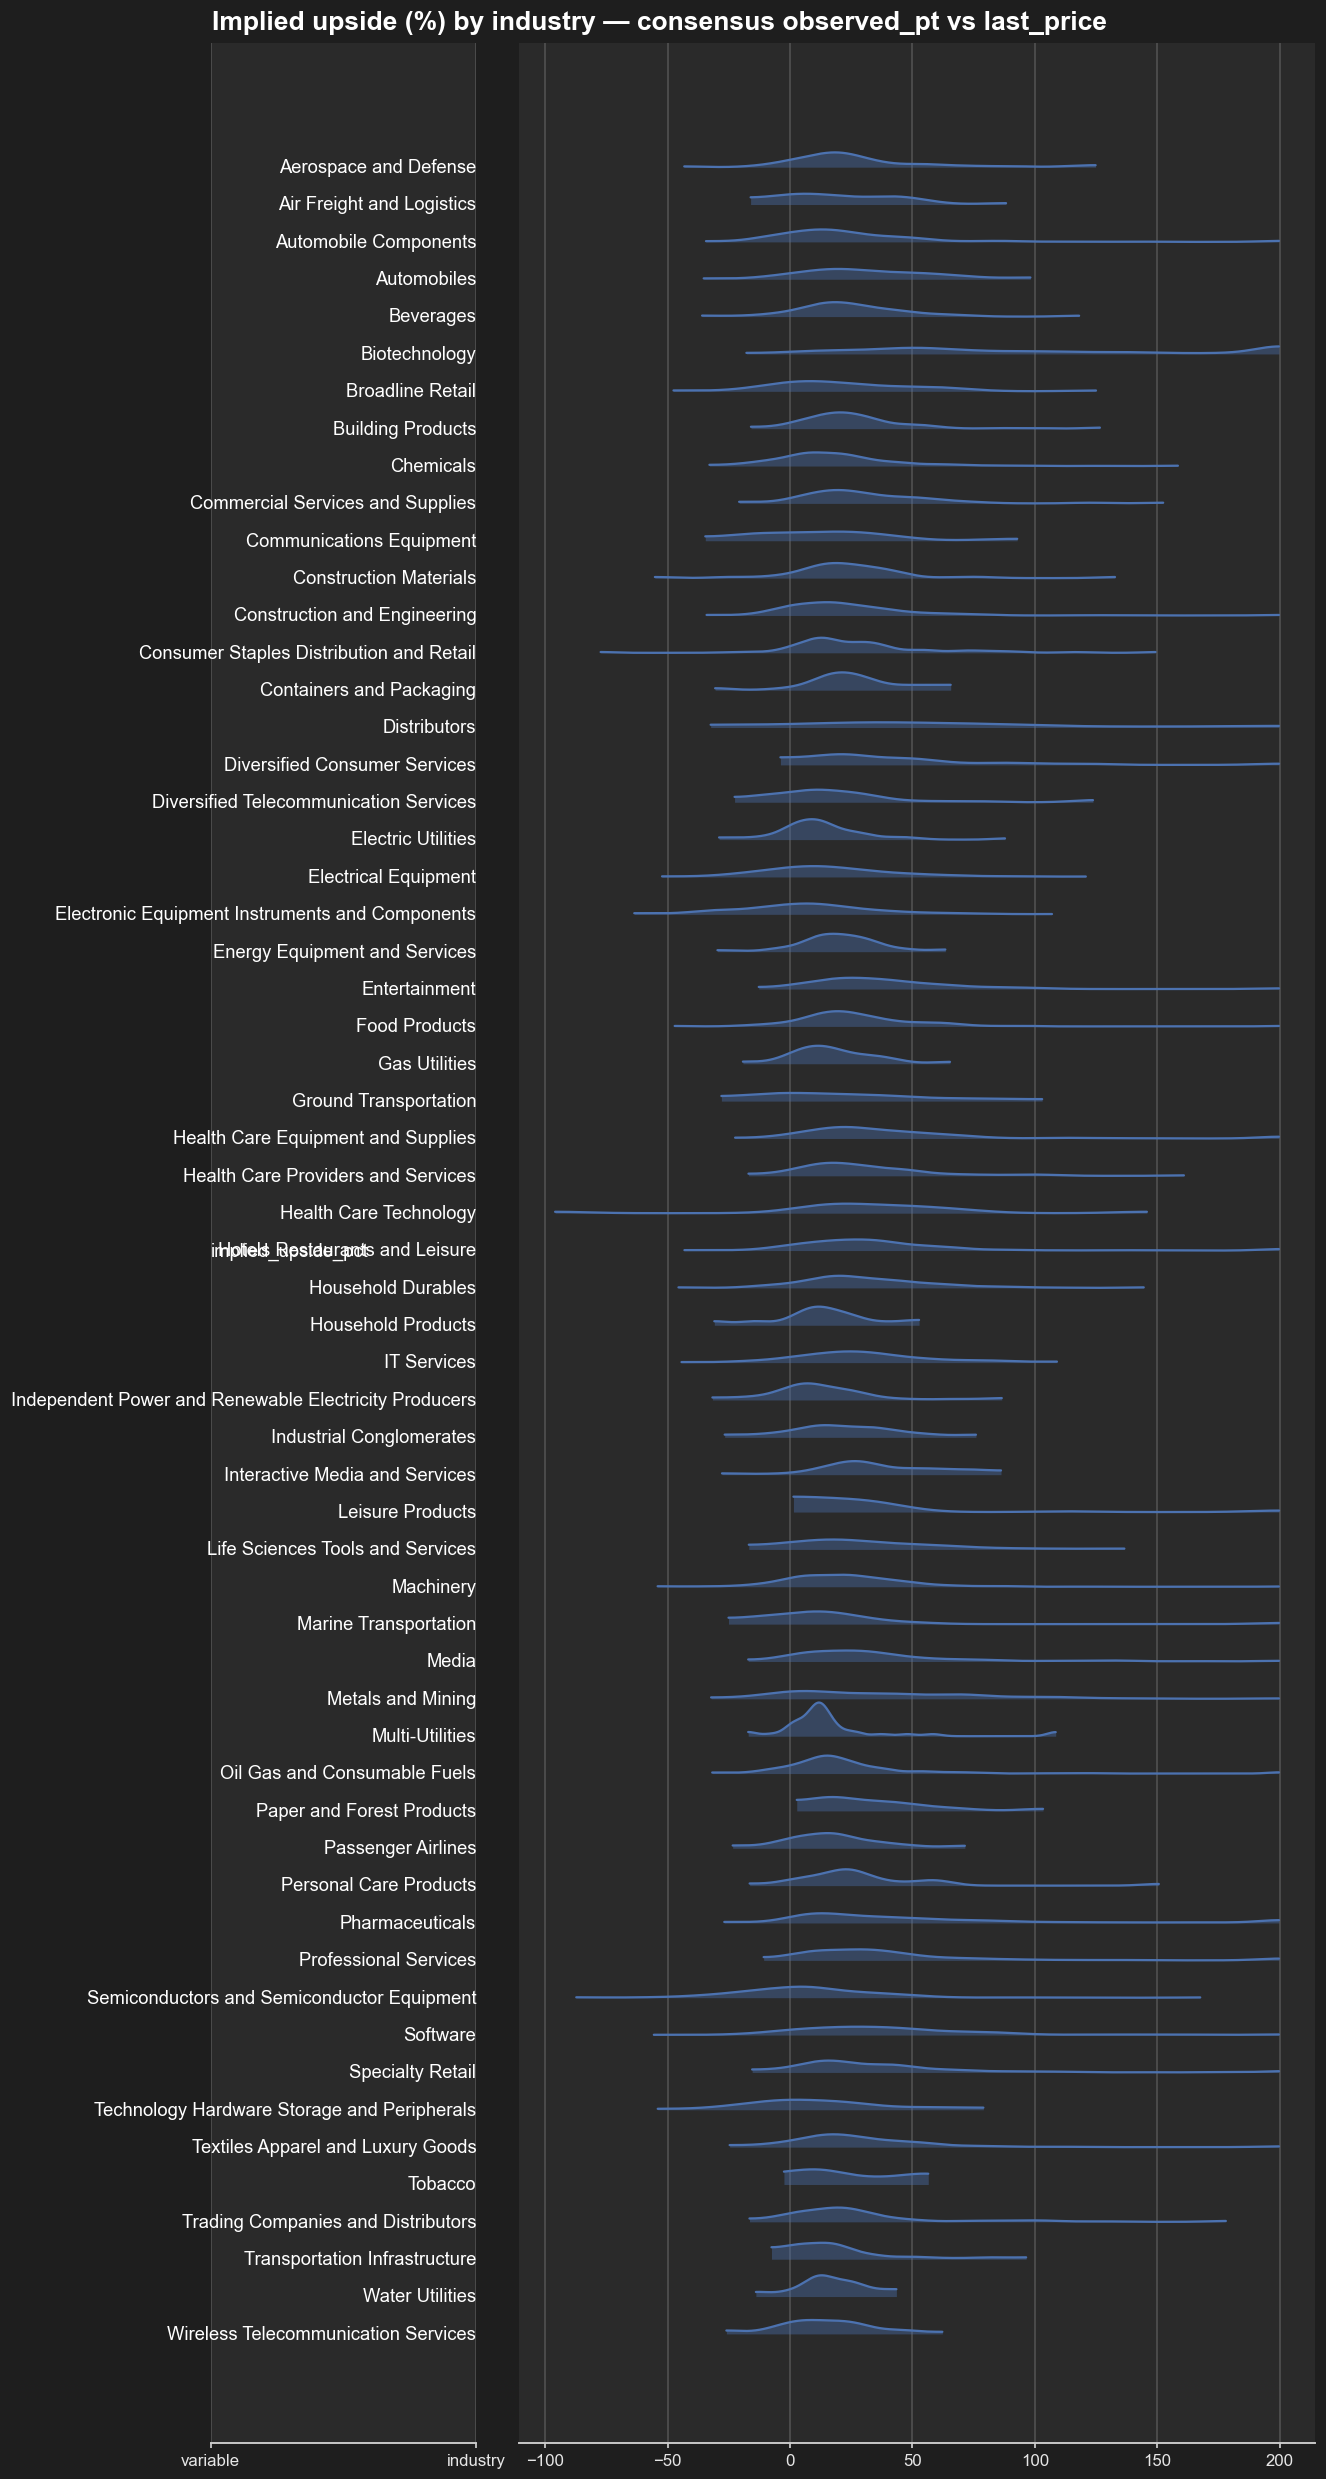

count    6284.000000
mean       28.226821
std        36.016110
min       -96.209386
25%         7.458465
50%        21.062761
75%        40.394930
max       200.000000
Name: upside_pct, dtype: float64

In [8]:
# 2.2 Expected upside by industry - arviz_plots ridge.
# Replaces the previous 2x2 panel histogram. Distributional view of the raw
# implied upside ((observed_pt / last_price) - 1) per industry, drawn as a
# stacked ridge plot so cross-industry shape differences are immediately visible.
import arviz_plots as azp


_d = kalman_df[(kalman_df['observed_pt'] > 0) & (kalman_df['last_price'] > 0)].copy()
_d['upside_pct'] = (_d['observed_pt'] / _d['last_price'] - 1.0) * 100.0
_d['upside_pct'] = _d['upside_pct'].clip(-100, 200)
_d['industry'] = (_d['industry'] if 'industry' in _d.columns
                  else pd.Series('Unknown', index=_d.index))
_d['industry'] = _d['industry'].fillna('Unknown').astype(str)

# Keep industries with enough names to form a meaningful density.
_counts = _d['industry'].value_counts()
_keep = _counts[_counts >= 5].index.tolist()
_d = _d[_d['industry'].isin(_keep)]

# Pack as (industry, sample) into a Dataset so arviz_plots treats `industry`
# as the ridge facet dimension.
_industries = sorted(_d['industry'].unique())
_max_n = int(_d['industry'].value_counts().max())
_arr = np.full((len(_industries), _max_n), np.nan)
for i, ind in enumerate(_industries):
    vals = _d.loc[_d['industry'] == ind, 'upside_pct'].to_numpy()
    _arr[i, :len(vals)] = vals
_ds_ridge = xr.Dataset(
    {'implied_upside_pct': (('industry', 'sample'), _arr)},
    coords={'industry': _industries},
)

pc = azp.plot_ridge(_ds_ridge, var_names=['implied_upside_pct'],
                    sample_dims=['sample'], combined=True)
# arviz-vibrant sets figure.constrained_layout.use=True, so plt.tight_layout() would
# swap that engine out and plt.suptitle(y=1.02) sits off-canvas; title via the PC.
pc.add_title('Implied upside (%) by industry — consensus observed_pt vs last_price')
pc.show()

_d['upside_pct'].describe()


In [9]:
# 2.3 Classification-coord cardinality.
card = {c: kalman_df[c].nunique() for c in CLASSIFICATION_COORDS}
pd.Series(card).sort_values(ascending=False)

isin               6284
ticker             6023
country              82
exchange             81
trading_country      64
industry             59
unit                 49
sector                9
region                5
size_class            3
style_class           3
dtype: int64

### 2.4 Bayesian-flavoured EDA — drift features, noise wideners & feature correlations

The remaining EDA treats the `mv_pymc_kalman_pt` `feat_*` columns through the lens of
their **state-space role** (Section 3), so the EDA already previews how each column will
enter the model:

- **drift features** (`feat_*_drift`, `feat_total_return_ytd`) → the state-transition mean
  (`beta` slopes on the log-uplift);
- **noise wideners** (`feat_pt_range_norm`, `feat_pt_noise_sigma`, `feat_vol_{1m,3m,6m,1y}`)
  → the measurement-noise scale `sigma_obs`.

We use **`arviz_stats.summary`** on a tiny `xarray.Dataset` wrapper to get HDI-style
distributional summaries on the *raw data*, **`arviz_plots`** ridge/dist views for the
feature marginals, and matplotlib/seaborn for the correlation and term-structure views.#%% md

In [10]:
# 2.4a Treat the raw feat_* columns as a pseudo "sample" dimension so arviz-stats
# can give HDI-style distributional summaries side-by-side with pandas describe().
# This is purely descriptive (no model) but reuses the same arviz machinery the
# posterior summaries use downstream, keeping the EDA visually consistent.
EDA_DRIFT = [c for c in ('feat_pt_drift', 'feat_price_drift', 'feat_pt_high_drift',
                         'feat_pt_low_drift', 'feat_pt_median_drift',
                         'feat_coverage_drift', 'feat_pt_noise_drift',
                         'feat_total_return_ytd')
             if c in kalman_df.columns]
EDA_NOISE = [c for c in ('feat_pt_range_norm', 'feat_pt_noise_sigma',
                         'feat_vol_1m', 'feat_vol_3m', 'feat_vol_6m', 'feat_vol_1y')
             if c in kalman_df.columns]
EDA_FEATURES = EDA_DRIFT + EDA_NOISE

# Winsorise to robust 1/99 pct so a handful of extreme analyst trails don't blow
# up the descriptive scale (mirrors the SQL pml.winsorise helper semantics).
_eda = kalman_df[EDA_FEATURES].astype('float64')
_lo = _eda.quantile(0.01)
_hi = _eda.quantile(0.99)
_eda_w = _eda.clip(lower=_lo, upper=_hi, axis=1)

# Pack each feature along a shared 1-D "sample" dimension so azs.summary reports
# mean/sd/HDI per feature. Per-column missingness differs, so we keep the full
# (winsorised) column length and let `skipna=True` drop NaNs per feature -- giving
# each variable a common dim name without the ragged-length problem that arises
# from calling .dropna() column-by-column.
_eda_ds = xr.Dataset(
    {col: ('sample', _eda_w[col].to_numpy()) for col in EDA_FEATURES}
)
# kind='stats' (mean/sd/HDI) needs no chain/draw diagnostics, so we summarise
# directly over the lone 'sample' dim -- no fake chain/draw grid required.
feat_summary = azs.summary(
    _eda_ds, var_names=EDA_FEATURES, kind='stats', round_to=4,
    sample_dims='sample', skipna=True,
)
print(f'Distributional summary (winsorised 1/99 pct) for {len(EDA_FEATURES)} feat_* columns:')
feat_summary

Distributional summary (winsorised 1/99 pct) for 14 feat_* columns:


,mean,sd,eti89_lb,eti89_ub
feat_pt_drift,0.0503,0.1063,-0.0716,0.2504
feat_price_drift,0.0658,0.1405,-0.0915,0.3319
feat_pt_high_drift,0.0547,0.1154,-0.0663,0.2735
feat_pt_low_drift,0.0508,0.1143,-0.0844,0.2590
feat_pt_median_drift,0.0532,0.1112,-0.0730,0.2640
feat_coverage_drift,0.0287,0.0829,-0.0667,0.2000
feat_pt_noise_drift,0.1611,0.3866,-0.1438,0.8045
feat_total_return_ytd,0.1356,0.4242,-0.3113,0.8801
feat_pt_range_norm,0.4437,0.2959,0.0729,0.9979
feat_pt_noise_sigma,526.8244,3189.9002,0.2247,675.3261


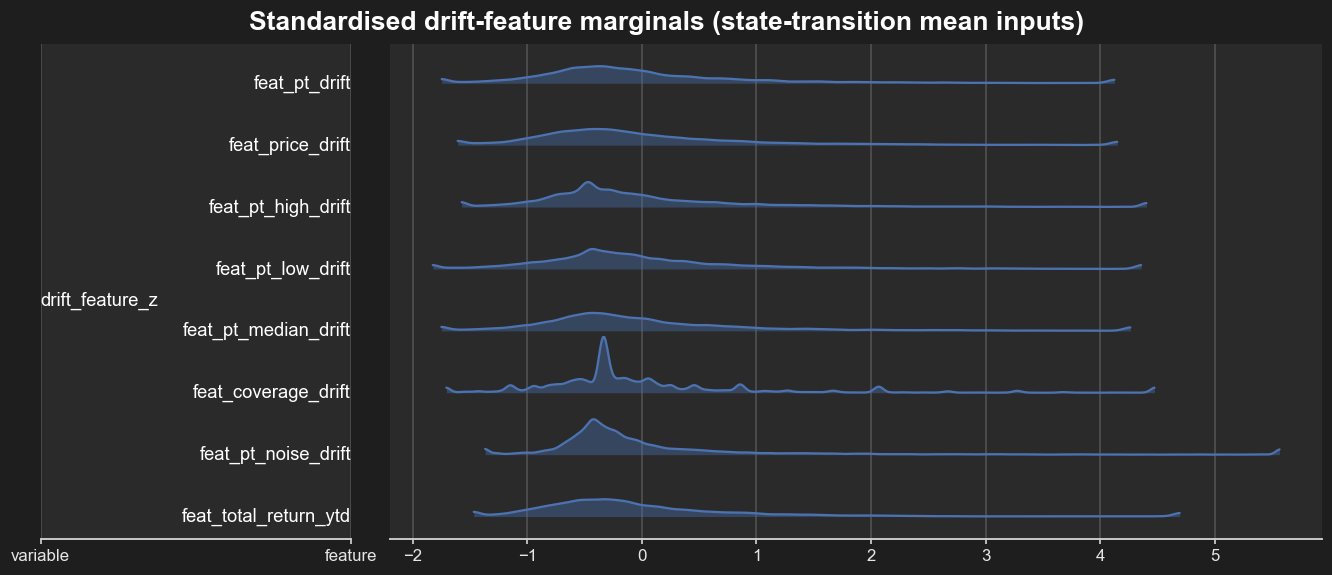

In [11]:
# 2.4b Drift-feature marginals as an arviz_plots ridge — one density per feature.
# These are the inputs to the state-transition mean (beta regression on log-uplift),
# so a ridge makes their relative location/scale directly comparable. Standardised
# (z-scored) so features on different native scales share a common axis.
_drift_std = ((_eda_w[EDA_DRIFT] - _eda_w[EDA_DRIFT].mean())
              / _eda_w[EDA_DRIFT].std(ddof=0).replace(0, 1.0)).dropna()

_n = len(_drift_std)
_drift_arr = np.full((len(EDA_DRIFT), _n), np.nan)
for i, col in enumerate(EDA_DRIFT):
    _drift_arr[i] = _drift_std[col].to_numpy()
_ds_drift_ridge = xr.Dataset(
    {'drift_feature_z': (('feature', 'sample'), _drift_arr)},
    coords={'feature': EDA_DRIFT},
)

pc = azp.plot_ridge(_ds_drift_ridge, var_names=['drift_feature_z'],
                    sample_dims=['sample'], combined=True)
# Title via the PlotCollection: plt.tight_layout() swaps arviz-vibrant's constrained-
# layout engine and plt.suptitle(y=1.02) sits off the top of the canvas.
pc.add_title('Standardised drift-feature marginals (state-transition mean inputs)')
pc.show()

In [12]:
# 2.4c-helper. SINGLE SOURCE OF TRUTH for the observation-noise wideners.
# Both the §2.4c EDA panel and the §4.2 model containers were independently
# reconstructing (range, consensus-cv, mean-vol, sqrt(n)) with slightly different
# NaN handling (EDA winsorised + clip>=0 on _eda_w; §4.2 fillna(0)+clip>=0 on
# model_df). Diverging EDA-vs-model definitions are exactly how an EDA panel ends
# up describing something the model never sees. We centralise the construction
# here so the picture and the likelihood agree by construction.
#
# Each quantity is returned in the units the measurement model consumes
# (sigma_obs = sigma_obs_base * (1 + range + cv + 0.5*vol) / sqrt(n_analysts)):
#   * range : feat_pt_range_norm                      (normalised target range)
#   * cv    : feat_pt_noise_sigma / last_price         (consensus dispersion CV)
#   * vol   : mean(feat_vol_1m..1y)                     (collapsed vol term-structure)
#   * sqrt_n: sqrt(max(n_analysts, 1))                  (precision denominator)
NOISE_RANGE_COL = 'feat_pt_range_norm' if 'feat_pt_range_norm' in kalman_df.columns else None
NOISE_SIGMA_COL = 'feat_pt_noise_sigma' if 'feat_pt_noise_sigma' in kalman_df.columns else None
VOL_COLS = [c for c in ('feat_vol_1m', 'feat_vol_3m', 'feat_vol_6m', 'feat_vol_1y')
            if c in kalman_df.columns]


def build_noise_wideners(df: pd.DataFrame, *, fillna: bool = True) -> dict[str, np.ndarray]:
    """Model-facing observation-noise wideners for one snapshot frame.

    Parameters
    ----------
    df
        A ``kalman_df``-shaped frame (universe EDA or the modelling ``model_df``).
    fillna
        ``True`` (the §4.2 model contract): missing inputs -> 0 and the
        non-negative wideners are clipped at 0, so ``sigma_obs`` is always finite.
        ``False`` (the EDA contract): keep NaNs and keep the raw signed values, so
        the marginals show the true distribution before the model's 0-fill / clip.

    Returns
    -------
    dict[str, np.ndarray]
        Keys ``range``, ``cv``, ``vol``, ``sqrt_n`` plus the realised per-row
        ``multiplier`` = ``(1 + range + cv + 0.5*vol) / sqrt_n`` (the factor that
        scales ``sigma_obs_base``). EDA-mode quantities are returned un-clipped.
    """
    n = len(df)

    def _col(name):
        s = df[name].astype('float64') if name and name in df.columns \
            else pd.Series(np.nan, index=df.index)
        return s.fillna(0.0) if fillna else s

    range_s = _col(NOISE_RANGE_COL)
    if NOISE_SIGMA_COL and NOISE_SIGMA_COL in df.columns:
        lp = df['last_price'].astype('float64')
        lp = lp.clip(lower=1e-9) if fillna else lp.where(lp > 0)
        cv_s = _col(NOISE_SIGMA_COL) / lp
    else:
        cv_s = pd.Series(0.0 if fillna else np.nan, index=df.index)
    vol_s = (df[VOL_COLS].astype('float64').mean(axis=1) if VOL_COLS
             else pd.Series(0.0 if fillna else np.nan, index=df.index))
    if 'n_analysts' in df.columns:
        n_an = df['n_analysts'].astype('float64').clip(lower=1.0)
    else:
        n_an = pd.Series(1.0, index=df.index)
    sqrt_n = np.sqrt(n_an.to_numpy())

    if fillna:
        # Model contract: non-negative, finite. (cv already >= 0 by construction
        # since sigma and price are non-negative; clip guards float noise.)
        range_s = range_s.clip(lower=0.0)
        cv_s = cv_s.clip(lower=0.0)
        vol_s = vol_s.fillna(0.0).clip(lower=0.0)
        mult = (1.0 + range_s.to_numpy() + cv_s.to_numpy()
                + 0.5 * vol_s.to_numpy()) / sqrt_n
    else:
        # EDA contract: clip only the genuinely-non-negative terms for the
        # multiplier so it stays comparable to the model, but leave the per-feature
        # marginals raw/signed for the panel.
        mult = (1.0 + range_s.clip(lower=0).fillna(0).to_numpy()
                + cv_s.clip(lower=0).fillna(0).to_numpy()
                + 0.5 * vol_s.clip(lower=0).fillna(0).to_numpy()) / sqrt_n

    return {'range': range_s.to_numpy(), 'cv': cv_s.to_numpy(),
            'vol': vol_s.to_numpy(), 'sqrt_n': sqrt_n, 'multiplier': mult}


print('Defined build_noise_wideners() — shared sigma_obs widener construction '
      f'(range={NOISE_RANGE_COL}, sigma={NOISE_SIGMA_COL}, vol={VOL_COLS}).')

Defined build_noise_wideners() — shared sigma_obs widener construction (range=feat_pt_range_norm, sigma=feat_pt_noise_sigma, vol=['feat_vol_1m', 'feat_vol_3m', 'feat_vol_6m', 'feat_vol_1y']).


C:\Users\markm\AppData\Local\Temp\ipykernel_1516\1072463865.py:69: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


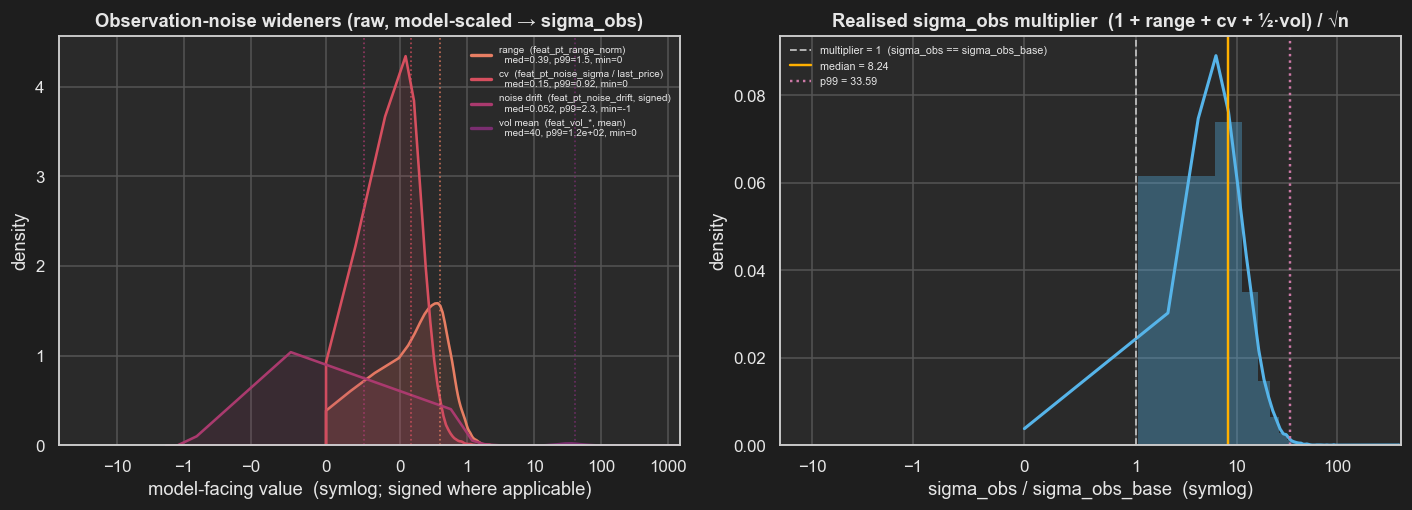

Observation-noise wideners (raw, un-winsorised, model-facing):
  - range  (feat_pt_range_norm)                median=     0.39  p99=       1.5  min=       0  (p99/median tail ratio=3.9)
  - cv  (feat_pt_noise_sigma / last_price)     median=    0.146  p99=     0.921  min=       0  (p99/median tail ratio=6.3)
  - noise drift  (feat_pt_noise_drift, signed) median=    0.052  p99=      2.32  min=      -1  (p99/median tail ratio=44.5)
  - vol mean  (feat_vol_*, mean)               median=     40.2  p99=       123  min=       0  (p99/median tail ratio=3.1)
  sigma_obs multiplier: median=8.24, p99=33.59; 100% of names widen sigma_obs above base, 0% (high-coverage) tighten it below base.


In [13]:
# 2.4c Observation-noise wideners — RAW (un-winsorised, signed allowed) and on the
# SAME model-facing scale §4.2/§5 consume, via the shared build_noise_wideners()
# helper. EDA contract: fillna=False keeps NaNs and the true signed/heavy tails.
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D

_w = build_noise_wideners(kalman_df, fillna=False)  # raw, model-facing quantities

# (label, values, is_signed) — feat_pt_noise_drift is the signed widener from §3.
_widener_specs = [
    ('range  (feat_pt_range_norm)', _w['range'], False),
    ('cv  (feat_pt_noise_sigma / last_price)', _w['cv'], False),
    ('vol mean  (feat_vol_*, mean)', _w['vol'], False),
]
if 'feat_pt_noise_drift' in kalman_df.columns:
    _widener_specs.insert(
        2, ('noise drift  (feat_pt_noise_drift, signed)',
            kalman_df['feat_pt_noise_drift'].astype('float64').to_numpy(), True))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

# (left) clipped-support KDEs on a symlog axis so the four incompatible scales are
# comparable and bounded features don't bleed negative. Median markers + a legend
# carrying median / p99 / min quantify the right-skew that justifies the additive
# non-negative sigma_obs form.
_pal = sns.color_palette('flare', len(_widener_specs))
_rows = []
for (label, arr, is_signed), c in zip(_widener_specs, _pal):
    v = arr[np.isfinite(arr)]
    if v.size <= 5:
        continue
    med, p99 = float(np.nanmedian(v)), float(np.nanpercentile(v, 99))
    sns.kdeplot(v, ax=axes[0], color=c, fill=True, alpha=0.12, lw=1.7,
                clip=(None if is_signed else 0.0, None), bw_adjust=0.9)
    axes[0].axvline(med, color=c, ls=':', lw=1.1, alpha=0.8)
    _rows.append((label, c, med, p99, float(v.min())))

axes[0].set_xscale('symlog', linthresh=0.1)
axes[0].xaxis.set_major_formatter(mticker.ScalarFormatter())
axes[0].set_title('Observation-noise wideners (raw, model-scaled → sigma_obs)')
axes[0].set_xlabel('model-facing value  (symlog; signed where applicable)')
axes[0].set_ylabel('density')
axes[0].legend(handles=[Line2D([0], [0], color=c, lw=2.2,
                               label=f'{lab}\n  med={m:.2g}, p99={p:.2g}, min={mn:.2g}')
                        for lab, c, m, p, mn in _rows],
               fontsize=6.5, framealpha=0.25, loc='upper right')

# (right) the REAL scaled insight: the sigma_obs multiplier that scales
# sigma_obs_base per name — exactly build_noise_wideners()['multiplier'], so the
# panel describes what the §5 likelihood applies. Values >> 1 => names the Kalman
# update distrusts; < 1 (high coverage via sqrt(n)) => leans on raw consensus.
mult = _w['multiplier']
mult = mult[np.isfinite(mult)]
sns.histplot(mult, ax=axes[1], bins=80, stat='density', color='#56b4e9',
             alpha=0.35, edgecolor='none')
sns.kdeplot(mult, ax=axes[1], color='#56b4e9', lw=2.0, clip=(0.0, None))
_mult_med, _mult_p99 = float(np.nanmedian(mult)), float(np.nanpercentile(mult, 99))
axes[1].axvline(1.0, color='#bbbbbb', ls='--', lw=1.2,
                label='multiplier = 1  (sigma_obs == sigma_obs_base)')
axes[1].axvline(_mult_med, color='#ffb000', lw=1.6, label=f'median = {_mult_med:.2f}')
axes[1].axvline(_mult_p99, color='#cc79a7', ls=':', lw=1.6, label=f'p99 = {_mult_p99:.2f}')
axes[1].set_xscale('symlog', linthresh=1.0)
axes[1].xaxis.set_major_formatter(mticker.ScalarFormatter())
axes[1].set_title('Realised sigma_obs multiplier  (1 + range + cv + ½·vol) / √n')
axes[1].set_xlabel('sigma_obs / sigma_obs_base  (symlog)')
axes[1].set_ylabel('density')
axes[1].legend(fontsize=7, framealpha=0.25)

plt.tight_layout()
plt.show()

print('Observation-noise wideners (raw, un-winsorised, model-facing):')
for lab, _c, m, p, mn in _rows:
    print(f'  - {lab:<42s} median={m:>9.3g}  p99={p:>10.3g}  min={mn:>8.3g}  '
          f'(p99/median tail ratio={p / m if m else float("nan"):.1f})')
print(f'  sigma_obs multiplier: median={_mult_med:.2f}, p99={_mult_p99:.2f}; '
      f'{(mult > 1.0).mean() * 100:.0f}% of names widen sigma_obs above base, '
      f'{(mult < 1.0).mean() * 100:.0f}% (high-coverage) tighten it below base.')

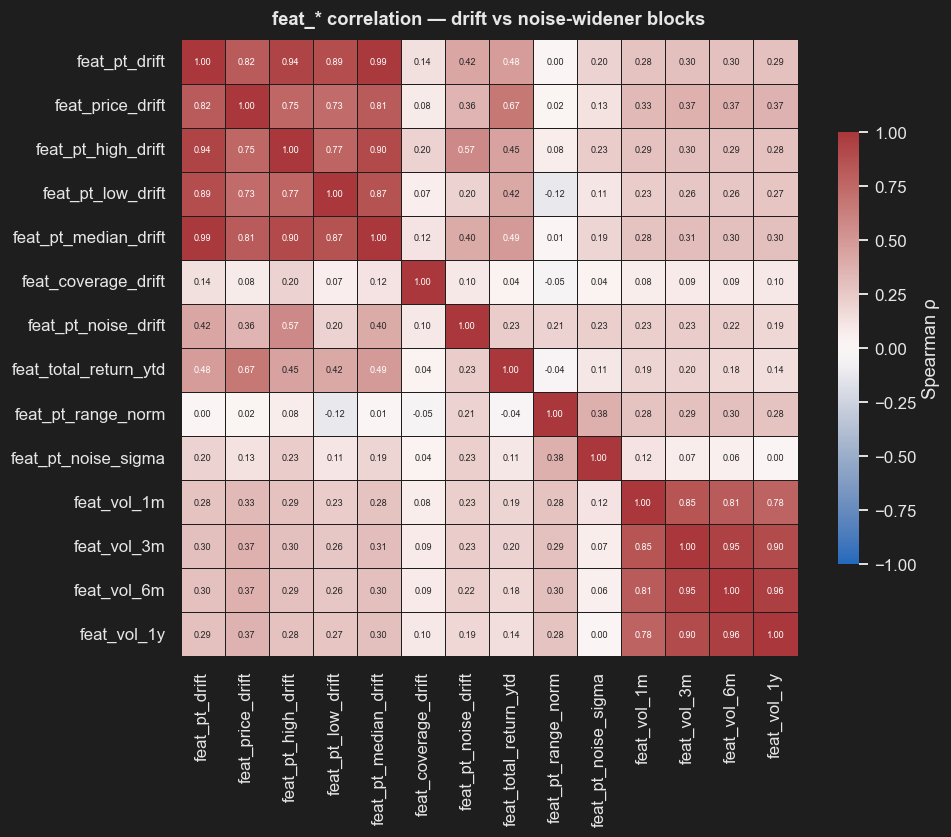

In [14]:
# 2.4d Feature collinearity heatmap. Strongly-correlated drift features would make the
# beta slopes (section 5) weakly identified, so this is a pre-model diagnostic: the
# *_drift trails for high/low/median naturally co-move, while the volatility horizons
# form their own block. Spearman (rank) correlation is robust to the heavy feat_* tails.
_corr_cols = [c for c in EDA_FEATURES if kalman_df[c].notna().sum() > 5]
_corr = kalman_df[_corr_cols].astype('float64').corr(method='spearman')

# NOTE: arviz-vibrant turns on figure.constrained_layout.use, so the figure already
# owns a ConstrainedLayoutEngine. Once seaborn draws the colorbar, plt.tight_layout()
# can no longer swap engines (incompatible colorbar_gridspec) and raises RuntimeError.
# Build with layout='constrained' and let that engine handle the spacing.
fig, ax = plt.subplots(figsize=(9, 7.5), layout='constrained')
sns.heatmap(_corr, ax=ax, cmap='vlag', center=0.0, vmin=-1, vmax=1,
            square=True, linewidths=0.4, linecolor='#1e1e1e',
            cbar_kws={'shrink': 0.7, 'label': 'Spearman ρ'},
            annot=True, fmt='.2f', annot_kws={'size': 6})
ax.set_title('feat_* correlation — drift vs noise-widener blocks', pad=10)
plt.show()

C:\Users\markm\AppData\Local\Temp\ipykernel_1516\74326393.py:40: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


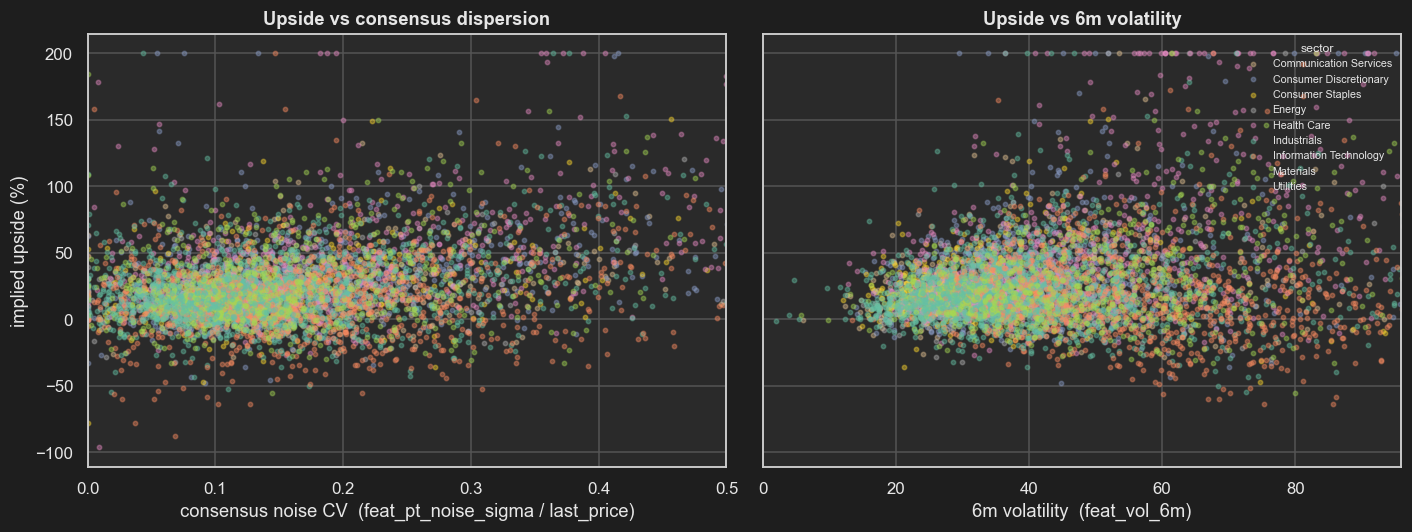

In [15]:
# 2.4e How implied upside relates to the drift / noise signals, grouped by sector.
# This previews the hierarchical group effect (section 5: sector is a GROUP_EFFECTS
# level): if the implied-upside ↔ feature relationship shifts by sector, partial
# pooling across sectors is justified. We plot the SSOT implied upside against the
# consensus-noise CV and the volatility level, coloured by sector.
_g = kalman_df[(kalman_df['observed_pt'] > 0) & (kalman_df['last_price'] > 0)].copy()
_g['upside_pct'] = (_g['observed_pt'] / _g['last_price'] - 1.0) * 100.0
_g['upside_pct'] = _g['upside_pct'].clip(-100, 200)
_g['sector'] = _g.get('sector', pd.Series('Unknown', index=_g.index)).fillna('Unknown')

# Consensus noise relative to last_price (the same quantity section 4 feeds to sigma_obs).
if 'feat_pt_noise_sigma' in _g.columns:
    _g['noise_cv'] = (_g['feat_pt_noise_sigma'].astype('float64')
                      / _g['last_price'].clip(lower=1e-9)).clip(0, 1)
_g['vol_6m'] = _g.get('feat_vol_6m', pd.Series(np.nan, index=_g.index)).astype('float64')

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
_top_sectors = _g['sector'].value_counts().head(9).index.tolist()
_gs = _g[_g['sector'].isin(_top_sectors)]
_pal = dict(zip(_top_sectors, sns.color_palette('Set2', len(_top_sectors))))

if 'noise_cv' in _gs.columns:
    for sec, sub in _gs.groupby('sector'):
        axes[0].scatter(sub['noise_cv'], sub['upside_pct'], s=8, alpha=0.4,
                        color=_pal[sec], label=sec)
    axes[0].set_xlabel('consensus noise CV  (feat_pt_noise_sigma / last_price)')
    axes[0].set_ylabel('implied upside (%)')
    axes[0].set_title('Upside vs consensus dispersion')
    axes[0].set_xlim(0, 0.5)

for sec, sub in _gs.groupby('sector'):
    axes[1].scatter(sub['vol_6m'], sub['upside_pct'], s=8, alpha=0.4,
                    color=_pal[sec], label=sec)
axes[1].set_xlabel('6m volatility  (feat_vol_6m)')
axes[1].set_title('Upside vs 6m volatility')
axes[1].set_xlim(0, float(np.nanquantile(_gs['vol_6m'], 0.97)) if _gs['vol_6m'].notna().any() else 1)
axes[1].legend(fontsize=7, framealpha=0.25, title='sector', title_fontsize=8,
               loc='upper right')

plt.tight_layout()
plt.show()

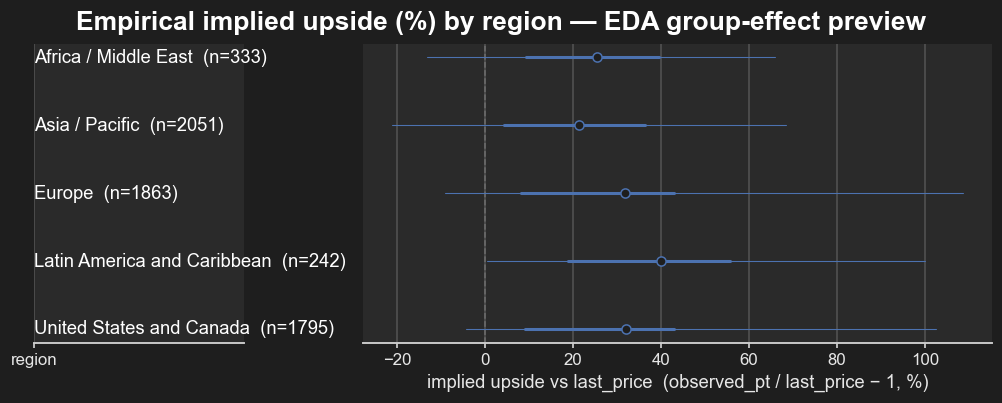

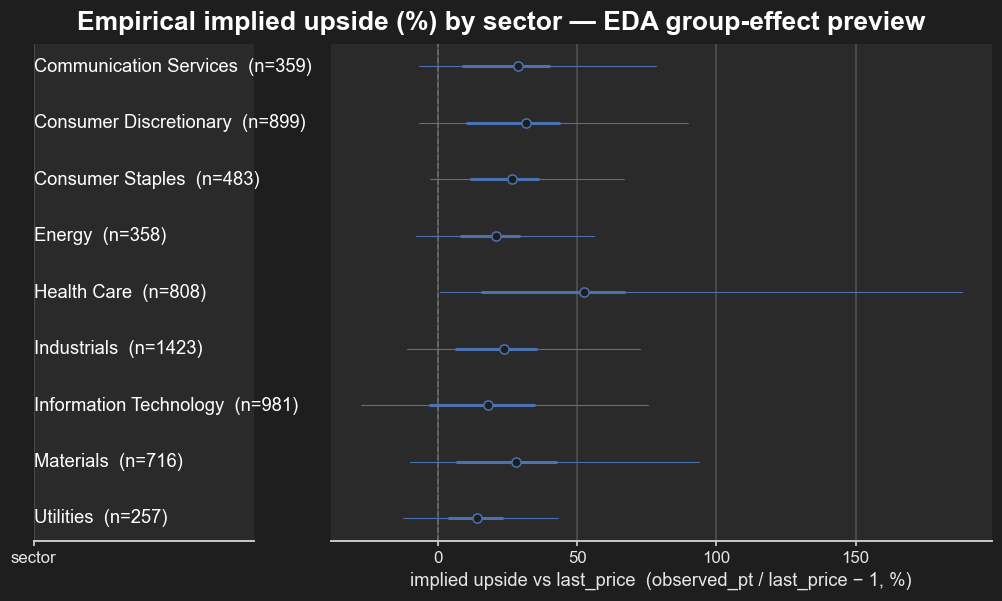

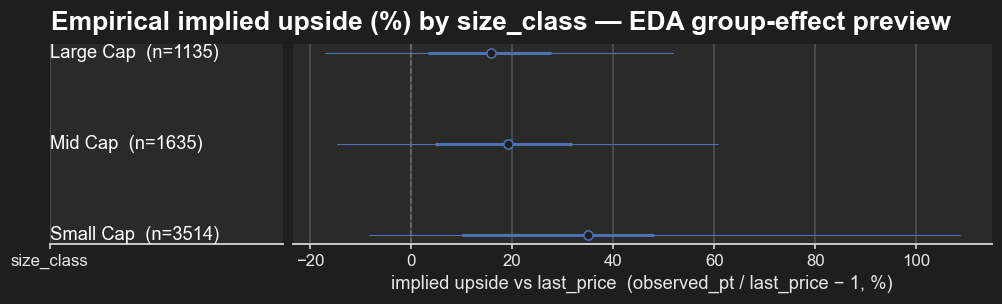

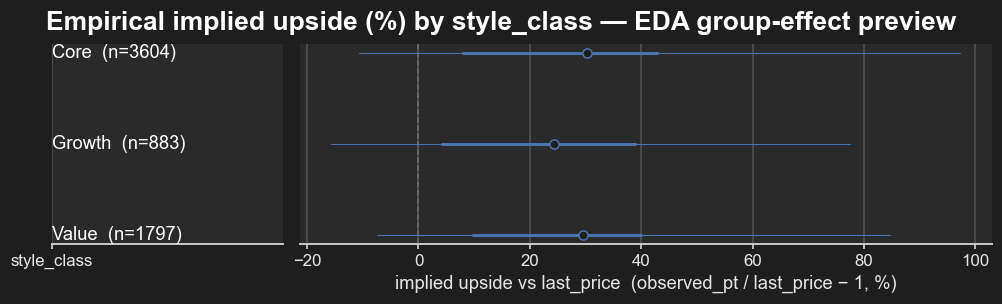

In [16]:
# 2.4f Empirical per-group implied-upside summary as an arviz_plots forest.
# Each GROUP_EFFECTS candidate coord (region/sector/size_class/style_class) is shown as
# the distribution of implied upside across its names — an EDA preview of the hierarchical
# group effects the cross-sectional model estimates in §5 (the per-coord `sigma_<coord>`
# group scales). The target `feat_implied_upside` is reconstructed here from `observed_pt`
# / `last_price` purely for EDA; it is the model's RESPONSE and is never fed back as a
# predictor (SSOT leakage guardrail).
#
# ROOT CAUSE of the earlier "only one group renders" forest: plot_forest reduces each row
# to a point-estimate + HDI over the sample dim WITHOUT skipping NaNs. Packing uneven
# per-group counts into one rectangular (group, sample) block requires NaN padding, so
# every group except the largest reduced to all-NaN, its row collapsed onto y=0 and the
# figure stretched to absorb the empty rows. Fix: bootstrap-resample each group's upside
# values to a COMMON draw count and pack them into the canonical (chain, draw, <coord>)
# posterior layout — no NaN padding, so each group keeps its own NaN-free forest row.
# Resampling with replacement reproduces the empirical distribution, so the row's median +
# 94% interval still reflect the raw per-name spread. arviz_plots owns the figure, so the
# title / reference line / x-label are routed through the returned PlotCollection rather
# than the pyplot current-axes shims (`plt.title` / `plt.tight_layout`), which on the arviz
# constrained-layout figure only mislabel the wrong column and swap the layout engine out.
_fe = kalman_df[(kalman_df['observed_pt'] > 0) & (kalman_df['last_price'] > 0)].copy()
_fe['upside_pct'] = ((_fe['observed_pt'] / _fe['last_price'] - 1.0) * 100.0).clip(-100, 200)

_GROUP_PREVIEW = [c for c in ('region', 'sector', 'size_class', 'style_class')
                  if c in _fe.columns]
_MIN_PER_LEVEL = 5      # drop sparse levels the hierarchical prior would shrink heavily anyway
_BOOT_DRAWS = 4000      # common per-group draw count for the bootstrap-resampled forest

for _coord in _GROUP_PREVIEW:
    lab = _fe[_coord].fillna('Unknown').astype(str)
    _counts = lab.value_counts()
    levels = sorted(lv for lv in _counts.index if _counts[lv] >= _MIN_PER_LEVEL)
    if len(levels) < 2:
        continue

    # Bootstrap each level's per-name upside to _BOOT_DRAWS and stack as a single
    # posterior chain -> (chain=1, draw=_BOOT_DRAWS, <coord>) with no NaN padding.
    _boot = np.empty((1, _BOOT_DRAWS, len(levels)), dtype='float64')
    for i, lv in enumerate(levels):
        vals = _fe.loc[lab == lv, 'upside_pct'].to_numpy()
        _boot[0, :, i] = vals[rng.integers(0, vals.size, _BOOT_DRAWS)]
    # Stamp each level with its TRUE sample size so the forest doubles as a coverage view.
    _level_labels = [f'{lv}  (n={_counts[lv]})' for lv in levels]
    _ds = xr.Dataset(
        {'implied_upside_pct': (('chain', 'draw', _coord), _boot)},
        coords={_coord: _level_labels},
    )

    # Height scales with the number of rows so the y labels never collide. Let plot_forest
    # own the layout: pass only figsize (no 'constrained' — combined with add_title on a
    # short figure it collapses the axes to zero) and suppress the redundant single-variable
    # __variable__ label via labels=[_coord] so it can't overlap the per-level y ticks.
    _figsize = (9.0, max(2.2, 0.45 * len(levels) + 1.3))
    pc = azp.plot_forest(
        _ds, var_names=['implied_upside_pct'], combined=True,
        labels=[_coord], backend='matplotlib',
        figure_kwargs={'figsize': _figsize},
    )
    pc.add_title(f'Empirical implied upside (%) by {_coord} — EDA group-effect preview')

    # Decorate the data ('forest') column only; the 'labels' column carries the y ticks.
    _ax = pc.viz['plot'].sel(column='forest').item()
    _ax.axvline(0, color='#bbbbbb', ls='--', lw=1.0, zorder=0)  # 0% = target == last_price
    _ax.set_xlabel('implied upside vs last_price  (observed_pt / last_price − 1, %)')
    pc.show()


### 2.5 EDA takeaways for the `KalmanFilterModel` spec & parametrization

What §2.4's diagnostics imply for `KalmanFilterPriceTarget.fit(...)` and the cross-sectional
state-space spec (§5), keeping the SSOT leakage guardrail (`feat_implied_upside` is the
*target*, never a predictor):

**Drift-feature collinearity (→ `beta` slopes / `drift_feature` dim).**
The Spearman heatmap (2.4d) shows the analyst-trail drifts move as one block: `feat_pt_drift`,
`feat_pt_high_drift`, `feat_pt_low_drift` and `feat_pt_median_drift` are all `pml.target_drift()`
of the *same* consensus envelope, so they are near-collinear by construction and the individual
`beta` slopes are only weakly identified.

- **Implication:** keep the weakly-informative `beta ~ Normal(0, 0.25)` prior (it already
  regularises the redundant slopes toward zero), but consider either (a) **dropping** the
  high/low/median drifts in favour of `feat_pt_drift` + `feat_pt_median_drift` only, or
  (b) compressing the four into a **single consensus-drift factor** (e.g. their mean) before it
  enters the `Xd` matrix. `feat_price_drift`, `feat_coverage_drift` and `feat_total_return_ytd`
  carry **independent** signal (price vs target vs coverage) and should stay as separate slopes.

**Noise wideners (→ `sigma_obs` scale).**
The volatility term-structure (2.4c) is monotone in horizon and the wideners (`feat_pt_range_norm`,
`feat_pt_noise_sigma/last_price`, `feat_vol_*`) are positive and right-skewed, which validates the
`sigma_obs = sigma_obs_base · (1 + range + cv + ½·vol) / √n_analysts` form: they enter
**additively and non-negatively**, and 2.4e confirms upside genuinely widens with both consensus
dispersion and volatility, so they belong on the **measurement-noise** side, not the drift side.

- **Implication:** the four volatility horizons are themselves collinear, so the existing
  **mean-collapse** to a single `feat_vol_mean` (rather than four separate `sigma_obs` terms) is the
  right call — adding them individually would double-count the same risk.

**Hierarchical pooling (→ `GROUP_EFFECTS` / `hierarchy_levels`).**
The per-coord forests (2.4f) show implied-upside HDIs that **clearly separate across `sector`** and,
more weakly, across `region` / `size_class`, while `style_class` levels largely overlap. Combined with
the cardinalities from 2.3 (`sector`=9, `industry`=59, vs `country`/`exchange` in the dozens),
**partial pooling on `sector` is warranted** (enough levels to estimate a scale, clear between-group
separation), and `industry` benefits from nesting *under* sector via the project `PARENT_MAP`.

- **Implication:** keep `sector` (and `industry`) in `GROUP_EFFECTS`; for the single-security filter
  pass `hierarchy_levels=["sector", "industry"]` to `KalmanFilterPriceTarget.fit(...)`. High-cardinality,
  low-separation coords (`country`, `exchange`, `unit`) add many `z_<coord>` parameters for little
  signal and can be dropped to lift the low group-scale ESS seen later in §9.

**Parametrization.**
Nothing in the cross-sectional marginals motivates a centred latent state — the right-skewed
`sigma_*` wideners and the modest group separation are exactly the funnel-prone regime the model
guards against, so the **non-centred** innovation (`z_state`, `z_<coord>`) here and the
`parameterization="auto"` → **`marginalized`** GRW for the short, irregular `*_ago` cohorts
(§11–§13) remain the correct defaults.


## 3. State-Space Feature Mapping (Kalman semantics)

`KalmanFilterPriceTarget` (in `probabilistic_ml_model/pymc_models/KalmanFilterModel.py`)
is a **single-security time-series** `GaussianRandomWalk` filter: a latent log-price
state with process (`sigma_state`) and observation (`sigma_obs`) noise. `pml.mv_pymc_kalman_pt`
is a **cross-sectional** snapshot - the time axis has been collapsed into per-ISIN
`feat_*` drift / noise columns - so here we reuse the same generative ideas as a
one-step Kalman *measurement update* across the whole panel.

The extended MV computes `target_drift()` for **every** `price_* / price_target_*`
trail, so the drift signal is no longer limited to the consensus mean:

| Role                                                     | MV columns                                                                                                                                             | Where it enters the model                                                                 |
|----------------------------------------------------------|--------------------------------------------------------------------------------------------------------------------------------------------------------|-------------------------------------------------------------------------------------------|
| **Drift / state-transition mean**                        | `feat_pt_drift`, `feat_price_drift`, `feat_pt_high_drift`, `feat_pt_low_drift`, `feat_pt_median_drift`, `feat_coverage_drift`, `feat_total_return_ytd` | regression slopes `beta` on the latent log-uplift                                         |
| **Observation-noise wideners** (non-negative)            | `feat_pt_range_norm`, `feat_pt_noise_sigma`, `feat_pt_noise_drift`, `feat_vol_{1m,3m,6m,1y}`                                                           | scale the measurement noise `sigma_obs`                                                   |
| **Fiscal-calendar time axis** (DATE coords / day-counts) | `income_statement_report_date`, `next_earnings`, `fy_end_date`, ..., `days_to_*`                                                                       | reconstruct the irregular elapsed-time spacing for the **marginalized** GRW in section 11 |

The fiscal-calendar columns are `pymc_role='coord'` but are **not** categorical
group effects - section 11 uses them to scale the random-walk process variance by
real elapsed time.

In [17]:
# Map mv_pymc_kalman_pt feat_* columns onto Kalman state-space roles.
# Drift / state-transition mean now spans every price_* / price_target_* trail.
DRIFT_FEATURES = [c for c in ('feat_pt_drift', 'feat_price_drift',
                              'feat_pt_high_drift', 'feat_pt_low_drift',
                              'feat_pt_median_drift', 'feat_coverage_drift',
                              'feat_total_return_ytd')
                  if c in kalman_df.columns]

# LEAKAGE GUARDRAIL: feat_implied_upside = (observed_pt - last_price)/last_price is a
# deterministic function of the RESPONSE (observed_pt) and the anchor (last_price);
# log1p(feat_implied_upside) IS the log-uplift the model targets. It must therefore
# NEVER enter the drift-PREDICTOR matrix - that is circular target leakage which
# inflates apparent fit and destroys calibration. It is used only as the model
# OBSERVATION (section 4/5) and for comparative analytics (section 10).
assert 'feat_implied_upside' not in DRIFT_FEATURES, (
    'feat_implied_upside must not be a drift predictor (target leakage).'
)
NOISE_RANGE_COL = 'feat_pt_range_norm' if 'feat_pt_range_norm' in kalman_df.columns else None
NOISE_SIGMA_COL = 'feat_pt_noise_sigma' if 'feat_pt_noise_sigma' in kalman_df.columns else None
VOL_COLS = [c for c in ('feat_vol_1m', 'feat_vol_3m', 'feat_vol_6m', 'feat_vol_1y')
            if c in kalman_df.columns]

mapping_rows: list[tuple[str, str]] = [
    (c, 'drift / state-transition mean (beta)') for c in DRIFT_FEATURES
]
if NOISE_RANGE_COL:
    mapping_rows.append((NOISE_RANGE_COL, 'observation-noise widener (range)'))
if NOISE_SIGMA_COL:
    mapping_rows.append((NOISE_SIGMA_COL, 'observation-noise widener (consensus sigma)'))
mapping_rows += [(c, 'observation-noise widener (volatility)') for c in VOL_COLS]
mapping = pd.DataFrame(mapping_rows, columns=['mv_column', 'state_space_role'])

print(f'Drift features : {DRIFT_FEATURES}')
print(f'Noise drivers  : range={NOISE_RANGE_COL}, sigma={NOISE_SIGMA_COL}, vol={VOL_COLS}')
mapping

Drift features : ['feat_pt_drift', 'feat_price_drift', 'feat_pt_high_drift', 'feat_pt_low_drift', 'feat_pt_median_drift', 'feat_coverage_drift', 'feat_total_return_ytd']
Noise drivers  : range=feat_pt_range_norm, sigma=feat_pt_noise_sigma, vol=['feat_vol_1m', 'feat_vol_3m', 'feat_vol_6m', 'feat_vol_1y']


,mv_column,state_space_role
0,feat_pt_drift,drift / state-transition mean (beta)
1,feat_price_drift,drift / state-transition mean (beta)
2,feat_pt_high_drift,drift / state-transition mean (beta)
3,feat_pt_low_drift,drift / state-transition mean (beta)
4,feat_pt_median_drift,drift / state-transition mean (beta)
5,feat_coverage_drift,drift / state-transition mean (beta)
6,feat_total_return_ytd,drift / state-transition mean (beta)
7,feat_pt_range_norm,observation-noise widener (range)
8,feat_pt_noise_sigma,observation-noise widener (consensus sigma)
9,feat_vol_1m,observation-noise widener (volatility)


## 4. Build PyMC-Aligned Data Containers

In [18]:
# 4.0 Filter to rows usable for a log-space state-space model: strictly positive
# observed_pt and last_price, and >=1 contributing analyst. Build categorical coords.
model_df = kalman_df.loc[
    (kalman_df['observed_pt'] > 0)
    & (kalman_df['last_price'] > 0)
    & kalman_df['observed_pt'].notna()
    & kalman_df['last_price'].notna()
].copy().reset_index(drop=True)

if 'n_analysts' in model_df.columns:
    model_df['n_analysts'] = model_df['n_analysts'].fillna(1).clip(lower=1)
else:
    model_df['n_analysts'] = 1.0
print(f'Modelling rows (observed_pt>0 & last_price>0): {len(model_df)}')

isin_labels = model_df['isin'].astype(str).values

# Categorical group effects use ONLY the hierarchical classification coords -
# the fiscal-calendar date coords (FISCAL_CALENDAR_COLS) define the section 11
# time axis and must never be expanded into thousands of categorical levels here.
CATEGORICAL_COORDS = [c for c in CLASSIFICATION_COORDS
                      if c in model_df.columns and c not in ('isin', 'ticker')]
coord_uniques, coord_idx = {}, {}
for col in CATEGORICAL_COORDS:
    labels = model_df[col].fillna('Unknown').astype(str).values
    uniques, idx = np.unique(labels, return_inverse=True)
    coord_uniques[col] = uniques
    coord_idx[col] = idx.astype('int64')
print(f'Categorical coords ({len(CATEGORICAL_COORDS)}): {CATEGORICAL_COORDS}')

# Log-space transition anchor + observation. KalmanFilterModel operates in log
# space to keep strictly-positive prices / targets numerically stable.
log_last = np.log(model_df['last_price'].astype('float64').to_numpy())
log_obs = np.log(model_df['observed_pt'].astype('float64').to_numpy())

# SSOT log-uplift TARGET. feat_implied_upside = (observed_pt - last_price)/last_price
# is the SQL-canonical (NULLIF-safe) implied return to the analyst target, so
# log1p(feat_implied_upside) == log_obs - log_last but is computed once, robustly, in
# SQL. The cross-sectional model (section 5) observes THIS uplift directly - which is
# statistically equivalent to observing log_obs (since log_state = log_last + uplift)
# but removes the fixed log_last offset from both sides of the likelihood and avoids
# rebuilding the ratio in Python. Per-row fallback to the price reconstruction keeps
# the notebook runnable before mv_pymc_kalman_pt is refreshed with the new column.
if 'feat_implied_upside' in model_df.columns:
    _iu = model_df['feat_implied_upside'].astype('float64').to_numpy()
    log_uplift_obs = np.where(
        np.isfinite(_iu), np.log1p(np.clip(_iu, -0.999, None)), log_obs - log_last
    )
    _src = 'feat_implied_upside (SSOT)'
else:
    log_uplift_obs = log_obs - log_last
    _src = 'log_obs - log_last (fallback; feat_implied_upside absent)'
print(f'log_last: {log_last.shape}, log_obs: {log_obs.shape}, '
      f'log_uplift_obs: {log_uplift_obs.shape} [{_src}]')

Modelling rows (observed_pt>0 & last_price>0): 6284
Categorical coords (9): ['region', 'country', 'trading_country', 'exchange', 'unit', 'style_class', 'size_class', 'sector', 'industry']
log_last: (6284,), log_obs: (6284,), log_uplift_obs: (6284,) [feat_implied_upside (SSOT)]


In [19]:
# 4.1 Standardised drift-feature matrix (state-transition mean inputs).
X_drift_raw = model_df[DRIFT_FEATURES].astype(float)
X_drift_std = (X_drift_raw - X_drift_raw.mean()) / X_drift_raw.std(ddof=0).replace(0, 1.0)
X_drift = X_drift_std.fillna(0.0).to_numpy()
print(f'Drift matrix X_drift: {X_drift.shape}  ({DRIFT_FEATURES})')

# 4.2 Non-negative observation-noise drivers (measurement-variance wideners).
# Built via the SAME shared build_noise_wideners() helper the §2.4c EDA panel uses
# (fillna=True -> the model contract: 0-fill missing inputs, clip the non-negative
# wideners at 0). The consensus stddev enters as feat_pt_noise_sigma / last_price
# (NOT / observed_pt, which would leak the target into its own noise term) and the
# four volatility horizons are mean-collapsed (see §2.5) — both handled inside the
# helper, so the EDA marginals and the model's sigma_obs are now identical by
# construction.
n_obs = len(model_df)
_nw = build_noise_wideners(model_df, fillna=True)
range_norm_xs = _nw['range']
noise_cv_xs = _nw['cv']
vol_xs = _nw['vol']
sqrt_n_xs = _nw['sqrt_n']
n_analysts_xs = sqrt_n_xs ** 2  # model_df['n_analysts'] clipped at 1, per the helper

print(f'noise drivers (mean) — range:{range_norm_xs.mean():.3f}  '
      f'cv:{noise_cv_xs.mean():.3f}  vol:{vol_xs.mean():.3f}')

Drift matrix X_drift: (6284, 7)  (['feat_pt_drift', 'feat_price_drift', 'feat_pt_high_drift', 'feat_pt_low_drift', 'feat_pt_median_drift', 'feat_coverage_drift', 'feat_total_return_ytd'])
noise drivers (mean) — range:0.449  cv:0.193  vol:45.778


## 5. Cross-Sectional State-Space Model (log-space Kalman update)

Generative form, per ISIN $i$:

$$\eta_i = \mu_0 + X^{\text{drift}}_i\,\beta + \sum_g u^{(g)}_{[i]} \qquad\text{(hierarchical drift mean)}$$
$$\text{uplift}_i = \eta_i + \sigma_{\text{state}}\,z_i \qquad\text{(latent state innovation)}$$
$$\log s_i = \log(\text{last\_price}_i) + \text{uplift}_i \qquad\text{(latent log fair price-target)}$$
$$\log(\text{observed\_pt}_i) \sim \text{StudentT}\!\left(\nu,\ \log s_i,\ \sigma^{\text{obs}}_i\right)$$
$$\sigma^{\text{obs}}_i = \sigma_{\text{base}}\,\frac{1 + \text{range}_i + \text{cv}_i + \tfrac12\text{vol}_i}{\sqrt{n^{\text{analysts}}_i}}$$

The posterior `expected_pt` $= e^{\log s_i}$ is the **Kalman-smoothed** price target — a
shrinkage between the drift-implied prior ($\text{last\_price}\cdot e^{\eta}$) and the
noisy consensus `observed_pt`, with more analysts / tighter dispersion pulling it
toward the raw consensus. `HalfNormal` state / observation noise and the non-centred
innovation mirror `KalmanFilterPriceTarget`.

sec.5 - cross-sectional state-space model on 6284 ISINs; 7 drift features; group effects: ['region', 'style_class', 'size_class', 'sector', 'industry']


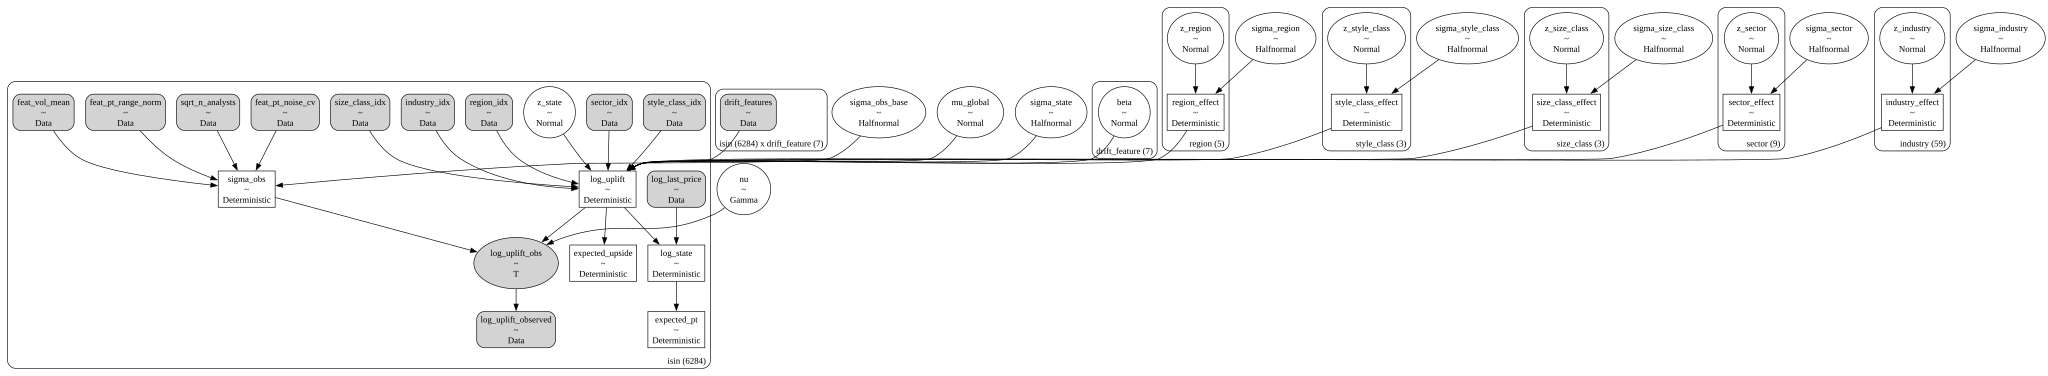

In [20]:
# 5.0 Cross-sectional log-space state-space model builder.

_CANDIDATE_GROUPS = ('region', 'style_class', 'size_class', 'sector', 'industry')
GROUP_EFFECTS = [c for c in _CANDIDATE_GROUPS if c in coord_idx]


def build_kalman_pt_model(*, robust: bool = True) -> pm.Model:
    """Cross-sectional log-space state-space price-target model.

    One observation per ISIN: ``log(observed_pt)`` is a noisy measurement of a
    latent log fair-value state anchored at ``log(last_price)`` and shifted by a
    hierarchical, drift-feature-driven log-uplift.

    Parameters
    ----------
    robust : bool
        ``True`` -> Student-t measurement likelihood (default; absorbs analyst
        outliers). ``False`` -> Normal-likelihood twin.
    """
    coords = {'isin': isin_labels, 'drift_feature': DRIFT_FEATURES}
    for col in GROUP_EFFECTS:
        coords[col] = coord_uniques[col]

    with pm.Model(coords=coords) as model:
        log_last_d = pm.Data('log_last_price', log_last, dims='isin')
        Xd = pm.Data('drift_features', X_drift, dims=('isin', 'drift_feature'))
        rng_d = pm.Data('feat_pt_range_norm', range_norm_xs, dims='isin')
        cv_d = pm.Data('feat_pt_noise_cv', noise_cv_xs, dims='isin')
        vol_d = pm.Data('feat_vol_mean', vol_xs, dims='isin')
        sqn = pm.Data('sqrt_n_analysts', sqrt_n_xs, dims='isin')
        log_uplift_obs_d = pm.Data('log_uplift_observed', log_uplift_obs, dims='isin')
        idx_data = {col: pm.Data(f'{col}_idx', coord_idx[col], dims='isin')
                    for col in GROUP_EFFECTS}

        # --- State-transition mean: hierarchical drift regression on log-uplift.
        # Data-informed anchor: centre the global log-uplift on the cross-sectional
        # MEDIAN observed uplift (an aggregate over ISINs, NOT the per-ISIN value ->
        # no leakage). This is the same empirical quantity the prior-predictive check
        # (section 6) compares against; anchoring here tightens the funnel-prone
        # sigma_state/sigma_obs variance ridge and speeds convergence vs a 0 prior.
        mu_anchor = float(np.median(log_uplift_obs))
        mu_global = pm.Normal('mu_global', mu_anchor, 0.25)
        beta = pm.Normal('beta', 0.0, 0.25, dims='drift_feature')
        eta = mu_global + pt.dot(Xd, beta)
        for col in GROUP_EFFECTS:
            sigma_g = pm.HalfNormal(f'sigma_{col}', 0.10)
            z_g = pm.Normal(f'z_{col}', 0.0, 1.0, dims=col)
            ge = pm.Deterministic(f'{col}_effect', sigma_g * z_g, dims=col)
            eta = eta + ge[idx_data[col]]

        # --- Latent log state (non-centred GRW-style innovation; HalfNormal sigma).
        sigma_state = pm.HalfNormal('sigma_state', 0.15)
        z_state = pm.Normal('z_state', 0.0, 1.0, dims='isin')
        log_uplift = pm.Deterministic('log_uplift', eta + sigma_state * z_state, dims='isin')
        log_state = pm.Deterministic('log_state', log_last_d + log_uplift, dims='isin')

        # --- Observation noise (Kalman measurement variance), HalfNormal base.
        sigma_obs_base = pm.HalfNormal('sigma_obs_base', 0.10)
        sigma_obs = pm.Deterministic(
            'sigma_obs',
            sigma_obs_base * (1.0 + rng_d + cv_d + 0.5 * vol_d) / sqn,
            dims='isin')

        # --- Measurement likelihood in log space. We observe the log-UPLIFT directly
        #     (SSOT: log1p(feat_implied_upside)), so the likelihood mean is `log_uplift`,
        #     NOT `log_state`. This is equivalent to observing log(observed_pt) with mean
        #     log_state (= log_last + log_uplift) but drops the fixed log_last offset from
        #     both sides -> better-conditioned and no Python ratio reconstruction.
        if robust:
            nu = pm.Gamma('nu', alpha=2.0, beta=0.1)
            pm.StudentT('log_uplift_obs', nu=nu, mu=log_uplift, sigma=sigma_obs,
                        observed=log_uplift_obs_d, dims='isin')
        else:
            pm.Normal('log_uplift_obs', mu=log_uplift, sigma=sigma_obs,
                      observed=log_uplift_obs_d, dims='isin')

        # --- Screening outputs on the price scale.
        pm.Deterministic('expected_pt', pt.exp(log_state), dims='isin')
        pm.Deterministic('expected_upside', pt.exp(log_uplift) - 1.0, dims='isin')
    return model


kalman_pt_model = build_kalman_pt_model(robust=True)
print(f'sec.5 - cross-sectional state-space model on {len(isin_labels)} ISINs; '
      f'{len(DRIFT_FEATURES)} drift features; group effects: {GROUP_EFFECTS}')
pm.model_to_graphviz(kalman_pt_model)

## 6. Prior Predictive Checks

Sampling: [beta, log_uplift_obs, mu_global, nu, sigma_industry, sigma_obs_base, sigma_region, sigma_sector, sigma_size_class, sigma_state, sigma_style_class, z_industry, z_region, z_sector, z_size_class, z_state, z_style_class]
C:\Users\markm\AppData\Local\Temp\ipykernel_1516\4202022709.py:24: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


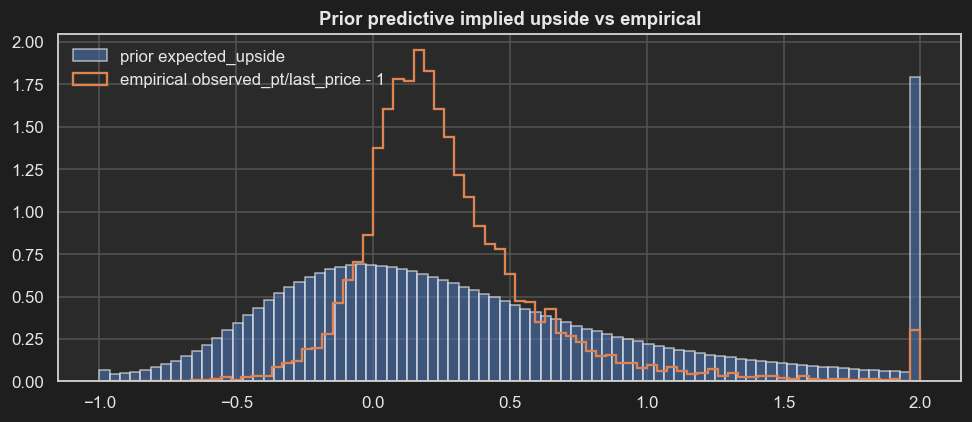

<xarray.DataTree>
Group: /
├── Group: /prior
│       Dimensions:             (chain: 1, draw: 1500, isin: 6284, region: 5,
│                                size_class: 3, drift_feature: 7, style_class: 3,
│                                sector: 9, industry: 59)
│       Coordinates:
│         * chain               (chain) int64 8B 0
│         * draw                (draw) int64 12kB 0 1 2 3 4 ... 1495 1496 1497 1498 1499
│         * isin                (isin) <U12 302kB 'US67066G1040' ... 'EGS38211C016'
│         * region              (region) <U27 540B 'Africa / Middle East' ... 'United...
│         * size_class          (size_class) <U9 108B 'Large Cap' 'Mid Cap' 'Small Cap'
│         * drift_feature       (drift_feature) <U21 588B 'feat_pt_drift' ... 'feat_t...
│         * style_class         (style_class) <U6 72B 'Core' 'Growth' 'Value'
│         * sector              (sector) <U22 792B 'Communication Services' ... 'Util...
│         * industry            (industry) <U53 13kB 'Aerospace and Defense' ... 'Wir...
│       Data variables: (12/20)
│           nu                  (chain, draw) float64 12kB 2.141 15.23 ... 22.98 9.984
│           expected_upside     (chain, draw, isin) float64 75MB 0.2332 ... 0.5033
│           sigma_style_class   (chain, draw) float64 12kB 0.1254 0.06063 ... 0.2454
│           log_uplift          (chain, draw, isin) float64 75MB 0.2096 ... 0.4076
│           region_effect       (chain, draw, region) float64 60kB -0.01502 ... -0.00...
│           sigma_obs           (chain, draw, isin) float64 75MB 0.008985 ... 2.076
│           ...                  ...
│           sigma_size_class    (chain, draw) float64 12kB 0.01004 0.146 ... 0.1538
│           style_class_effect  (chain, draw, style_class) float64 36kB 0.05248 ... 0...
│           sector_effect       (chain, draw, sector) float64 108kB -0.002463 ... -0....
│           sigma_obs_base      (chain, draw) float64 12kB 0.003107 0.1531 ... 0.1423
│           industry_effect     (chain, draw, industry) float64 708kB 0.2058 ... 0.1324
│           sigma_region        (chain, draw) float64 12kB 0.01084 0.04138 ... 0.008075
│       Attributes:
│           created_at:                 2026-06-08T08:44:59.230791+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.1.0
│           creation_library_language:  Python
│           inference_library:          pymc
│           inference_library_version:  6.0.1
│           sample_dims:                ['chain', 'draw']
├── Group: /prior_predictive
│       Dimensions:         (chain: 1, draw: 1500, isin: 6284)
│       Coordinates:
│         * chain           (chain) int64 8B 0
│         * draw            (draw) int64 12kB 0 1 2 3 4 5 ... 1495 1496 1497 1498 1499
│         * isin            (isin) <U12 302kB 'US67066G1040' ... 'EGS38211C016'
│       Data variables:
│           log_uplift_obs  (chain, draw, isin) float64 75MB 0.2077 0.5032 ... -3.81
│       Attributes:
│           created_at:                 2026-06-08T08:44:59.235748+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.1.0
│           creation_library_language:  Python
│           inference_library:          pymc
│           inference_library_version:  6.0.1
│           sample_dims:                ['chain', 'draw']
├── Group: /observed_data
│       Dimensions:         (isin: 6284)
│       Coordinates:
│         * isin            (isin) <U12 302kB 'US67066G1040' ... 'EGS38211C016'
│       Data variables:
│           log_uplift_obs  (isin) float64 50kB 0.375 0.1505 0.2119 ... 0.4425 0.01077
│       Attributes:
│           created_at:                 2026-06-08T08:44:59.237509+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.1.0
│           creation_library_language:  Python
│           inference_library:          pymc
│           inference_library_version:  6.0.1
│           sample_dims:                []
└── Group: /constant_da

In [21]:
_prior_var_names = [
    'mu_global', 'beta', 'sigma_state', 'sigma_obs_base', 'nu',
    *[f'sigma_{g}' for g in GROUP_EFFECTS],
    *[f'{g}_effect' for g in GROUP_EFFECTS],
    'log_uplift', 'log_state', 'sigma_obs',
    'expected_pt', 'expected_upside', 'log_uplift_obs',
]
with kalman_pt_model:
    prior_idata = pm.sample_prior_predictive(
        draws=1500, var_names=_prior_var_names,
        random_seed=RANDOM_SEED, return_inferencedata=True,
    )

# Prior implied upside vs the empirical distribution (sanity scale check).
prior_up = prior_idata.prior['expected_upside'].values.reshape(-1)
emp_up = (model_df['observed_pt'] / model_df['last_price'] - 1.0).to_numpy()
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(np.clip(prior_up, -1, 2), bins=80, density=True, alpha=0.6,
        label='prior expected_upside')
ax.hist(np.clip(emp_up, -1, 2), bins=80, density=True, histtype='step',
        linewidth=1.5, label='empirical observed_pt/last_price - 1')
ax.set_title('Prior predictive implied upside vs empirical')
ax.legend()
plt.tight_layout()
plt.show()
prior_idata

## 7. Posterior Inference (NUTS)

In [22]:
# Sampler dispatch - nutpie -> numpyro -> pymc fallback. The cross-sectional
# log-space state-space graph is supported by all three NUTS backends; we try
# them in priority order and fall back on the first installed one that succeeds.
sample_kwargs = dict(
    draws=1000, tune=1000, chains=4, cores=2,
    target_accept=0.95, random_seed=RANDOM_SEED,
    progressbar=True, return_inferencedata=True,
    idata_kwargs={"log_likelihood": False},
)

import importlib.util as _ilu

_candidate_samplers = []
if _ilu.find_spec("nutpie") is not None:
    _candidate_samplers.append("nutpie")
if _ilu.find_spec("numpyro") is not None:
    _candidate_samplers.append("numpyro")
_candidate_samplers.append("pymc")  # always available - pure-Python NUTS
print(f"Available NUTS samplers (in priority order): {_candidate_samplers}")

sampling_errors = []
idata = None
for _sampler in _candidate_samplers:
    try:
        with kalman_pt_model:
            idata = pm.sample(nuts_sampler=_sampler, **sample_kwargs)
        print(f"Sampled successfully with nuts_sampler={_sampler!r}.")
        break
    except Exception as e:  # pragma: no cover - environment-dependent fallback
        sampling_errors.append((_sampler, repr(e)))
        print(f"nuts_sampler={_sampler!r} failed: {e!r}")

if idata is None:
    raise RuntimeError(
        "All NUTS samplers failed:\n"
        + "\n".join(f"  - {s}: {err}" for s, err in sampling_errors)
    )

# Merge prior groups into the posterior idata for one-object downstream access.
from probabilistic_ml_model._pymc_arviz_compat import extend_datatree

idata = extend_datatree(idata, prior_idata)
idata

Available NUTS samplers (in priority order): ['nutpie', 'numpyro', 'pymc']


NUTS[nutpie]: [mu_global, beta, sigma_region, z_region, sigma_style_class, z_style_class, sigma_size_class, z_size_class, sigma_sector, z_sector, sigma_industry, z_industry, sigma_state, z_state, sigma_obs_base, nu]


Output()

Sampled successfully with nuts_sampler='nutpie'.


<xarray.DataTree>
Group: /
├── Group: /posterior
│       Dimensions:             (chain: 4, draw: 1000, drift_feature: 7, region: 5,
│                                style_class: 3, size_class: 3, sector: 9,
│                                industry: 59, isin: 6284)
│       Coordinates:
│         * chain               (chain) int64 32B 0 1 2 3
│         * draw                (draw) int64 8kB 0 1 2 3 4 5 ... 994 995 996 997 998 999
│         * drift_feature       (drift_feature) object 56B 'feat_pt_drift' ... 'feat_...
│         * region              (region) object 40B 'Africa / Middle East' ... 'Unite...
│         * style_class         (style_class) object 24B 'Core' 'Growth' 'Value'
│         * size_class          (size_class) object 24B 'Large Cap' ... 'Small Cap'
│         * sector              (sector) object 72B 'Communication Services' ... 'Uti...
│         * industry            (industry) object 472B 'Aerospace and Defense' ... 'W...
│         * isin                (isin) object 50kB 'US67066G1040' ... 'EGS38211C016'
│       Data variables: (12/26)
│           mu_global           (chain, draw) float64 32kB 0.1464 0.1447 ... 0.1446
│           beta                (chain, draw, drift_feature) float64 224kB 0.01513 .....
│           z_region            (chain, draw, region) float64 160kB 0.4945 ... -0.06667
│           z_style_class       (chain, draw, style_class) float64 96kB 0.078 ... 0.3081
│           z_size_class        (chain, draw, size_class) float64 96kB -0.1776 ... 0....
│           z_sector            (chain, draw, sector) float64 288kB -0.8153 ... -0.9685
│           ...                  ...
│           industry_effect     (chain, draw, industry) float64 2MB 0.0006614 ... -0....
│           log_uplift          (chain, draw, isin) float64 201MB 0.3076 ... 0.2197
│           log_state           (chain, draw, isin) float64 201MB 5.631 1.863 ... 3.829
│           sigma_obs           (chain, draw, isin) float64 201MB 0.0365 ... 0.1704
│           expected_pt         (chain, draw, isin) float64 201MB 279.0 6.441 ... 46.03
│           expected_upside     (chain, draw, isin) float64 201MB 0.3601 ... 0.2457
│       Attributes:
│           created_at:                 2026-06-08T08:46:34.691633+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.1.0
│           creation_library_language:  Python
│           sample_dims:                ['chain', 'draw']
│           inference_library:          nutpie
│           inference_library_version:  0.16.10
│           sampling_time:              80.18222522735596
│           tuning_steps:               1000
├── Group: /sample_stats
│       Dimensions:                   (chain: 4, draw: 1000)
│       Coordinates:
│         * chain                     (chain) int64 32B 0 1 2 3
│         * draw                      (draw) int64 8kB 0 1 2 3 4 ... 995 996 997 998 999
│       Data variables: (12/20)
│           depth                     (chain, draw) uint64 32kB 6 6 6 6 6 ... 6 6 6 6 6
│           maxdepth_reached          (chain, draw) bool 4kB False False ... False False
│           step_size                 (chain, draw) float64 32kB 0.07258 ... 0.06539
│           transformation_update_id  (chain, draw) int64 32kB 0 0 0 0 0 0 ... 0 0 0 0 0
│           step_size_bar             (chain, draw) float64 32kB 0.06645 ... 0.06816
│           mean_tree_accept          (chain, draw) float64 32kB 0.6225 ... 0.9628
│           ...                        ...
│           fisher_distance           (chain, draw) float64 32kB 1.036e+03 ... 943.5
│           transformation_index      (chain, draw) int64 32kB 848 848 848 ... 847 847
│           diverging                 (chain, draw) bool 4kB False False ... False False
│           divergence_draw           (chain, draw) uint64 32kB 0 0 0 0 0 ... 0 0 0 0 0
│           divergence_message        (chain, draw) object 32kB None None ... None None
│           divergence_energy_error   (chain, draw) float64 32kB na

## 8. Posterior Predictive Checks

Sampling: [log_uplift_obs]


Output()

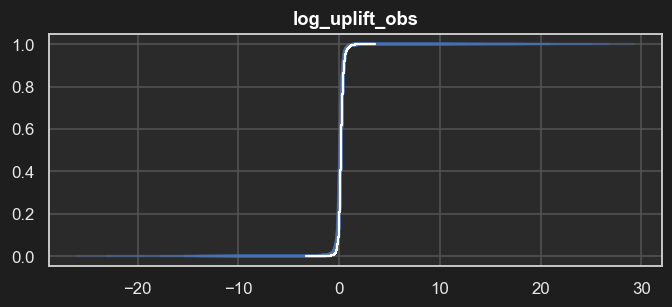

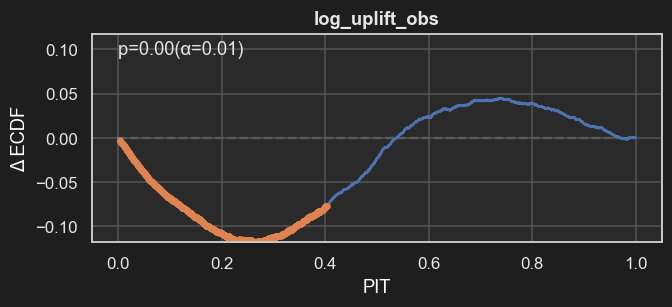

In [23]:
with kalman_pt_model:
    pm.sample_posterior_predictive(
        idata, extend_inferencedata=True,
        random_seed=RANDOM_SEED, progressbar=True,
    )

# (a) Distributional overlay — replicated log-uplift draws vs the observed ECDF.
#     A good fit hugs the observed step function.
pc_ppc = azp.plot_ppc_dist(
    idata,
    group="posterior_predictive",
    var_names=["log_uplift_obs"],
    kind="ecdf",
    num_samples=500,
    backend="matplotlib",
)
pc_ppc.show()

# (b) Calibration — posterior-predictive PIT ECDF. If the model is calibrated the
#     PIT values are ~Uniform(0,1), so the curve tracks the diagonal and stays
#     inside the simultaneous confidence envelope. Systematic excursions flag
#     over-/under-dispersion of the measurement-noise model.
try:
    pc_pit = azp.plot_ppc_pit(
        idata,
        var_names=["log_uplift_obs"],
        backend="matplotlib",
    )
    pc_pit.show()
except Exception as e:  # pragma: no cover - diagnostic is best-effort
    print(f"PPC PIT calibration plot skipped: {e!r}")

## 9. MCMC Diagnostics

In [24]:
# 9.1 R-hat / ESS summary across the cross-sectional parameter set.
posterior = idata.posterior
requested = ['mu_global', 'beta', 'sigma_state', 'sigma_obs_base', 'nu']
for _grp in GROUP_EFFECTS:
    requested.extend([f'sigma_{_grp}', f'{_grp}_effect'])

available, skipped = [], []
for v in requested:
    if v not in posterior.data_vars:
        skipped.append((v, 'not in posterior'))
        continue
    da = posterior[v]
    non_sample_sizes = [da.sizes[d] for d in da.dims if d not in ('chain', 'draw')]
    if any(s == 0 for s in non_sample_sizes):
        skipped.append((v, f'empty dim(s): {dict(da.sizes)}'))
        continue
    available.append(v)

if skipped:
    print('Skipping variables:')
    for name, reason in skipped:
        print(f'  - {name}: {reason}')
if not available:
    raise RuntimeError('No non-empty variables to summarise.')

summary = azs.summary(idata, var_names=available, round_to=4)
summary.sort_values('r_hat', ascending=False).head(50)

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
style_class_effect[Core],0.0032,0.0219,-0.0317,0.0359,91.2541,149.2730,1.0683,0.0023,0.0027
style_class_effect[Growth],-0.0207,0.0221,-0.0562,0.0119,79.7241,167.7487,1.0671,0.0024,0.0027
style_class_effect[Value],0.0120,0.0217,-0.0219,0.0441,94.3085,152.9060,1.0643,0.0021,0.0025
size_class_effect[Mid Cap],-0.0273,0.0329,-0.0806,0.0215,62.7832,68.4281,1.0635,0.0043,0.0040
size_class_effect[Small Cap],0.0329,0.0328,-0.0200,0.0819,63.1670,71.7481,1.0631,0.0042,0.0039
mu_global,0.1817,0.0412,0.1159,0.2480,68.5252,66.5750,1.0626,0.0050,0.0035
size_class_effect[Large Cap],-0.0402,0.0330,-0.0934,0.0086,64.6486,75.9537,1.0618,0.0041,0.0038
sigma_size_class,0.0604,0.0335,0.0240,0.1228,119.8620,143.2836,1.0490,0.0028,0.0034
sigma_style_class,0.0357,0.0263,0.0113,0.0837,159.9960,263.0374,1.0364,0.0020,0.0029
region_effect[United States and Canada],-0.0127,0.0200,-0.0412,0.0162,140.9302,279.2072,1.0259,0.0017,0.0022


In [25]:
# 9.2 Divergences and aggregated R-hat / ESS.
n_div = int(idata.sample_stats['diverging'].sum())


def _non_empty_vars(ds):
    keep = []
    for name, da in ds.data_vars.items():
        sizes = [da.sizes[d] for d in da.dims if d not in ('chain', 'draw')]
        if all(s > 0 for s in sizes):
            keep.append(name)
    return keep


posterior_tree = idata.posterior
posterior = posterior_tree.dataset if hasattr(posterior_tree, "dataset") else posterior_tree.to_dataset()
keep_vars = _non_empty_vars(posterior)
rhat_ds = azs.rhat(posterior[keep_vars])
ess_ds = azs.ess(posterior[keep_vars], method='bulk')

max_rhat = float(max(float(rhat_ds[v].max()) for v in rhat_ds.data_vars))
min_ess = float(min(float(ess_ds[v].min()) for v in ess_ds.data_vars))

_grp_keys = [f'sigma_{g}' for g in GROUP_EFFECTS if f'sigma_{g}' in rhat_ds.data_vars]
_grp_report = {v: (float(rhat_ds[v].max()), float(ess_ds[v].min())) for v in _grp_keys}

print(f'Divergences: {n_div}')
print(f'Max R-hat:   {max_rhat:.4f}')
print(f'Min ESS:     {min_ess:.1f}')
if _grp_report:
    print('Group-effect scale diagnostics (max R-hat, min ESS):')
    for v, (r, e) in _grp_report.items():
        print(f'  - {v:>20s}: r_hat={r:.3f}, ess_bulk={e:.1f}')

Divergences: 0
Max R-hat:   1.1381
Min ESS:     22.2
Group-effect scale diagnostics (max R-hat, min ESS):
  -         sigma_region: r_hat=1.007, ess_bulk=301.7
  -    sigma_style_class: r_hat=1.036, ess_bulk=160.0
  -     sigma_size_class: r_hat=1.049, ess_bulk=119.9
  -         sigma_sector: r_hat=1.002, ess_bulk=329.4
  -       sigma_industry: r_hat=1.011, ess_bulk=669.7


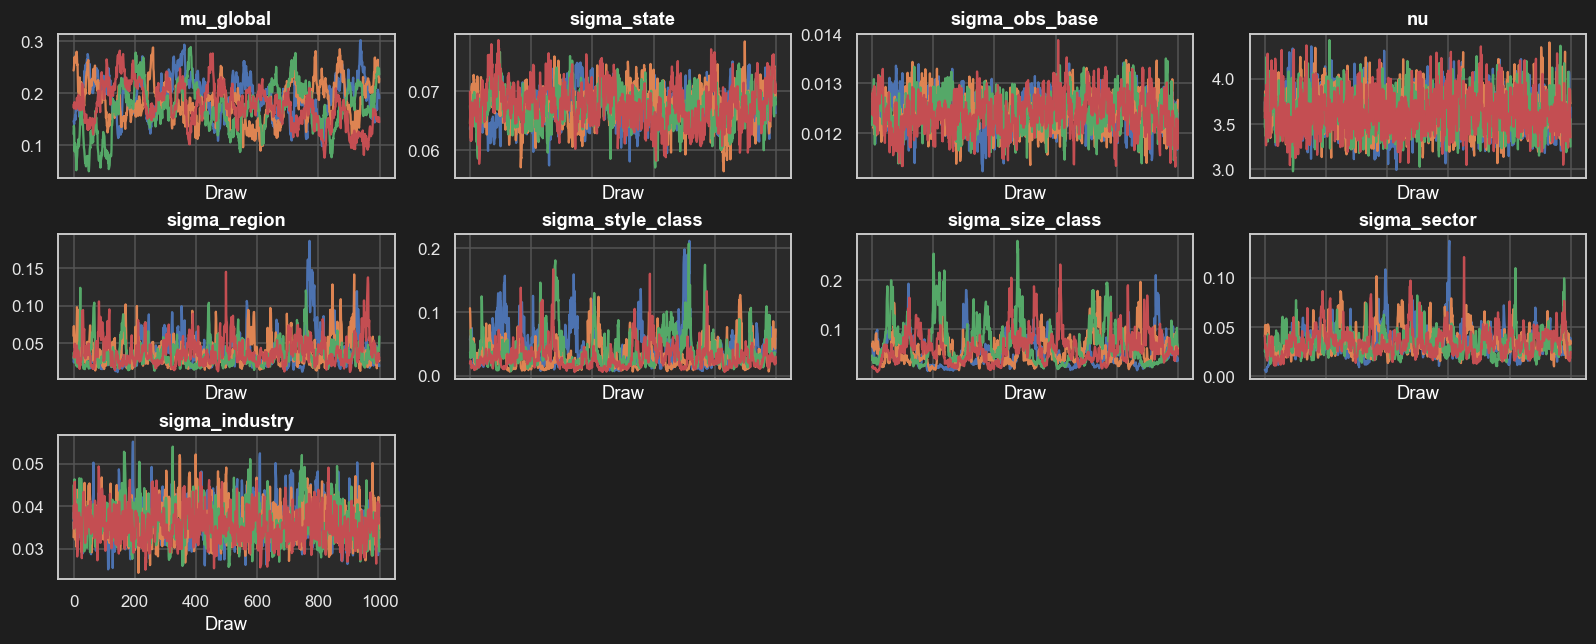

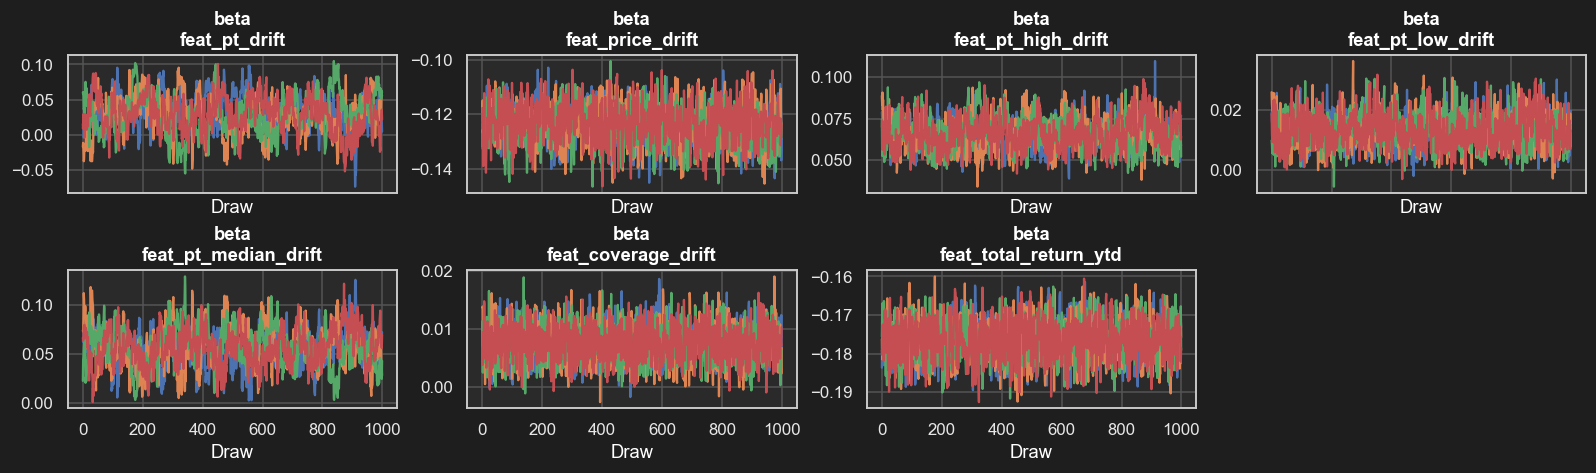

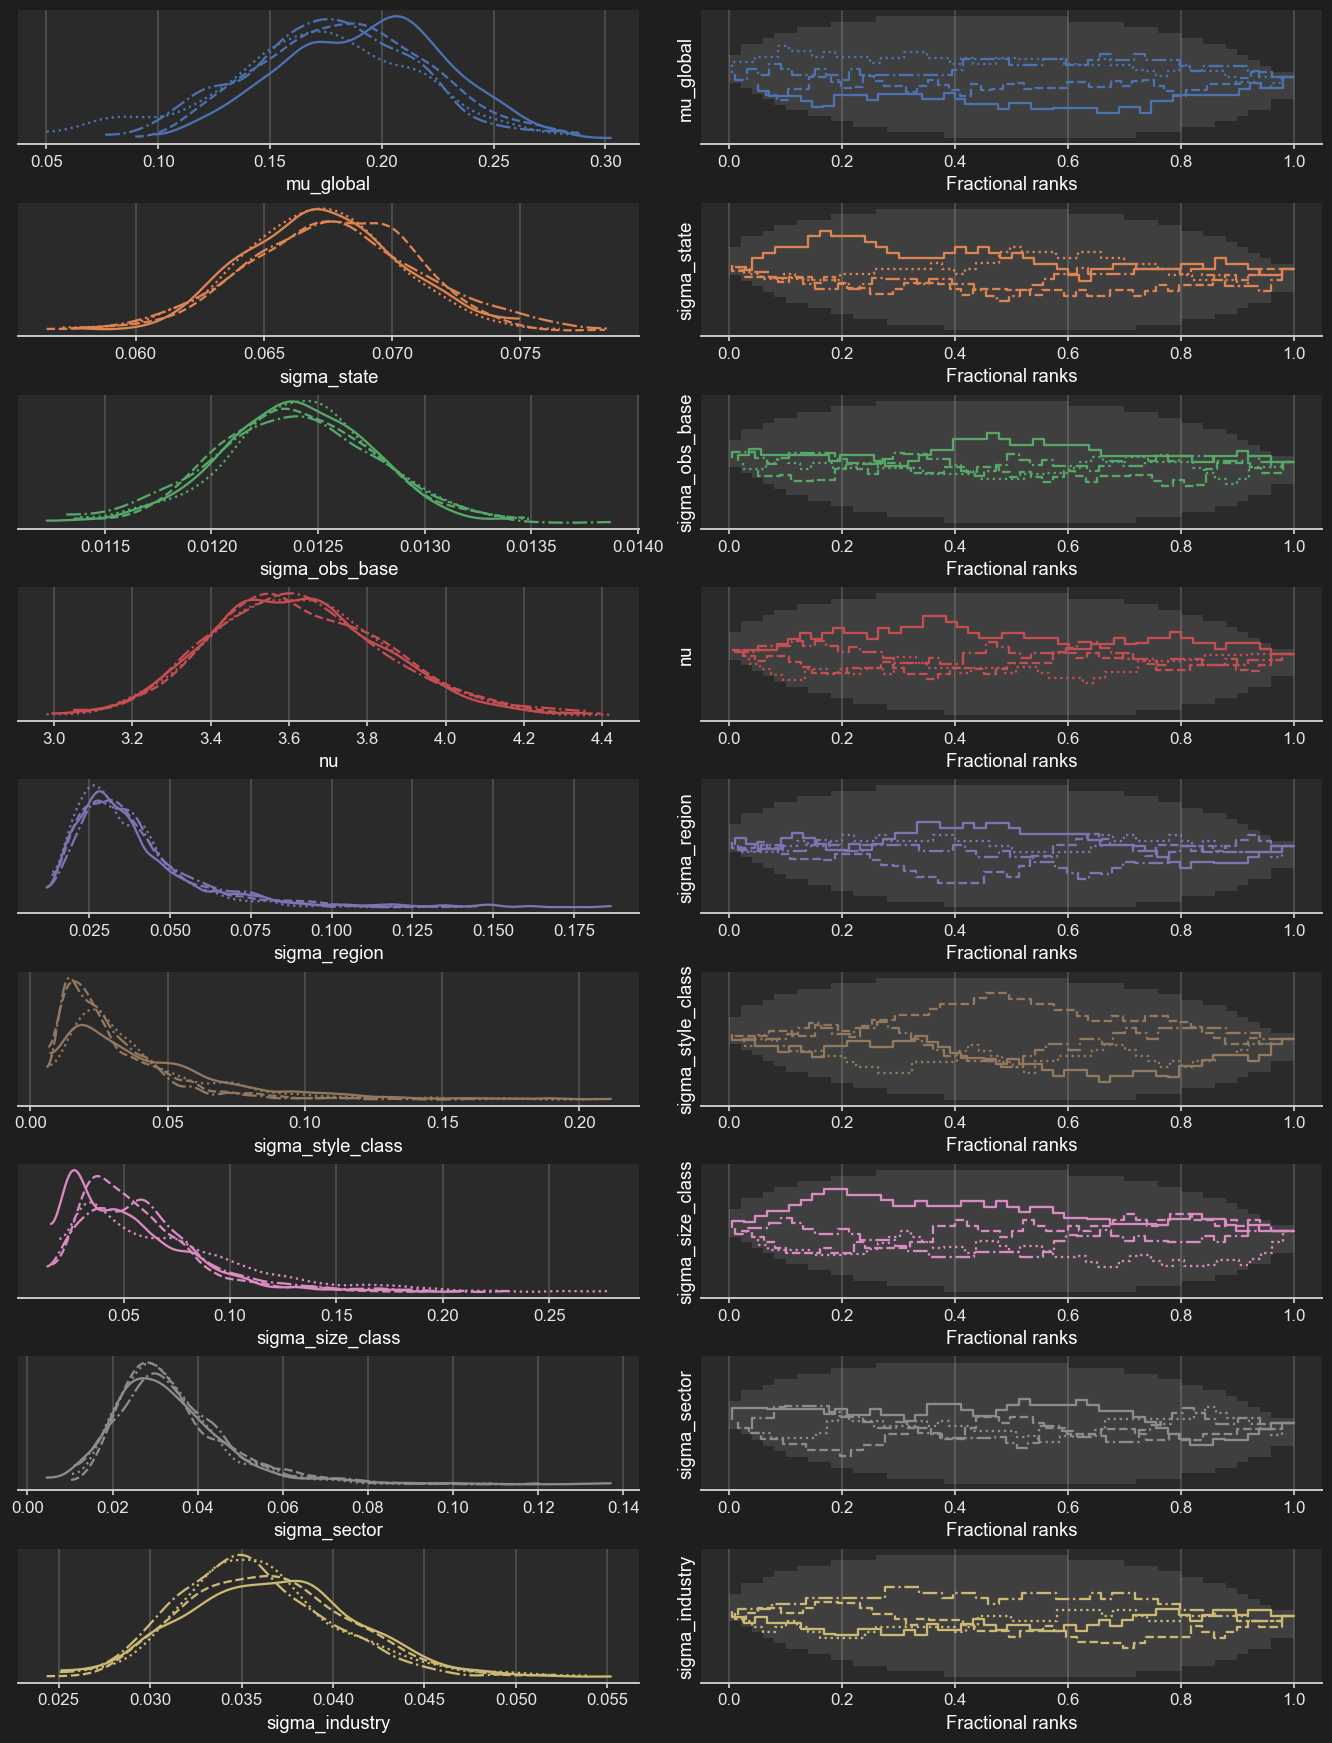

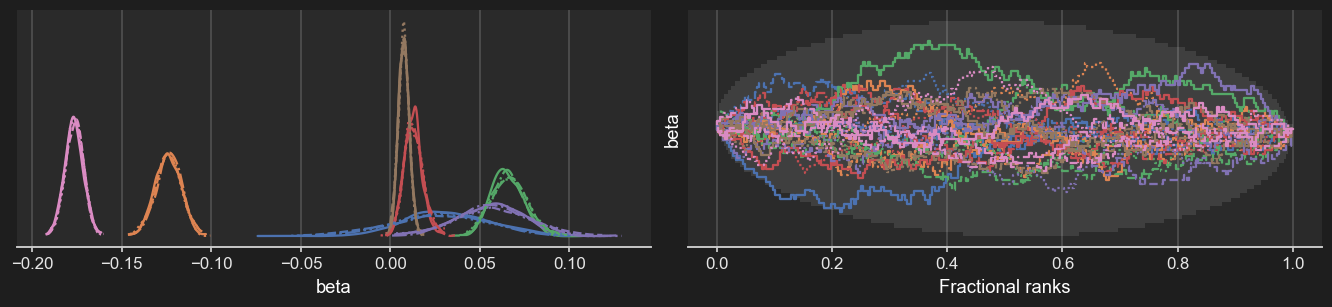

In [26]:
# 9.3 Trace + marginal densities for the key scalar / vector parameters.
# Uses arviz_plots.plot_trace (rank-normalised marginals + per-chain traces).
#
# arviz_plots.plot_trace (v1.1.0) can crash when a single call mixes variables
# whose non-sample dimensions differ: the per-chain aesthetic gets broadcast
# across the extra dim and reshape fails with e.g.
# `cannot reshape array of size 12 into shape (4,)` (4 chains x 3 vector coords).
# We therefore (a) classify each variable from its *actual* posterior shape
# rather than a hard-coded list, plotting any variable that carries an extra
# (vector) dim on its own, and (b) keep a defensive fallback that re-plots the
# scalars one figure per variable if the combined call still raises.
post_trace = idata.posterior
_requested = ['mu_global', 'beta', 'sigma_state', 'sigma_obs_base', 'nu',
              *(f'sigma_{g}' for g in GROUP_EFFECTS)]
_trace_vars = [v for v in _requested if v in post_trace.data_vars]

def _extra_dims(_v):
    return [d for d in post_trace[_v].dims if d not in ('chain', 'draw')]

scalar_vars = [v for v in _trace_vars if not _extra_dims(v)]
vector_vars = [v for v in _trace_vars if _extra_dims(v)]

def _show_trace(_vars):
    pc = azp.plot_trace(idata, var_names=_vars, backend='matplotlib')
    pc.show()

if scalar_vars:
    try:
        _show_trace(scalar_vars)
    except ValueError as exc:
        print(f'Combined scalar trace failed ({exc}); plotting per variable.')
        for _sv in scalar_vars:
            _show_trace([_sv])
for _vv in vector_vars:
    _show_trace([_vv])
if not scalar_vars and not vector_vars:
    print('No trace-eligible variables available.')

# 9.3b Fractional-rank Delta-ECDF plots (arviz_plots.plot_rank_dist).
# Rank plots replace each posterior draw by its rank across *all* chains, then
# plot the per-chain fractional-rank Delta-ECDF: under good mixing every chain's
# curve hugs zero inside the simultaneous confidence band, so systematic drift
# of any chain flags non-convergence that the trace alone can hide.
# plot_rank_dist shares plot_trace's per-chain aesthetic, so it has the *same*
# reshape failure mode when a single call mixes variables with differing
# non-sample dims (e.g. 4 chains x N vector coords). We therefore reuse the
# scalar/vector split above: combine the scalars, plot each vector var on its
# own, and keep the per-variable fallback if the combined scalar call still raises.
def _show_rank_dist(_vars):
    pc = azp.plot_rank_dist(idata, var_names=_vars, backend='matplotlib')
    pc.show()

if scalar_vars:
    try:
        _show_rank_dist(scalar_vars)
    except ValueError as exc:
        print(f'Combined scalar rank-dist failed ({exc}); plotting per variable.')
        for _sv in scalar_vars:
            _show_rank_dist([_sv])
for _vv in vector_vars:
    _show_rank_dist([_vv])
if not scalar_vars and not vector_vars:
    print('No rank-dist-eligible variables available.')

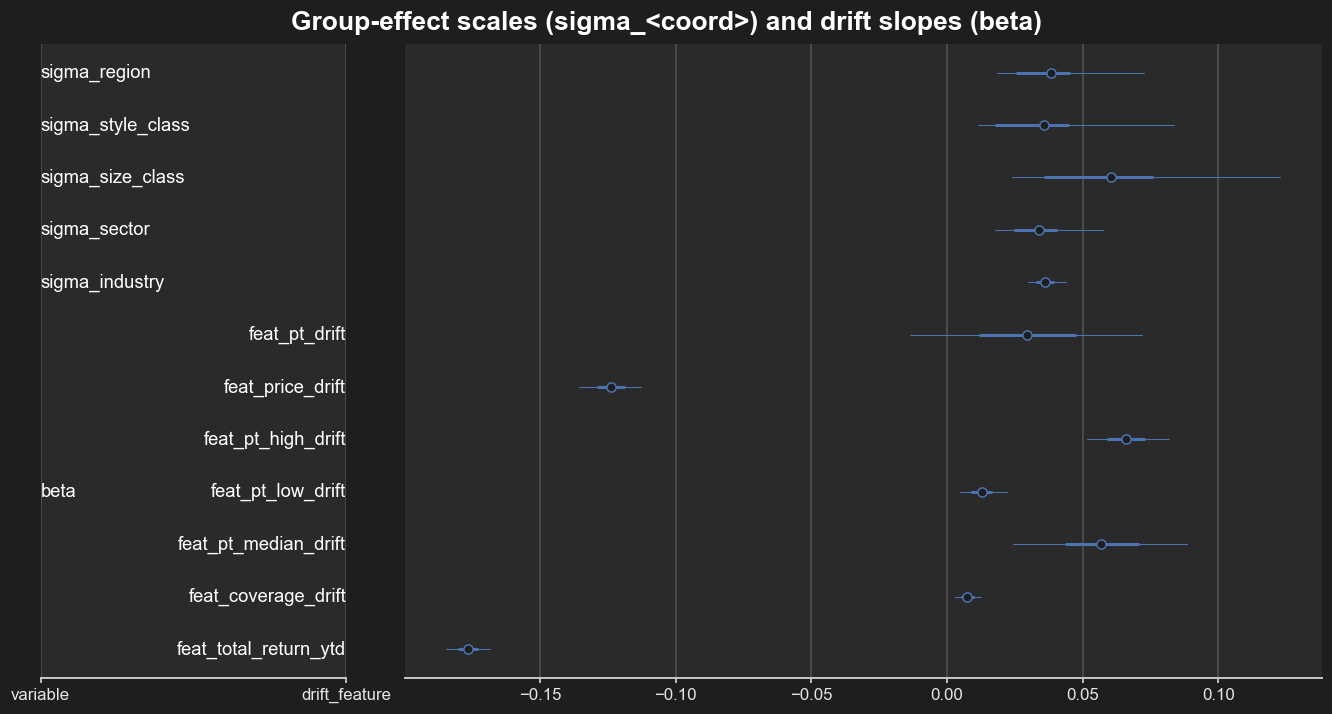

In [27]:
# 9.4 Forest plot of the hierarchical group-effect scales and drift slopes.
import arviz_plots as azp

_forest_vars = [f'sigma_{g}' for g in GROUP_EFFECTS if f'sigma_{g}' in idata.posterior.data_vars]
_forest_vars += [v for v in ('beta',) if v in idata.posterior.data_vars]

if _forest_vars:
    pc = azp.plot_forest(idata, var_names=_forest_vars, combined=True)
    # add_title centres over the grid; plt.title lands on the current column axis only
    # and plt.tight_layout() swaps arviz's constrained-layout engine. Route via the PC.
    pc.add_title('Group-effect scales (sigma_<coord>) and drift slopes (beta)')
    pc.show()
else:
    print('No group-effect / beta variables in posterior - skipped.')

## 10. Expected Price Targets — Posterior Summary

`expected_pt` is the posterior-mean Kalman-smoothed price target (price units);
`expected_upside_pct` is the implied move vs `last_price`. The 94% HDI gives the
credible band around each smoothed target.

In [28]:
# Posterior expected price target (smoothed) + implied upside per ISIN.
post = idata.posterior


def _post_mean(v):
    return post[v].mean(('chain', 'draw')).values


def _post_hdi(v, p=0.94):
    da = post[v].stack(s=('chain', 'draw'))
    lo = da.quantile((1 - p) / 2, dim='s').values
    hi = da.quantile(1 - (1 - p) / 2, dim='s').values
    return lo, hi


exp_pt = _post_mean('expected_pt')
exp_up = _post_mean('expected_upside')
pt_lo, pt_hi = _post_hdi('expected_pt')

results = pd.DataFrame({
    'isin': isin_labels,
    'ticker': model_df.get('ticker'),
    'sector': model_df.get('sector'),
    'last_price': model_df['last_price'].to_numpy(),
    'observed_pt': model_df['observed_pt'].to_numpy(),
    'expected_pt': exp_pt,
    'expected_pt_hdi_lo': pt_lo,
    'expected_pt_hdi_hi': pt_hi,
    'expected_upside_pct': exp_up * 100,
    # Comparative return signals (section 10b): raw analyst-implied upside and
    # realised YTD return, alongside the Kalman-smoothed posterior expected upside.
    'implied_upside_pct': (
        model_df['feat_implied_upside'].to_numpy() * 100
        if 'feat_implied_upside' in model_df.columns
        else (model_df['observed_pt'] / model_df['last_price'] - 1.0).to_numpy() * 100
    ),
    'total_return_ytd_pct': (
        model_df['feat_total_return_ytd'].to_numpy() * 100
        if 'feat_total_return_ytd' in model_df.columns else np.nan
    ),
    'n_analysts': model_df['n_analysts'].to_numpy(),
})
results = results.sort_values('expected_upside_pct', ascending=False).reset_index(drop=True)
print(f'Expected price targets for {len(results)} ISINs.')
results.head(50)

Expected price targets for 6284 ISINs.


,isin,ticker,sector,last_price,observed_pt,expected_pt,expected_pt_hdi_lo,expected_pt_hdi_hi,expected_upside_pct,implied_upside_pct,total_return_ytd_pct,n_analysts
0,US9290332074,VOR,Health Care,13.1600,37.8750,99.828287,83.061715,118.454395,658.573610,187.803951,0.61,8
1,CH0363463438,IDIA,Health Care,4.2980,4.5000,14.597105,12.602428,16.914797,239.625531,4.699860,1.01,3
2,KR7000720003,A000720,Industrials,131900.0000,296578.9474,369798.421743,296790.797678,467736.844784,180.362715,124.851363,89.17,19
3,US09077V1008,BIOA,Health Care,15.7000,49.5000,41.562877,36.005212,47.232545,164.731699,215.286624,18.67,8
4,SE0009581051,ISOFOL,Health Care,0.7230,3.6000,1.911669,1.676327,2.176453,164.407934,397.925311,-0.82,2
5,LU2458332611,ALVO,Health Care,3.5400,13.8333,9.036790,7.802561,10.439153,155.276551,290.771186,-30.99,6
6,JP3891600003,7003,Industrials,4256.0000,7920.0000,10078.563439,8810.881297,11492.290090,136.808351,86.090226,-23.02,5
7,KR7298380007,A298380,Health Care,99800.0000,223200.0000,231067.235768,203875.649813,261593.174861,131.530296,123.647295,-50.10,5
8,FR0010417345,DBV,Health Care,2.8520,3.8000,6.358908,5.528353,7.286506,122.963127,33.239832,-15.62,3
9,US3847471014,GRAL,Health Care,59.9800,66.0000,131.585977,114.847805,150.625432,119.383090,10.036679,-29.92,8


C:\Users\markm\AppData\Local\Temp\ipykernel_1516\830401102.py:11: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


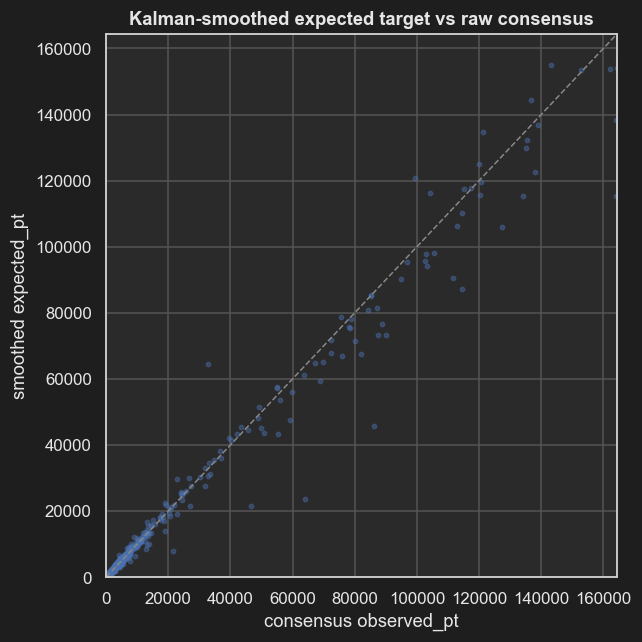

In [29]:
# Shrinkage view: Kalman-smoothed expected_pt vs raw consensus observed_pt.
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(results['observed_pt'], results['expected_pt'], s=8, alpha=0.4)
hi = float(np.nanquantile(results['observed_pt'], 0.99))
ax.plot([0, hi], [0, hi], '--', color='#888888', linewidth=1)
ax.set_xlim(0, hi)
ax.set_ylim(0, hi)
ax.set_xlabel('consensus observed_pt')
ax.set_ylabel('smoothed expected_pt')
ax.set_title('Kalman-smoothed expected target vs raw consensus')
plt.tight_layout()
plt.show()

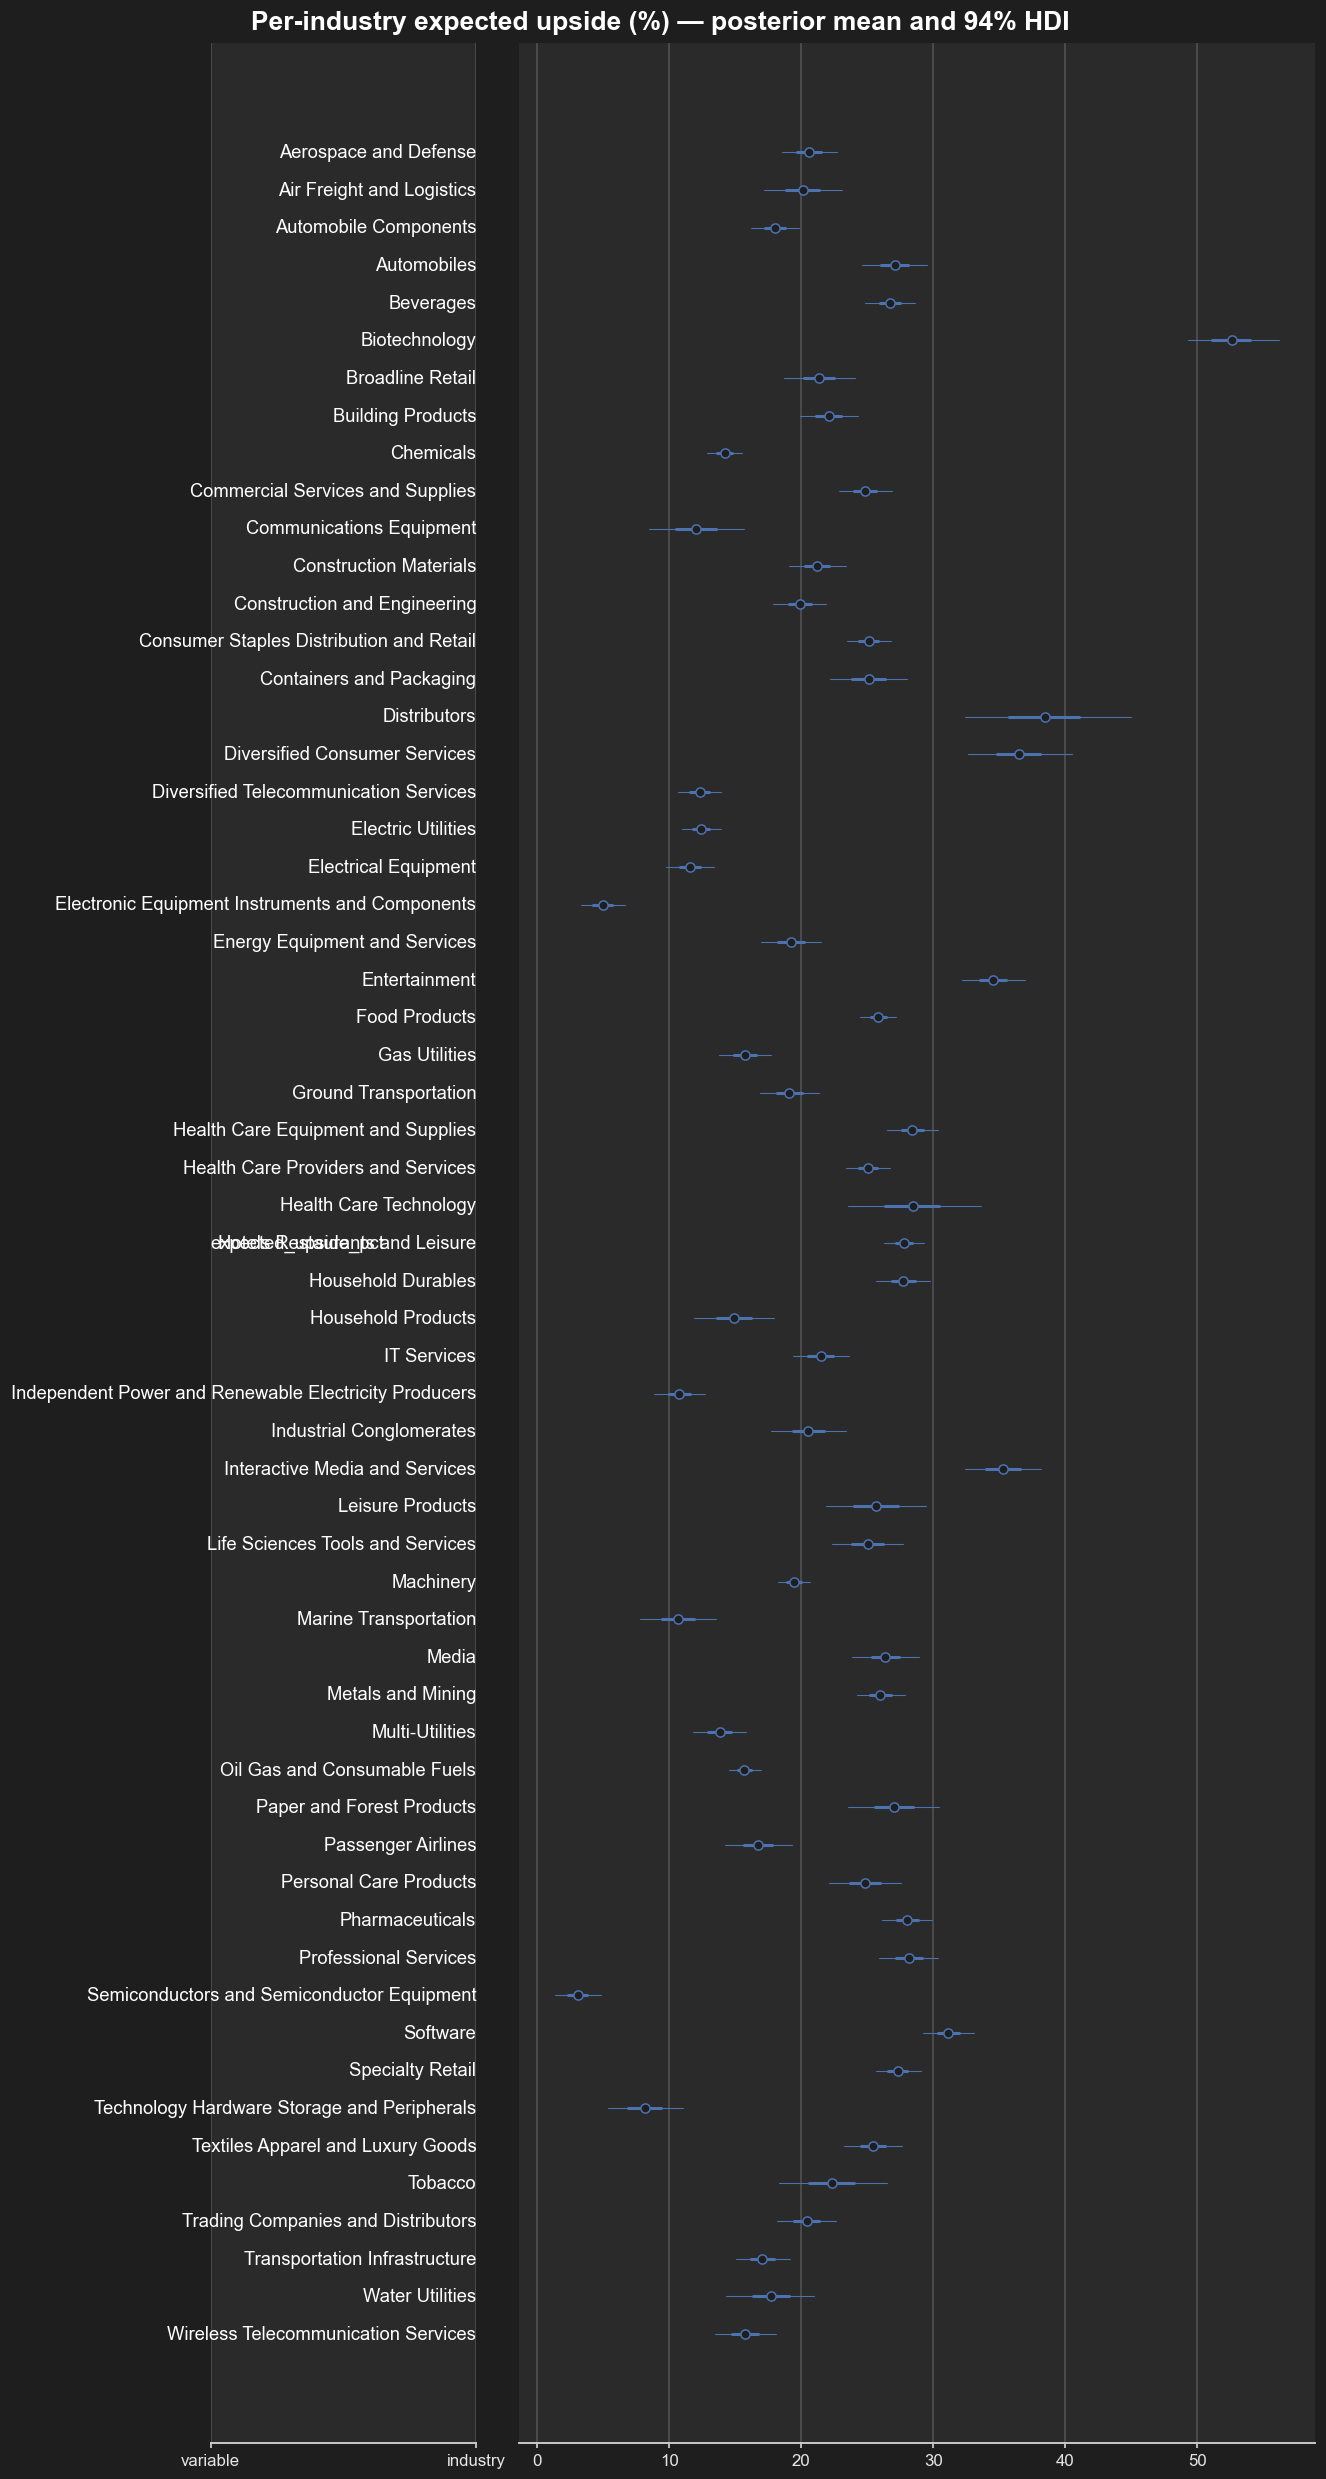

In [30]:
# Per-industry expected_upside posterior - arviz_plots forest with HDIs.
# Aggregates the ISIN-level `expected_upside` posterior samples by industry
# (mean across ISINs within each industry, per draw) so the forest plot
# shows the posterior mean and 94% HDI of the *industry-level* expected upside.
import arviz_plots as azp
import xarray as xr

eu = idata.posterior['expected_upside'] * 100.0  # to percent
_industry_per_isin = model_df['industry'].fillna('Unknown').astype(str).to_numpy()
_industry_da = xr.DataArray(
    _industry_per_isin, dims='isin', coords={'isin': eu.coords['isin']},
)
expected_upside_by_industry = (
    eu.groupby(_industry_da.rename('industry')).mean('isin')
)

_ds_forest = xr.Dataset({'expected_upside_pct': expected_upside_by_industry})

pc = azp.plot_forest(_ds_forest, var_names=['expected_upside_pct'], combined=True)
# Title + display via the PlotCollection (avoids plt.title's wrong-column target and
# the plt.tight_layout() engine swap on arviz's constrained-layout figure).
pc.add_title('Per-industry expected upside (%) — posterior mean and 94% HDI')
pc.show()


C:\Users\markm\AppData\Local\Temp\ipykernel_1516\2502659144.py:22: UserWarning: The figure layout has changed to tight
  plt.tight_layout(); plt.show()


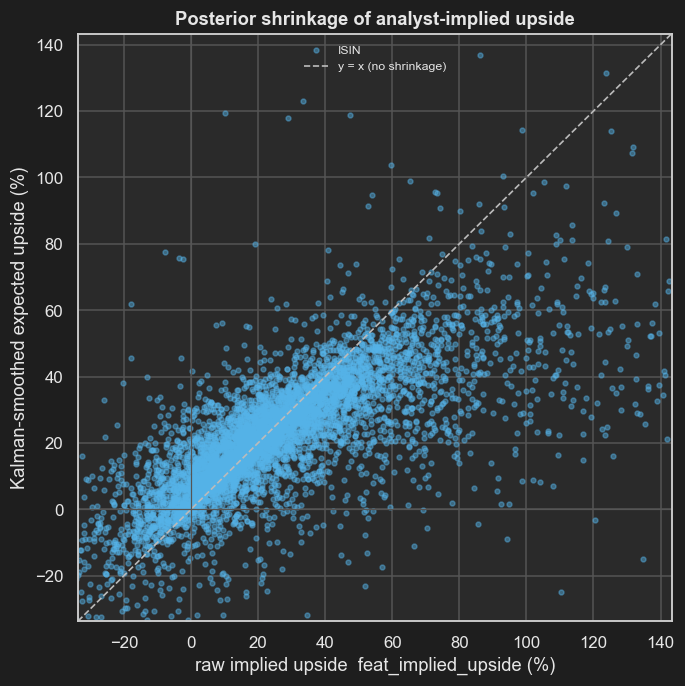

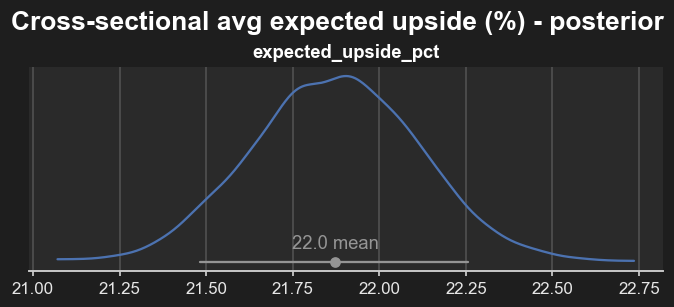

C:\Users\markm\AppData\Local\Temp\ipykernel_1516\2502659144.py:53: UserWarning: The figure layout has changed to tight
  plt.tight_layout(); plt.show()


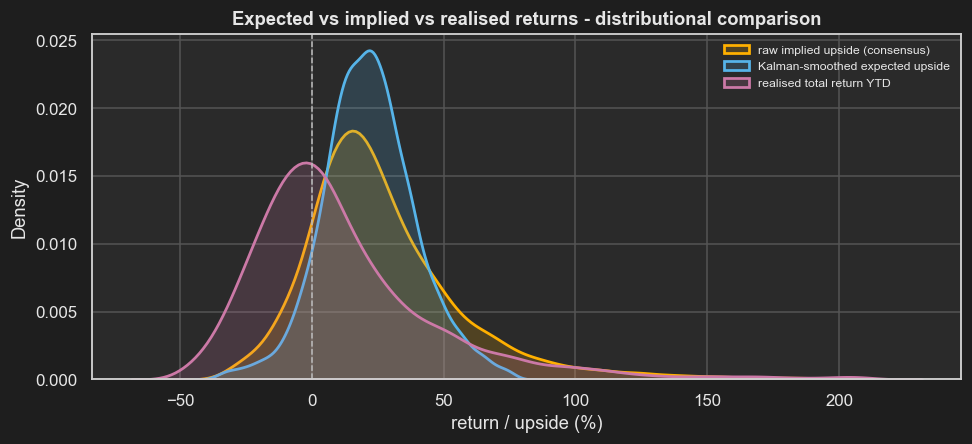

C:\Users\markm\AppData\Local\Temp\ipykernel_1516\2502659144.py:88: UserWarning: The figure layout has changed to tight
  plt.tight_layout(); plt.show()


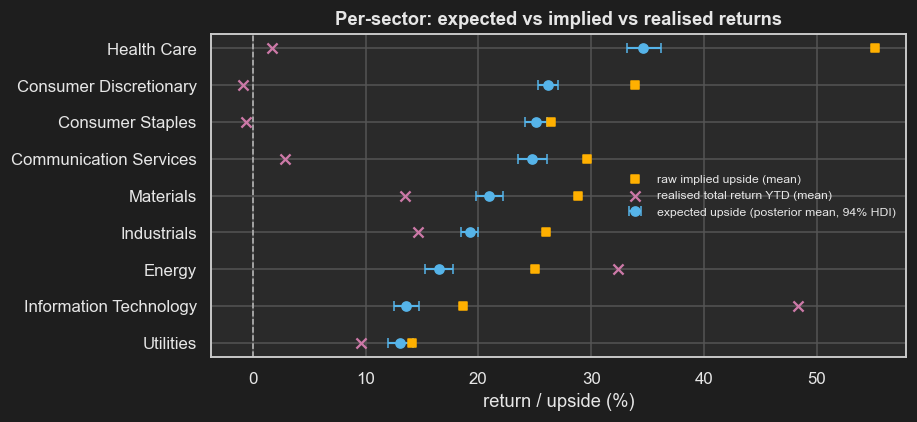

In [31]:
# Section 10b: comparative stock-returns analytics -
# feat_implied_upside (raw analyst consensus) vs expected_upside (Kalman-smoothed
# posterior) vs feat_total_return_ytd (realised YTD return). Three complementary views.
_comp = results.dropna(subset=['expected_upside_pct']).copy()

# (1) Shrinkage scatter: raw analyst-implied upside (x) vs Kalman-smoothed posterior
#     expected upside (y). Points pulled toward y=0 / off the y=x line are shrunk
#     toward the hierarchical group mean.
fig, ax = plt.subplots(figsize=(6.4, 6.4))
ax.scatter(_comp['implied_upside_pct'], _comp['expected_upside_pct'],
           s=10, alpha=0.45, color='#56b4e9', label='ISIN')
_both = np.r_[_comp['implied_upside_pct'].to_numpy(), _comp['expected_upside_pct'].to_numpy()]
_both = _both[np.isfinite(_both)]
_lo, _hi = float(np.nanpercentile(_both, 1)), float(np.nanpercentile(_both, 99))
ax.plot([_lo, _hi], [_lo, _hi], '--', color='#bbbbbb', lw=1.1, label='y = x (no shrinkage)')
ax.axhline(0, color='#555555', lw=0.8); ax.axvline(0, color='#555555', lw=0.8)
ax.set_xlim(_lo, _hi); ax.set_ylim(_lo, _hi)
ax.set_xlabel('raw implied upside  feat_implied_upside (%)')
ax.set_ylabel('Kalman-smoothed expected upside (%)')
ax.set_title('Posterior shrinkage of analyst-implied upside')
ax.legend(fontsize=8, framealpha=0.25)
plt.tight_layout(); plt.show()

# (2) arviz_plots KDE of the posterior cross-sectional-average expected upside, then
#     an empirical KDE overlay of all three signals for a direct expected-vs-implied-
#     vs-realised comparison.
eu_pct = idata.posterior['expected_upside'] * 100.0          # (chain, draw, isin)
try:
    _dist = xr.Dataset({'expected_upside_pct': eu_pct.mean('isin')})
    pc_d = azp.plot_dist(_dist, kind='kde', var_names=['expected_upside_pct'],
                         sample_dims=['chain', 'draw'], backend='matplotlib')
    pc_d.add_title('Cross-sectional avg expected upside (%) - posterior')
    pc_d.show()
except Exception as _e:
    print(f'plot_dist KDE skipped: {_e!r}')

fig, ax = plt.subplots(figsize=(9, 4.2))
for _col, _lab, _c in [
    ('implied_upside_pct', 'raw implied upside (consensus)', '#ffb000'),
    ('expected_upside_pct', 'Kalman-smoothed expected upside', '#56b4e9'),
    ('total_return_ytd_pct', 'realised total return YTD', '#cc79a7'),
]:
    _v = pd.to_numeric(_comp.get(_col), errors='coerce').to_numpy()
    _v = _v[np.isfinite(_v)]
    if _v.size > 5:
        _v = _v[(_v >= np.nanpercentile(_v, 1)) & (_v <= np.nanpercentile(_v, 99))]
    if _v.size:
        sns.kdeplot(_v, ax=ax, label=_lab, color=_c, fill=True, alpha=0.18, lw=1.8)
ax.axvline(0, color='#bbbbbb', ls='--', lw=1.0)
ax.set_xlabel('return / upside (%)')
ax.set_title('Expected vs implied vs realised returns - distributional comparison')
ax.legend(fontsize=8, framealpha=0.25)
plt.tight_layout(); plt.show()

# (3) Per-sector forest-style comparison: posterior expected upside (mean + 94% HDI)
#     against the per-sector mean raw implied upside and realised YTD return. Built
#     with a matplotlib error-bar so the HDI and the two reference series align
#     robustly on one y-axis (reuses the section-10 groupby-by-coord pattern).
_sector_da = xr.DataArray(
    model_df['sector'].fillna('Unknown').astype(str).to_numpy(),
    dims='isin', coords={'isin': eu_pct.coords['isin']},
)
eu_by_sector = eu_pct.groupby(_sector_da.rename('sector')).mean('isin')
_stack = eu_by_sector.stack(s=('chain', 'draw'))
_sec = [str(s) for s in eu_by_sector['sector'].values]
_mean = _stack.mean('s').values
_q_lo = _stack.quantile(0.03, 's').values
_q_hi = _stack.quantile(0.97, 's').values
_ref = (_comp.assign(sector=_comp['sector'].fillna('Unknown').astype(str))
        .groupby('sector')[['implied_upside_pct', 'total_return_ytd_pct']].mean()
        .reindex(_sec))
_order = np.argsort(_mean)
_y = np.arange(len(_sec))
fig, ax = plt.subplots(figsize=(8.5, max(4.0, 0.42 * len(_sec))))
ax.errorbar(_mean[_order], _y,
            xerr=[(_mean - _q_lo)[_order], (_q_hi - _mean)[_order]],
            fmt='o', color='#56b4e9', ecolor='#56b4e9', elinewidth=1.4, capsize=3,
            label='expected upside (posterior mean, 94% HDI)')
ax.scatter(_ref['implied_upside_pct'].to_numpy()[_order], _y, marker='s',
           color='#ffb000', s=34, zorder=6, label='raw implied upside (mean)')
ax.scatter(_ref['total_return_ytd_pct'].to_numpy()[_order], _y, marker='x',
           color='#cc79a7', s=44, zorder=6, label='realised total return YTD (mean)')
ax.axvline(0, color='#bbbbbb', ls='--', lw=1.0)
ax.set_yticks(_y); ax.set_yticklabels(np.array(_sec)[_order])
ax.set_xlabel('return / upside (%)')
ax.set_title('Per-sector: expected vs implied vs realised returns')
ax.legend(fontsize=8, framealpha=0.25, loc='best')
plt.tight_layout(); plt.show()


## 11. Estimated Price Targets Over Time - Single-ISIN Kalman Filter

Sections 5-10 are the **cross-sectional** panel adaptation: one row per ISIN, no time
axis. This section runs the **literal** single-security `GaussianRandomWalk` filter
from `probabilistic_ml_model/pymc_models/KalmanFilterModel.py` to recover the quantity
this model exists for - a **price target evolving over time** with a credible band.

The time axis is reconstructed from the embedded `*_ago` price-target cohort
(`price_target_1w_ago`, `price_target_high_3m_ago`, `price_target_median_1y_ago`, ...),
unpivoted into a `(isin, asof_date, price_target)` panel via
`build_price_target_history()`. The cohort is short (~ 6-16 points) and **irregularly
spaced** (1w, 1m, 3m, 6m, 1y), which is exactly where an explicit latent random walk
funnels.

We therefore fit the **marginalized** parameterization. This is the corrected
integrated-out GRW: the latent path is collapsed analytically into a single
`MvNormal` likelihood whose covariance carries **both** the random-walk (process)
and observation (measurement) variances,

$$\Sigma_{st} = P_0 + \sigma_{\text{state}}^2\,\min(\tau_s, \tau_t) + \sigma_{\text{obs}}^2\,\delta_{st},$$

with $\tau$ the **real elapsed time** between observations (`_resolve_time_deltas`).
The observed log-targets are used *only* as the data - never as the mean - so
`sigma_state` and `sigma_obs` are genuinely identified (the previous revision pinned
the state to the observations, a no-op). The smoothed path is recovered as the
analytic Kalman-smoother mean and rendered with the custom `plot_price_target_path()`
from section 1.1.

The cell is guarded - it degrades cleanly to an informative message if `DB_URL` is
unset or no ISIN carries >= 2 `*_ago` observations.

Pulled pml.pml_df history frame: (6284, 47)  (43 *_ago columns).
Fitting single-ISIN Kalman filter for AEA001901015 (AGTHIA) on 11 observations spanning 2021-06-08 … 2027-01-01.


NUTS[nutpie]: [sigma_state, sigma_obs, log_state_init]


Output()

Marginalized GRW fit: 11 obs, 6y span, divergences=0.


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
sigma_state,0.1017,0.0438,0.0422,0.1797,15933.5676,11106.8102,1.0003,0.0003,0.0003
sigma_obs,0.1554,0.0422,0.1017,0.2300,15518.0726,12423.5939,1.0003,0.0004,0.0005
log_state_init,1.8244,0.1263,1.6225,2.0250,17279.4226,13765.4240,1.0000,0.0010,0.0007


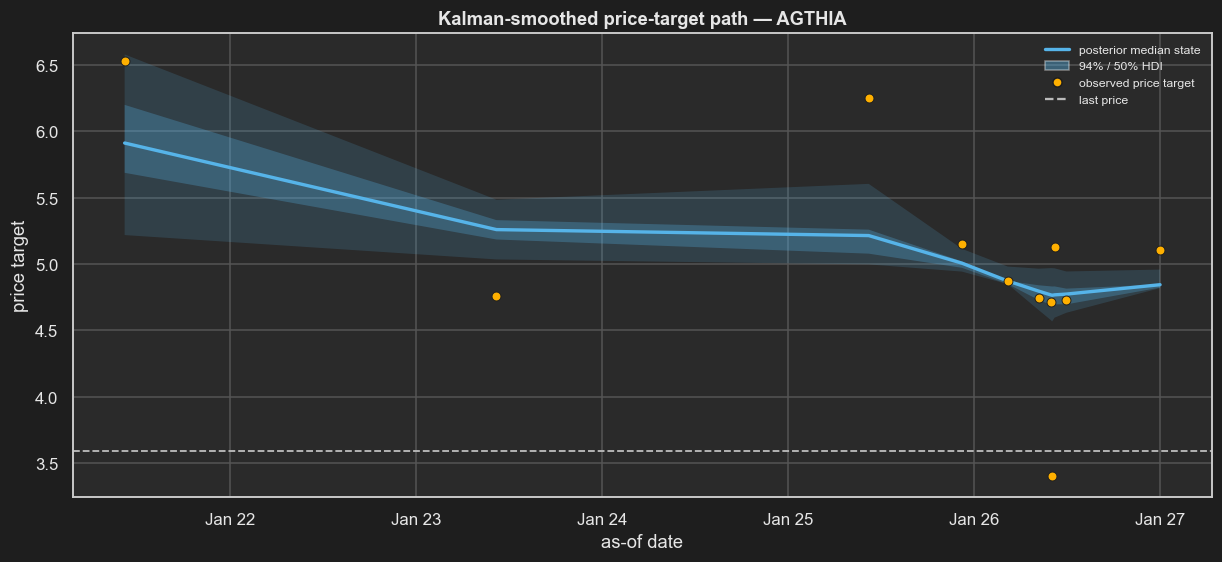

In [32]:
# Single-ISIN time-series Kalman filter on the *_ago price-target history.
import os
from pathlib import Path


def _resolve_db_url(env_file: str = 'environment_variables.txt') -> str:
    """Return DB_URL from the environment, falling back to environment_variables.txt.

    The kernel may have been started without sourcing set_env.ps1, in which case
    os.environ has no 'DB_URL'. We then parse the KEY=VALUE lines of the project's
    environment_variables.txt as a fallback so the section still runs.
    """
    url = os.environ.get('DB_URL')
    if url:
        return url

    here = Path.cwd()
    for base in (here, *here.parents):
        candidate = base / env_file
        if candidate.is_file():
            for raw in candidate.read_text(encoding='utf-8').splitlines():
                line = raw.strip()
                if not line or line.startswith('#') or '=' not in line:
                    continue
                key, _, value = line.partition('=')
                if key.strip() == 'DB_URL':
                    return value.strip().strip('"').strip("'")
            break
    raise KeyError(
        "DB_URL not set in os.environ and not found in environment_variables.txt. "
        "Run `. .\\set_env.ps1` before launching the kernel, or add a DB_URL line."
    )


try:
    from sqlalchemy import create_engine, text
    from probabilistic_ml_model.pymc_models.KalmanFilterModel import KalmanFilterPriceTarget

    engine = create_engine(_resolve_db_url())
    cohort = model_df['isin'].astype(str).tolist()

    # Discover the *_ago price-target history columns that actually exist in
    # pml.pml_df, then pull only those (+ identifiers) for the modelled cohort.
    _hist_re = (r"^(price_target(_high|_low|_median)?|price)"
                r"_(5d|1w|1m|3m|6m|1y|3y|5y|mtd|qtd|ytd)_ago$")
    with engine.connect() as conn:
        hist_cols = pd.read_sql(
            text("""
                SELECT column_name
                FROM information_schema.columns
                WHERE table_schema = 'pml' AND table_name = 'pml_df'
                  AND (column_name ~ :pat
                       OR column_name IN ('isin', 'ticker', 'last_price', 'price_target'))
                ORDER BY column_name
            """),
            conn, params={'pat': _hist_re},
        )['column_name'].tolist()

        col_sql = ', '.join(f'"{c}"' for c in hist_cols)
        snap = pd.read_sql(
            text(f'SELECT {col_sql} FROM pml.pml_df WHERE isin = ANY(:isins)'),
            conn, params={'isins': cohort},
        )

    n_ago = sum(c.endswith('_ago') for c in hist_cols)
    print(f'Pulled pml.pml_df history frame: {snap.shape}  ({n_ago} *_ago columns).')

    # Unpivot *_ago -> long (isin, asof_date, price_target); pick richest ISIN in
    # the cohort. now_cols omits last_price so the target series is not polluted
    # by the spot price (last_price is shown separately as the reference line).
    long_df, eligible, date_col = KalmanFilterPriceTarget.build_price_target_history(
        snap, now_cols=('price_target',),
    )
    chosen = KalmanFilterPriceTarget.select_target_isin(eligible, cohort=cohort)

    if chosen is None or date_col is None:
        print('No ISIN has >= 2 *_ago price-target observations; section skipped.')
    else:
        ts = (long_df.loc[long_df['isin'] == chosen, ['asof_date', 'price_target']]
              .dropna().sort_values('asof_date').reset_index(drop=True))
        dates = pd.DatetimeIndex(ts['asof_date'])
        observed = ts['price_target'].to_numpy()

        _row = model_df.loc[model_df['isin'] == chosen]
        ticker = str(_row['ticker'].iloc[0]) if len(_row) else str(chosen)
        last_price = float(_row['last_price'].iloc[0]) if len(_row) else None

        print(f'Fitting single-ISIN Kalman filter for {chosen} ({ticker}) '
              f'on {len(observed)} observations spanning '
              f'{dates.min():%Y-%m-%d} … {dates.max():%Y-%m-%d}.')

        kf = KalmanFilterPriceTarget()
        # Short, irregular *_ago cohort -> use the corrected *marginalized* GRW
        # (the latent path is integrated out into the MvNormal covariance, scaled
        # by real elapsed time). This is what parameterization='auto' selects for
        # series below the short-series threshold; we set it explicitly so the
        # section deterministically exercises the funnel-free path.
        kf_idata, kf_model = kf.fit(
            price_targets=observed, isin=str(chosen), dates=dates,
            samples=2500, tune=2000, chains=8,
            random_seed=RANDOM_SEED, parameterization='marginalized',
            target_accept=0.95, nuts_sampler='nutpie',
        )

        n_div = int(kf_idata.sample_stats['diverging'].sum())
        print(f'Marginalized GRW fit: {len(observed)} obs, '
              f'{dates.max().year - dates.min().year}y span, divergences={n_div}.')
        display(azs.summary(kf_idata,
                            var_names=['sigma_state', 'sigma_obs', 'log_state_init'],
                            round_to=4))

        # Headline custom plot — Kalman-smoothed price-target path over time.
        pc_path = plot_price_target_path(
            kf_idata, observed=observed, dates=dates,
            last_price=last_price, ticker=ticker,
        )
        pc_path.show()
except Exception as e:  # pragma: no cover - optional / environment-dependent
    print(f'Section 11 (single-ISIN time-series Kalman) skipped: {e!r}')

## 12. Estimated Price Targets over upcoming/recent Earnings Period - Mingle-ISIN Kalman Filter

Section 11 fits the literal single-security `GaussianRandomWalk` filter on the one ISIN
with the richest `*_ago` history. This section keeps the same state-space machinery but
re-frames **what the time axis represents**: instead of one security's history, it builds
a **mingled cross-sectional consensus** over every ISIN whose `next_earnings` lands in the
**recent earnings window**

```sql
SELECT *

WHERE next_earnings >= current_date - INTERVAL '1 week'
  AND next_earnings <= current_date + INTERVAL '1 week'
```

i.e. names reporting in the ±1-week band around today. For each such ISIN we unpivot the
embedded `*_ago` price-target cohort (`price_target_1w_ago`, `price_target_high_3m_ago`,
`price_target_median_1y_ago`, …) into a `(isin, asof_date, price_target)` panel via
`KalmanFilterPriceTarget.build_price_target_history()`, then **mingle the ISINs** by taking
the cross-sectional **median** price target at each shared `asof_date`. The result is a
single, time-ordered series — the earnings-cohort consensus price target as it evolved over
the recent earnings period — which is exactly the quantity the Kalman filter smooths.

The cohort series is short (~6-16 points) and **irregularly spaced** (1w, 1m, 3m, 6m, 1y),
so we fit the **marginalized** parameterization (the integrated-out GRW whose `MvNormal`
covariance carries both the random-walk and observation variances, scaled by real elapsed
time via `_resolve_time_deltas`). This is funnel-free for sparse, irregular cohorts.

**Visual comparison of the three quantities** (`last_price`, `observed_price_target`,
`expected_pt`):

- `expected_pt` — the posterior-mean Kalman-smoothed latent state (`state` in price space),
  with 94 % / 50 % HDI bands.
- `observed_price_target` — the mingled cohort-median consensus target at each `asof_date`.
- `last_price` — the cohort-median spot price, drawn as a dashed reference line.

Rendered as (a) the headline `plot_price_target_path()` time-series composition, (b) an
ArviZ `plot_forest` of the per-`asof_date` `expected_pt` posterior HDIs, and (c) a tidy
comparison table. The cell is guarded — it degrades cleanly to an informative message if
`DB_URL` is unset or the earnings window yields fewer than 2 mingled observations.


Recent-earnings window cohort: 187 rows / 187 ISINs (43 *_ago columns).
Fitting mingled-cohort Kalman filter on 11 consensus observations spanning 2021-06-08 ... 2027-01-01.


NUTS[nutpie]: [sigma_state, sigma_obs, log_state_init]


Output()

Marginalized GRW fit: 11 obs, 2033d span, divergences=0.


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
sigma_state,0.1260,0.0439,0.0624,0.2014,14380.0183,9867.7461,1.0008,0.0003,0.0003
sigma_obs,0.1177,0.0393,0.0686,0.1885,15486.3312,13380.1483,1.0005,0.0003,0.0004
log_state_init,2.6886,0.1328,2.4767,2.9009,17618.4039,13180.5237,1.0008,0.0010,0.0007


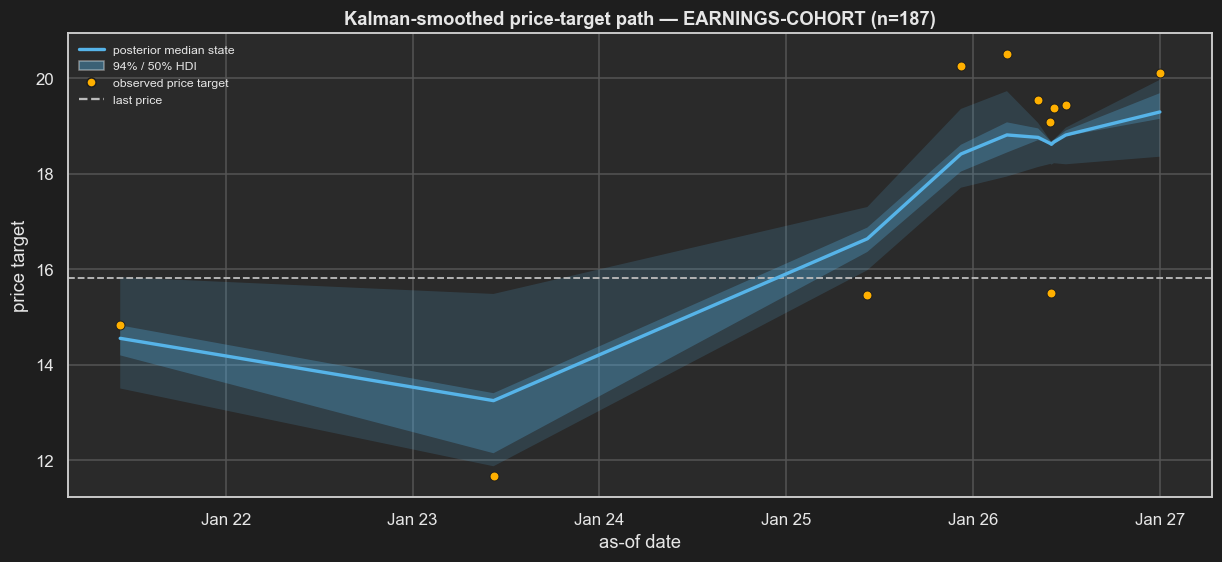

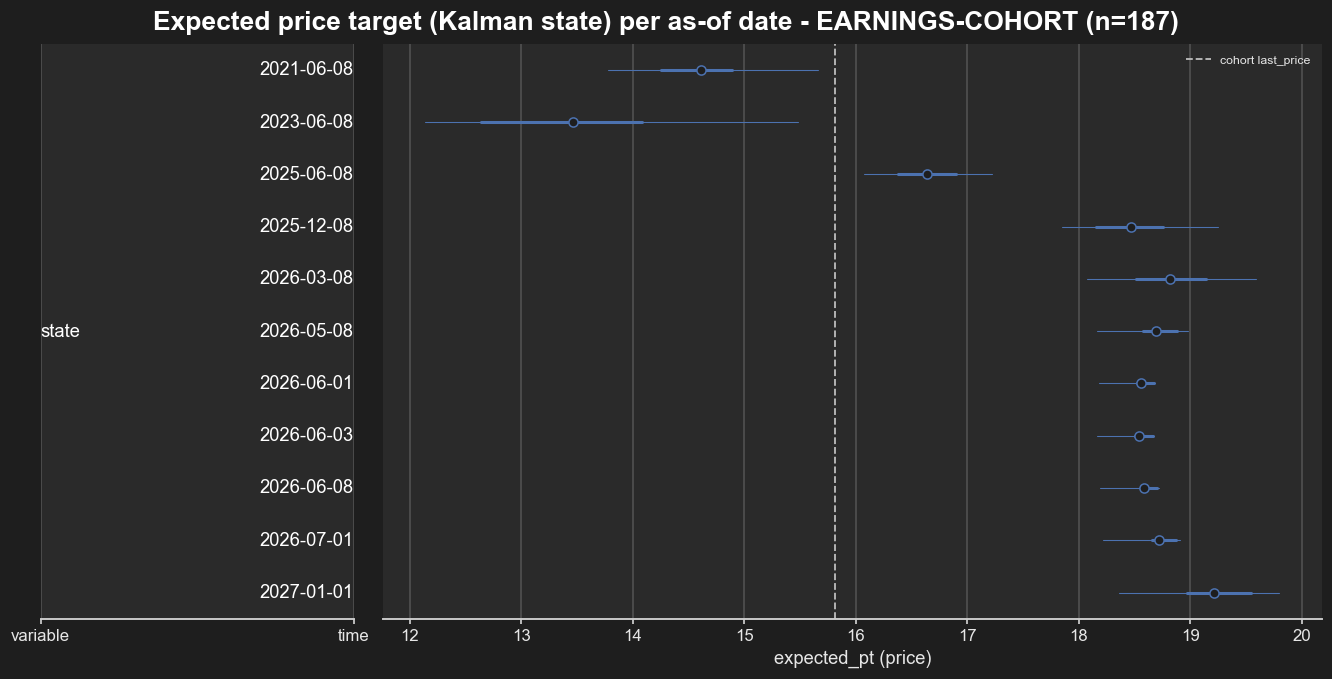

Mingled-cohort comparison (last_price vs observed_pt vs expected_pt):


,asof_date,n_isin,observed_pt,expected_pt,expected_pt_hdi_lo,expected_pt_hdi_hi,last_price,expected_vs_observed_pct
0,2021-06-08,145,14.820,14.609,13.619,16.005,15.81,-1.426
1,2023-06-08,163,11.660,13.465,12.042,15.949,15.81,15.480
2,2025-06-08,177,15.465,16.641,15.983,17.310,15.81,7.602
3,2025-12-08,186,20.246,18.468,17.744,19.396,15.81,-8.785
4,2026-03-08,187,20.498,18.822,17.927,19.720,15.81,-8.178
5,2026-05-08,187,19.543,18.688,18.005,19.008,15.81,-4.375
6,2026-06-01,187,19.091,18.556,18.026,18.688,15.81,-2.802
7,2026-06-03,186,15.500,18.540,18.021,18.674,15.81,19.613
8,2026-06-08,187,19.375,18.587,18.034,18.716,15.81,-4.067
9,2026-07-01,187,19.436,18.716,18.055,18.919,15.81,-3.707


In [33]:
# Mingle-ISIN time-series Kalman filter over the recent-earnings-window cohort.
# Reuses _resolve_db_url(), KalmanFilterPriceTarget, plot_price_target_path() and
# RANDOM_SEED defined earlier in the notebook.
try:
    from sqlalchemy import create_engine, text
    from probabilistic_ml_model.pymc_models.KalmanFilterModel import KalmanFilterPriceTarget

    engine = create_engine(_resolve_db_url())

    # Discover the *_ago price-target history columns present in pml.pml_df, plus
    # the identifiers / reference columns and the next_earnings timing column used
    # to scope the recent-earnings window.
    _hist_re = (r"^(price_target(_high|_low|_median)?|price)"
                r"_(5d|1w|1m|3m|6m|1y|3y|5y|mtd|qtd|ytd)_ago$")
    with engine.connect() as conn:
        hist_cols = pd.read_sql(
            text("""
                SELECT column_name
                FROM information_schema.columns
                WHERE table_schema = 'pml' AND table_name = 'pml_df'
                  AND (column_name ~ :pat
                       OR column_name IN ('isin', 'ticker', 'last_price',
                                          'price_target', 'next_earnings'))
                ORDER BY column_name
            """),
            conn, params={'pat': _hist_re},
        )['column_name'].tolist()

        col_sql = ', '.join(f'"{c}"' for c in hist_cols)
        # Time axis = the recent earnings period: names reporting within +/- 5 days
        # of today. next_earnings is the pml.pml_df earnings-timing column.
        snap = pd.read_sql(
            text(f"""
                SELECT {col_sql}
                FROM pml.pml_df
                WHERE next_earnings >= '2026-01-01'
                  AND next_earnings >= current_date - INTERVAL '5 days'
                  AND next_earnings <= current_date + INTERVAL '5 days'
            """),
            conn,
        )

    n_ago = sum(c.endswith('_ago') for c in hist_cols)
    n_cohort = snap['isin'].nunique() if 'isin' in snap.columns else 0
    print(f'Recent-earnings window cohort: {snap.shape[0]} rows / {n_cohort} ISINs '
          f'({n_ago} *_ago columns).')

    # Unpivot *_ago -> long (isin, asof_date, price_target) for the whole cohort.
    # now_cols omits last_price so the target series is not polluted by spot price.
    long_df, _eligible, date_col = KalmanFilterPriceTarget.build_price_target_history(
        snap, now_cols=('price_target',),
    )

    if date_col is None or long_df.empty:
        print('No *_ago price-target history in the earnings window; section skipped.')
    else:
        # MINGLE the ISINs: cross-sectional median price target at each shared
        # asof_date -> a single earnings-cohort consensus series over time.
        mingled = (
            long_df.groupby('asof_date', as_index=False)
            .agg(price_target=('price_target', 'median'),
                 n_isin=('isin', 'nunique'))
            .sort_values('asof_date')
            .reset_index(drop=True)
        )

        if len(mingled) < 2:
            print(f'Mingled cohort has only {len(mingled)} distinct as-of date(s); '
                  'need >= 2 for a Kalman fit. Section skipped.')
        else:
            dates = pd.DatetimeIndex(mingled['asof_date'])
            observed = mingled['price_target'].to_numpy()
            # Cohort-median spot price as the reference last_price.
            last_price = (float(np.nanmedian(snap['last_price']))
                          if 'last_price' in snap.columns
                          and np.isfinite(np.nanmedian(snap['last_price'])) else None)
            label = f'EARNINGS-COHORT (n={n_cohort})'

            print(f'Fitting mingled-cohort Kalman filter on {len(observed)} '
                  f'consensus observations spanning '
                  f'{dates.min():%Y-%m-%d} ... {dates.max():%Y-%m-%d}.')

            kf = KalmanFilterPriceTarget()
            # Short, irregular cohort -> corrected marginalized (integrated-out) GRW.
            kf_idata, kf_model = kf.fit(
                price_targets=observed, isin=label, dates=dates,
                samples=2500, tune=2000, chains=8,
                random_seed=RANDOM_SEED, parameterization='marginalized',
                target_accept=0.95, nuts_sampler='nutpie',
            )

            n_div = int(kf_idata.sample_stats['diverging'].sum())
            print(f'Marginalized GRW fit: {len(observed)} obs, '
                  f'{(dates.max() - dates.min()).days}d span, divergences={n_div}.')
            display(azs.summary(
                kf_idata,
                var_names=['sigma_state', 'sigma_obs', 'log_state_init'],
                round_to=4))

            # (a) Headline composition: expected_pt smoothed path + HDI bands,
            #     observed mingled consensus targets, and last_price reference.
            pc_path = plot_price_target_path(
                kf_idata, observed=observed, dates=dates,
                last_price=last_price, ticker=label,
            )
            pc_path.show()

            # (b) ArviZ forest of the per-as-of-date expected_pt (latent `state`)
            #     posterior HDIs, with the cohort last_price as a reference line.
            _state = kf_idata.posterior['state']
            _state = _state.assign_coords(
                time=[d.strftime('%Y-%m-%d') for d in dates]
            )
            pc_state = azp.plot_forest(_state.to_dataset(), var_names=['state'],
                                       combined=True, backend='matplotlib')
            # Decorate the forest-column axis directly: plt.axvline previously landed
            # on whichever column was current (often the labels column, hiding the
            # reference line), and plt.tight_layout() swaps arviz's layout engine.
            _ax_state = pc_state.viz['plot'].sel(column='forest').item()
            if last_price is not None:
                _ax_state.axvline(last_price, ls='--', color='#bbbbbb', lw=1.2,
                                  label='cohort last_price')
                _ax_state.legend(fontsize=8, framealpha=0.25)
            _ax_state.set_xlabel('expected_pt (price)')
            pc_state.add_title(
                f'Expected price target (Kalman state) per as-of date - {label}')
            pc_state.show()

            # (c) Tidy comparison table: last_price vs observed_pt vs expected_pt.
            _post = kf_idata.posterior['state']
            _mean = _post.mean(('chain', 'draw')).values
            _stk = _post.stack(s=('chain', 'draw'))
            _lo = _stk.quantile(0.03, dim='s').values
            _hi = _stk.quantile(0.97, dim='s').values
            comparison = pd.DataFrame({
                'asof_date': dates.strftime('%Y-%m-%d'),
                'n_isin': mingled['n_isin'].to_numpy(),
                'observed_pt': observed,
                'expected_pt': _mean,
                'expected_pt_hdi_lo': _lo,
                'expected_pt_hdi_hi': _hi,
                'last_price': last_price,
            })
            comparison['expected_vs_observed_pct'] = (
                (comparison['expected_pt'] / comparison['observed_pt'] - 1.0) * 100
            )
            print('Mingled-cohort comparison (last_price vs observed_pt vs expected_pt):')
            display(comparison.round(3))
except Exception as e:  # pragma: no cover - optional / environment-dependent
    print(f'Section 12 (mingle-ISIN earnings-window Kalman) skipped: {e!r}')

## 13. Granular Earnings-Cohort Expected-Price Simulation - Posterior-Predictive Forest

Section 12 **mingles** the recent-earnings cohort into a single cross-sectional median series
and refits the literal single-series Kalman filter. This section keeps the cohort definition
identical - **names reporting within +/- 5 days of today** (`next_earnings`) - but goes the
other way: it stays **per-ISIN granular** and re-uses the already-fitted cross-sectional
state-space posterior from sections 5-10 instead of refitting.

For every cohort ISIN the model's log-space measurement likelihood (`log_uplift_obs`, the
posterior-predictive log-uplift) is mapped back to **price units** via
`last_price * exp(log_uplift_obs)`, giving a posterior-predictive distribution of the
*expected stock price* (the simulated analyst price target) for that name. These per-ISIN
predictive distributions are rendered as an `arviz_plots` **posterior-predictive forest**,
with the realised analyst targets overlaid as observation points, following the
`plot_forest(group="posterior_predictive") + visuals.scatter_x` composition pattern.

Two reference layers make the forest readable as a screen:

- **Reference HDI bands** (`add_bands`) - the cohort's central expected-price region, taken
  directly from the **posterior HDIs** of the pooled `expected_pt` latent state (94 % band
  lightest, 50 % band darker). Names whose predictive interval sits entirely outside the
  94 % band are the cohort's relative outliers going into earnings.
- **Cohort `last_price` reference line** (`add_lines`) - the median spot price across the
  cohort, drawn as a dashed vertical line so the simulated targets can be read as implied
  upside / downside.

The cell is guarded - it degrades cleanly to an informative message if `DB_URL` is unset or
no earnings-window ISIN overlaps the fitted cross-sectional posterior. When the cohort is
large the forest is capped to the most extreme names by expected upside (top/bottom 20) to
keep one row per ISIN legible; the truncation is announced.


Recent-earnings cohort (next_earnings +/-5d): 187 ISINs.
Cohort ISINs overlapping the fitted posterior: 187.
Cohort has 187 ISINs; showing the 50 most extreme by expected upside (top/bottom 25).


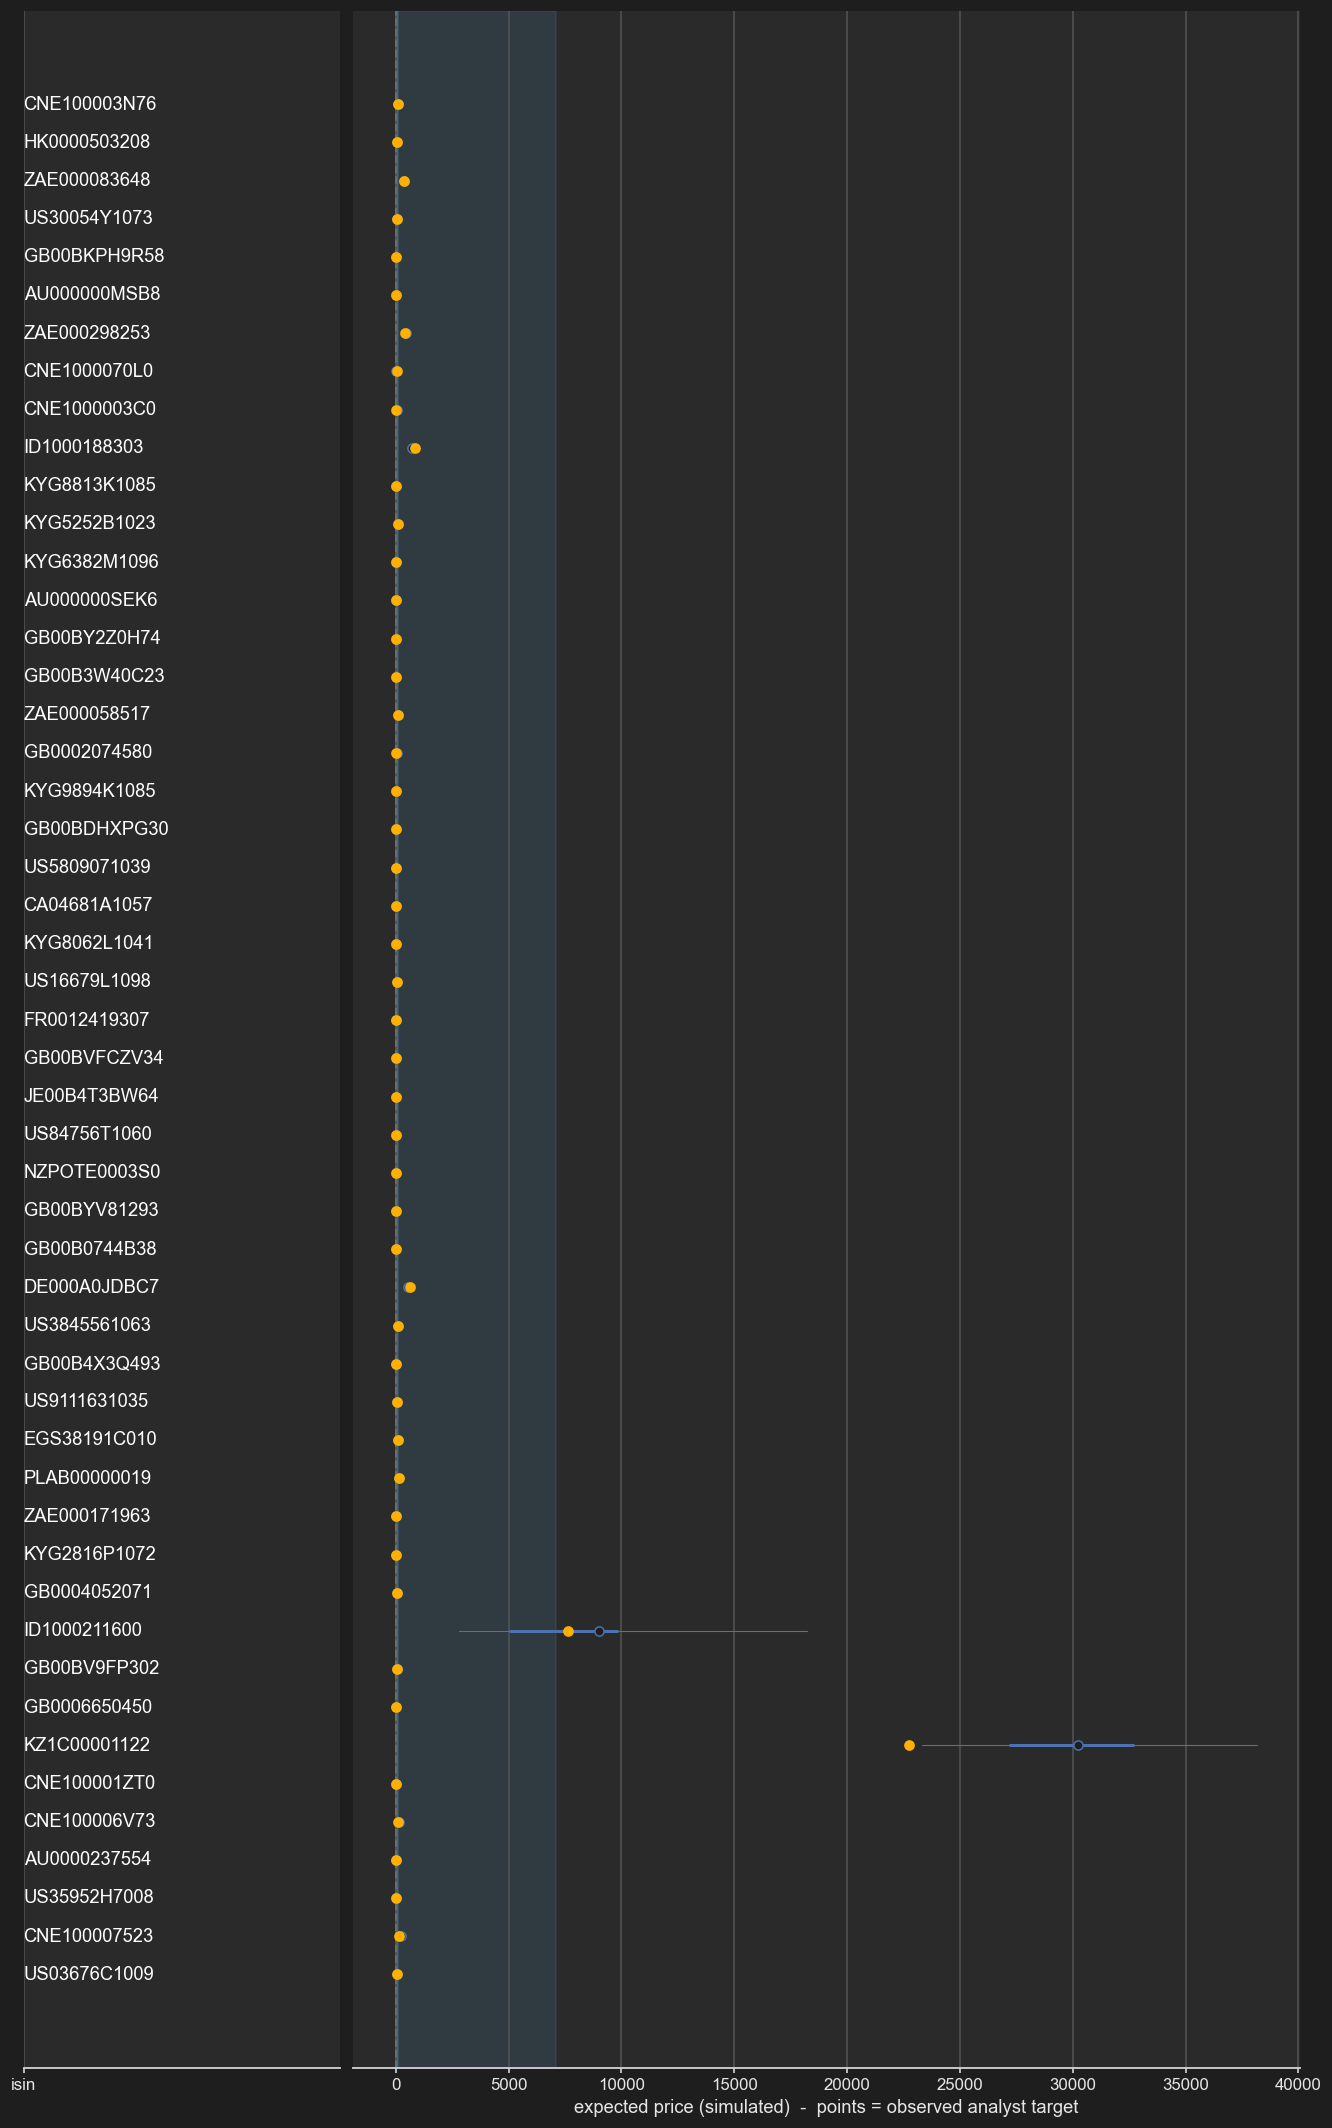

Cohort expected_pt 94% HDI band: (0.12, 7080.68);  50% HDI band: (3.96, 82.36);  cohort last_price ref = 17.90.


,isin,ticker,sector,last_price,observed_pt,expected_pt,expected_pt_hdi_lo,expected_pt_hdi_hi,expected_upside_pct
0,CNE100003N76,2696,Health Care,60.200,102.939,109.355,96.770,123.285,81.654
1,HK0000503208,6055,Consumer Discretionary,23.260,46.600,41.236,36.304,46.519,77.282
2,ZAE000083648,IMP,Materials,200.680,351.056,354.904,314.248,398.081,76.851
3,US30054Y1073,EVMN,Health Care,19.920,52.250,34.641,30.436,39.432,73.899
4,GB00BKPH9R58,LBG,Communication Services,0.359,1.150,0.604,0.529,0.685,68.119
5,AU000000MSB8,MSB,Health Care,2.050,3.798,3.427,3.018,3.859,67.175
6,ZAE000298253,NPH,Materials,277.910,403.921,462.258,408.328,522.566,66.334
7,CNE1000070L0,2590,Industrials,14.990,32.939,24.749,21.603,28.195,65.104
8,CNE1000003C0,1133,Industrials,18.470,31.489,30.493,26.908,34.406,65.094
9,ID1000188303,MBMA,Materials,434.000,844.435,712.071,627.376,802.377,64.072


In [34]:
# Granular per-ISIN posterior-predictive forest of simulated expected prices for the
# recent-earnings cohort (next_earnings within +/-5 days). Re-uses the fitted
# cross-sectional `idata`, `results`, `model_df`, `_resolve_db_url()` and RANDOM_SEED.
try:
    from sqlalchemy import create_engine, text

    # 1. Recent-earnings cohort: names reporting within +/- 5 days of today.
    engine = create_engine(_resolve_db_url())
    with engine.connect() as conn:
        cohort_meta = pd.read_sql(
            text(f"""
                SELECT {col_sql}
                FROM pml.pml_df
                WHERE next_earnings >= '2026-01-01'
                  AND next_earnings >= current_date - INTERVAL '5 days'
                  AND next_earnings <= current_date + INTERVAL '5 days'
            """),
            conn,
        )
    cohort_isins_all = cohort_meta['isin'].astype(str).unique().tolist()
    print(f'Recent-earnings cohort (next_earnings +/-5d): {len(cohort_isins_all)} ISINs.')

    # 2. Keep only cohort ISINs that are present in the fitted cross-sectional posterior.
    pp = idata.posterior_predictive          # DataTree node: var `log_uplift_obs` over `isin`
    obsd = idata.observed_data
    modelled = set(pp['log_uplift_obs'].coords['isin'].astype(str).values.tolist())
    cohort_isins = [i for i in cohort_isins_all if i in modelled]
    if not cohort_isins:
        raise RuntimeError(
            'No earnings-window ISIN overlaps the fitted cross-sectional posterior '
            f'({len(cohort_isins_all)} cohort ISINs, {len(modelled)} modelled).'
        )
    print(f'Cohort ISINs overlapping the fitted posterior: {len(cohort_isins)}.')

    # Cap the forest so one-row-per-ISIN stays legible; rank by expected upside and
    # keep the most extreme names (top/bottom) when the cohort is large.
    MAX_FOREST = 50
    cohort_results = (results[results['isin'].isin(cohort_isins)]
                      .sort_values('expected_upside_pct', ascending=False))
    if len(cohort_results) > MAX_FOREST:
        half = MAX_FOREST // 2
        keep = pd.concat([cohort_results.head(half), cohort_results.tail(half)])
        print(f'Cohort has {len(cohort_results)} ISINs; showing the {MAX_FOREST} most '
              f'extreme by expected upside (top/bottom {half}).')
    else:
        keep = cohort_results
    forest_isins = keep['isin'].astype(str).tolist()

    # 3. Simulate expected stock prices: exp() the log-space posterior-predictive draws
    #    and the observed analyst targets back into price units, subset to the cohort.
    # `log_uplift_obs` is the posterior-predictive LOG-UPLIFT; map it back to price
    #    units via price = last_price * exp(log_uplift). Align last_price by ISIN.
    _lp = (cohort_meta.assign(isin=cohort_meta['isin'].astype(str))
           .drop_duplicates('isin').set_index('isin')['last_price']
           .reindex(forest_isins).astype('float64'))
    lp_da = xr.DataArray(_lp.to_numpy(), dims='isin', coords={'isin': forest_isins})
    pp_price = (np.exp(pp['log_uplift_obs'].sel(isin=forest_isins)) * lp_da).rename('expected_price')
    obs_price = (np.exp(obsd['log_uplift_obs'].sel(isin=forest_isins)) * lp_da).rename('expected_price')
    ppc_tree = xr.DataTree.from_dict({
        'posterior_predictive': pp_price.to_dataset(),
        'observed_data': obs_price.to_dataset(),
    })

    # 4. Reference bands from the POSTERIOR HDIs: pool the cohort's `expected_pt` latent
    #    state draws and take the 94% / 50% HDI as the central expected-price region.
    exp_pt_pool = (idata.posterior['expected_pt']
                   .sel(isin=forest_isins)
                   .stack(s=('chain', 'draw', 'isin')))
    _q = lambda p: float(exp_pt_pool.quantile(p).values)
    band94 = (_q(0.03), _q(0.97))
    band50 = (_q(0.25), _q(0.75))
    # Cohort last_price reference: median spot price across the shown cohort.
    cohort_last_price = float(np.nanmedian(
        cohort_meta.loc[cohort_meta['isin'].isin(forest_isins), 'last_price']
    ))

    # 5. Posterior-predictive forest + observed analyst targets (scatter_x overlay).
    pc = azp.plot_forest(
        ppc_tree, group='posterior_predictive', combined=True,
        labels=['isin'], backend='matplotlib',
    )
    pc.map(
        azv.scatter_x, 'observations',
        data=ppc_tree.observed_data.ds, coords={'column': 'forest'},
        color='#ffb000',
    )
    pc.map(
        azv.labelled_x, 'xlabel', coords={'column': 'forest'},
        text='expected price (simulated)  -  points = observed analyst target',
        ignore_aes='y',
    )

    # 6. Reference HDI bands (94% lightest, 50% darker) + cohort last_price line.
    pc.coords = {'column': 'forest'}
    pc = azp.add_bands(pc, values=[band94],
                       visuals={'ref_band': {'color': '#56b4e9', 'alpha': 0.12}})
    pc = azp.add_bands(pc, values=[band50],
                       visuals={'ref_band': {'color': '#56b4e9', 'alpha': 0.24}})
    pc = azp.add_lines(pc, values=cohort_last_price,
                       visuals={'ref_line': {'color': '#bbbbbb',
                                             'linestyle': '--', 'linewidth': 1.3}})
    pc.show()

    print(f'Cohort expected_pt 94% HDI band: ({band94[0]:.2f}, {band94[1]:.2f});  '
          f'50% HDI band: ({band50[0]:.2f}, {band50[1]:.2f});  '
          f'cohort last_price ref = {cohort_last_price:.2f}.')

    # 7. Tidy per-ISIN summary for the names shown in the forest.
    _cols = ['isin', 'ticker', 'sector', 'last_price', 'observed_pt',
             'expected_pt', 'expected_pt_hdi_lo', 'expected_pt_hdi_hi',
             'expected_upside_pct']
    display(keep[[c for c in _cols if c in keep.columns]]
            .round(3).reset_index(drop=True))
except Exception as e:  # pragma: no cover - optional / environment-dependent
    print(f'Section 13 (granular earnings-cohort posterior-predictive forest) skipped: {e!r}')

### 13.1 Further views - results-dataframe HDI bands and a cohort distribution KDE

Two complementary `arviz_plots` views building on the posterior-predictive forest above
(both reuse `ppc_tree`, `keep`, `forest_isins` and `cohort_last_price` from the previous
cell):

- **(a) Forest with `results`-keyed reference bands** - the same per-ISIN posterior-predictive
  forest of simulated expected prices, but the reference band is now keyed off the **stored
  `results` dataframe** columns rather than re-pooled posterior draws: the band spans the
  **cohort median** of `expected_pt_hdi_lo` ... `expected_pt_hdi_hi`, with the cohort-median
  `expected_pt` and the cohort `last_price` drawn as reference lines. This reads the cohort's
  consensus-smoothed 94 % credible region straight from the section-10 screening table.
- **(b) Cohort distribution KDE** (`plot_dist`, `kind="kde"`, `sample_dims=["draw"]`) - the
  posterior distribution of the **cohort-average expected upside (%)** for the earnings-window
  names, one KDE per chain (the chain-overlay doubles as a soft convergence check). A dashed
  line at 0 % marks break-even versus `last_price`: mass to the right is net implied upside
  across the cohort going into earnings.


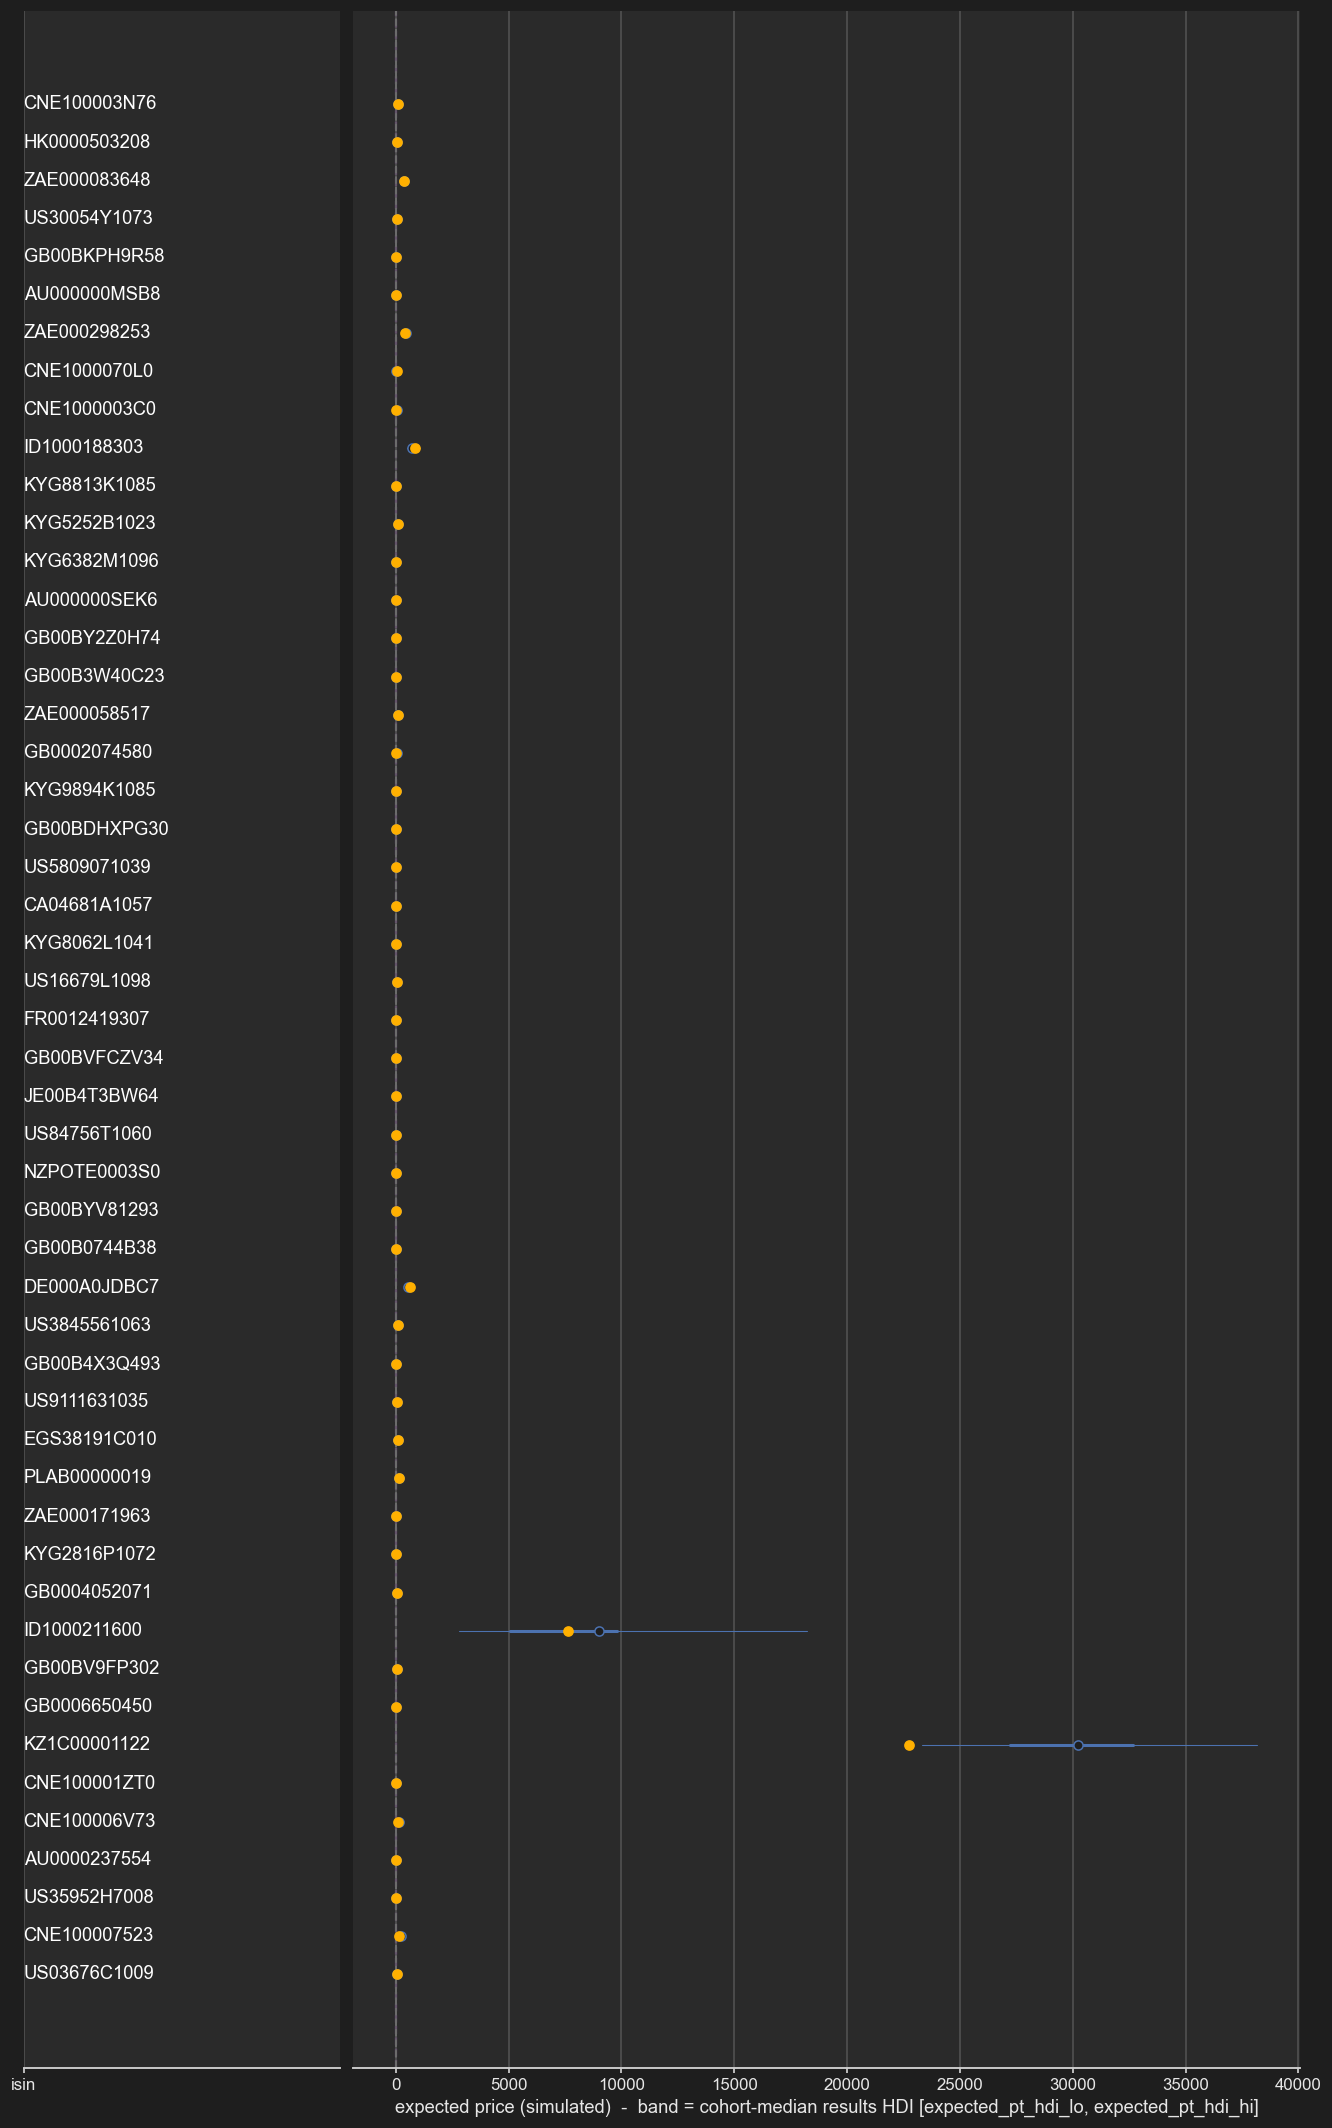

results-df cohort-median 94% HDI band: (22.45, 27.58);  median expected_pt = 24.86;  cohort last_price = 17.90.


In [35]:
# 13a. Posterior-predictive forest with reference bands keyed off the stored `results`
# dataframe (cohort median of expected_pt_hdi_lo/hi) instead of re-pooled posterior draws.
try:
    ppc_tree, keep, forest_isins, cohort_last_price  # defined by the Section 13 forest cell
except NameError:
    print('Run the Section 13 posterior-predictive forest cell first '
          '(ppc_tree / keep / cohort_last_price not in scope).')
else:
    # Reference band straight from the section-10 screening table: cohort-median of the
    # per-ISIN stored 94% HDI bounds, plus the cohort-median smoothed expected_pt.
    band_lo = float(np.nanmedian(keep['expected_pt_hdi_lo']))
    band_hi = float(np.nanmedian(keep['expected_pt_hdi_hi']))
    band_med = float(np.nanmedian(keep['expected_pt']))

    pc2 = azp.plot_forest(
        ppc_tree, group='posterior_predictive', combined=True,
        labels=['isin'], backend='matplotlib',
    )
    pc2.map(
        azv.scatter_x, 'observations',
        data=ppc_tree.observed_data.ds, coords={'column': 'forest'},
        color='#ffb000',
    )
    pc2.map(
        azv.labelled_x, 'xlabel', coords={'column': 'forest'},
        text='expected price (simulated)  -  band = cohort-median results HDI '
             '[expected_pt_hdi_lo, expected_pt_hdi_hi]',
        ignore_aes='y',
    )
    pc2.coords = {'column': 'forest'}
    # Band from results df; reference lines = cohort-median expected_pt and last_price.
    pc2 = azp.add_bands(pc2, values=[(band_lo, band_hi)],
                        visuals={'ref_band': {'color': '#9b59b6', 'alpha': 0.15}})
    pc2 = azp.add_lines(pc2, values=band_med,
                        visuals={'ref_line': {'color': '#9b59b6', 'linewidth': 1.4}})
    pc2 = azp.add_lines(pc2, values=cohort_last_price,
                        visuals={'ref_line': {'color': '#bbbbbb',
                                              'linestyle': '--', 'linewidth': 1.3}})
    pc2.show()
    print(f'results-df cohort-median 94% HDI band: ({band_lo:.2f}, {band_hi:.2f});  '
          f'median expected_pt = {band_med:.2f};  cohort last_price = {cohort_last_price:.2f}.')


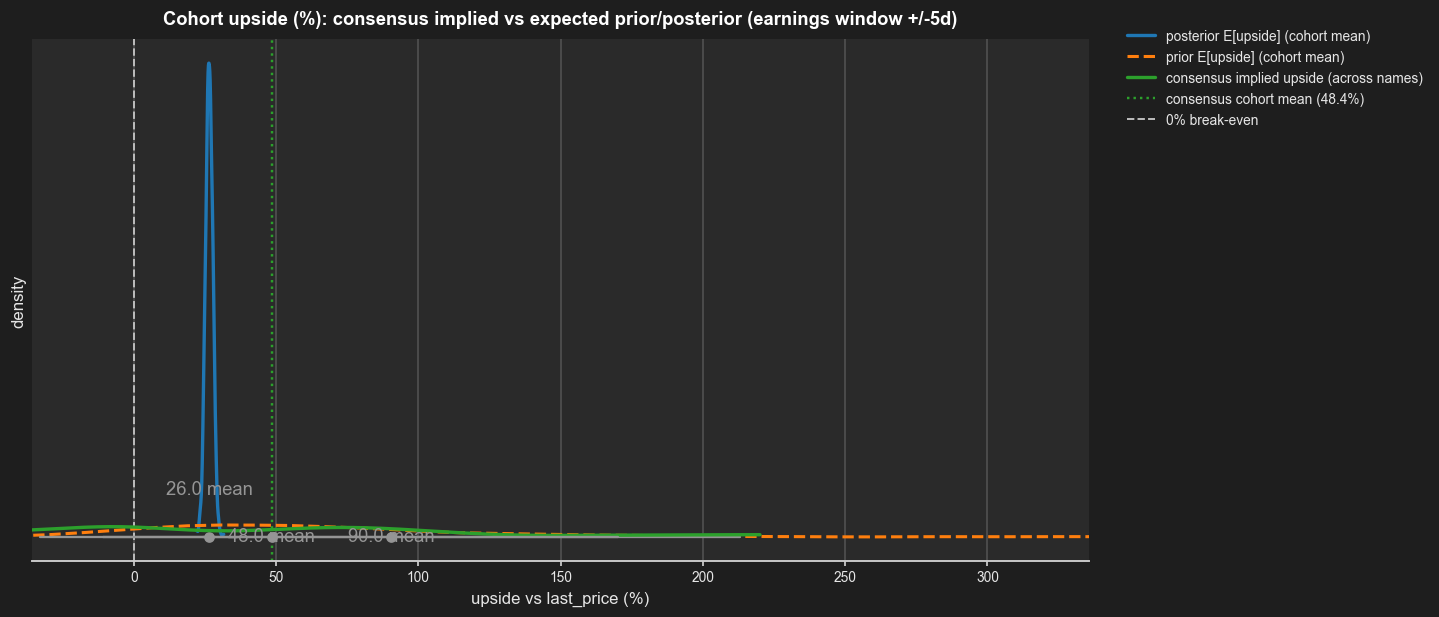

Consensus implied upside [feat_implied_upside (SSOT)]: cohort mean = 48.41% across 50 names.
Expected upside (cohort mean): prior = 90.48%, posterior = 26.47%;  P(posterior cohort upside > 0) = 100.0%;  P(posterior cohort upside > consensus mean) = 0.0%.


In [36]:
# 13b. Cohort distribution KDE (arviz_plots.plot_dist): implied upside vs expected return.
# Overlays three KDEs on one axis for the earnings-window cohort (forest_isins):
#   * posterior E[upside]      - cohort-average `expected_upside` per (chain, draw).
#   * prior E[upside]          - same statistic from the §6 prior predictive (shows the update).
#   * consensus implied upside - `feat_implied_upside` = (observed_pt - last_price)/last_price,
#                                drawn as its cross-name dispersion across the cohort.
# Reference lines: 0% break-even and the consensus cohort-mean implied upside.
# NOTE: prior/posterior KDEs are distributions of the cohort *mean* (uncertainty in the mean);
# the consensus KDE is the spread *across names* - same %-upside units, different statistic.
try:
    idata, prior_idata, model_df, forest_isins  # §5/§6 and the §13 forest cell
except NameError:
    print('Run the Section 6 prior-predictive cell and the Section 13 posterior-predictive '
          'forest cell first (idata / prior_idata / model_df / forest_isins not in scope).')
else:
    from matplotlib.lines import Line2D

    VAR = 'cohort_expected_upside_pct'
    _fi = [str(s) for s in forest_isins]


    def _cohort_mean_pct(da):
        """Cohort-average expected upside (%) over forest_isins, keeping (chain, draw)."""
        return (da.sel(isin=forest_isins).mean('isin') * 100.0).rename(VAR)


    def _consensus_upside_pct():
        """Per-name consensus upside (%): SSOT feat_implied_upside, else observed_pt/last_price-1."""
        m = model_df.set_index(model_df['isin'].astype(str))
        if 'feat_implied_upside' in m.columns:
            s, src = m['feat_implied_upside'].astype('float64'), 'feat_implied_upside (SSOT)'
        else:
            s = m['observed_pt'].astype('float64') / m['last_price'].astype('float64') - 1.0
            src = 'observed_pt/last_price - 1 (fallback)'
        return (s.reindex(_fi).dropna() * 100.0), src


    cohort_upside = _cohort_mean_pct(idata.posterior['expected_upside'])
    prior_cohort = _cohort_mean_pct(prior_idata.prior['expected_upside'])
    _cons, _cons_src = _consensus_upside_pct()
    cons_da = xr.DataArray(_cons.to_numpy(), dims='isin',
                           coords={'isin': _cons.index.to_numpy()}).rename(VAR)

    _C_POST, _C_PRIOR, _C_CONS, _C_REF = '#1f77b4', '#ff7f0e', '#2ca02c', '#bbbbbb'
    # (data, sample_dims, line style, legend label) — single source of truth for plot + legend.
    series = [
        (cohort_upside, ['chain', 'draw'], dict(color=_C_POST, linewidth=2.2),
         'posterior E[upside] (cohort mean)'),
        (prior_cohort, ['chain', 'draw'], dict(color=_C_PRIOR, linewidth=2.0, linestyle='--'),
         'prior E[upside] (cohort mean)'),
    ]
    if len(_cons) >= 2:  # need >=2 names for a cross-name KDE
        series.append((cons_da, ['isin'], dict(color=_C_CONS, linewidth=2.2),
                       'consensus implied upside (across names)'))

    # A larger canvas + constrained_layout that *reserves* room for the external
    # legend. The previous (9, 4.5) figure with an outside legend at
    # bbox_to_anchor=(1.02, 1) left no horizontal space for the axes, so
    # constrained_layout collapsed the axes to zero size ("axes sizes collapsed
    # to zero" warning) and the KDE was unreadable.
    pc3 = None
    for da, sample_dims, style, _ in series:
        pc3 = azp.plot_dist(
            da.to_dataset(), kind='kde', var_names=[VAR], sample_dims=sample_dims,
            backend='matplotlib', plot_collection=pc3,
            visuals={'dist': style},
            **({'figure_kwargs': {'figsize': (13, 5.5), 'layout': 'constrained'}}
               if pc3 is None else {}),
        )

    if pc3 is None:  # series always carries posterior + prior, so unreachable
        raise RuntimeError('No KDE series to plot (expected posterior + prior).')
    ax = pc3.get_target(VAR, {})
    fig = ax.get_figure()
    cons_mean = float(_cons.mean()) if len(_cons) else float('nan')
    ax.axvline(0.0, color=_C_REF, linestyle='--', linewidth=1.3, zorder=1)
    if np.isfinite(cons_mean):
        ax.axvline(cons_mean, color=_C_CONS, linestyle=':', linewidth=1.6, zorder=1)

    # Dynamic x-range: clip to robust percentiles so wide prior / consensus tails
    # don't squash the posterior KDE.
    _all = np.concatenate([cohort_upside.values.ravel(), prior_cohort.values.ravel(),
                           _cons.to_numpy()])
    _lo, _hi = np.nanpercentile(_all, [1, 99])
    _pad = 0.05 * (_hi - _lo)
    ax.set_xlim(_lo - _pad, _hi + _pad)

    # Slightly larger, themed decorations for readability.
    ax.set_xlabel('upside vs last_price (%)', fontsize=11)
    ax.set_ylabel('density', fontsize=11)
    ax.tick_params(axis='both', labelsize=9)
    ax.set_title('Cohort upside (%): consensus implied vs expected '
                 'prior/posterior (earnings window +/-5d)', fontsize=12, pad=10)
    handles = [Line2D([0], [0], label=label, **style) for _, _, style, label in series]
    handles += [
        Line2D([0], [0], color=_C_CONS, lw=1.6, ls=':', label=f'consensus cohort mean ({cons_mean:.1f}%)'),
        Line2D([0], [0], color=_C_REF, lw=1.3, ls='--', label='0% break-even'),
    ]
    # Anchor the legend to the *figure* so constrained_layout reserves space for
    # it instead of shrinking the axes; reserve ~22% of the width on the right.
    fig.legend(handles=handles, fontsize=9, loc='upper left',
               bbox_to_anchor=(0.78, 0.97), borderaxespad=0.0, framealpha=0.9)
    try:
        fig.get_layout_engine().set(rect=(0.0, 0.0, 0.76, 1.0))
    except (AttributeError, TypeError):
        pass
    pc3.show()

    _p_pos = float((cohort_upside > 0).mean().values) * 100.0
    _p_vs_cons = (float((cohort_upside > cons_mean).mean().values) * 100.0
                  if np.isfinite(cons_mean) else float('nan'))
    print(f'Consensus implied upside [{_cons_src}]: cohort mean = {cons_mean:.2f}% '
          f'across {len(_cons)} names.')
    print(f'Expected upside (cohort mean): prior = {float(prior_cohort.mean()):.2f}%, '
          f'posterior = {float(cohort_upside.mean()):.2f}%;  '
          f'P(posterior cohort upside > 0) = {_p_pos:.1f}%;  '
          f'P(posterior cohort upside > consensus mean) = {_p_vs_cons:.1f}%.')

## 14. Comprehensive Summary - Recent Earnings Period vs Historical Data

This closing section consolidates the notebook's outputs into a single decision-oriented read
on the **expected price targets for names reporting within +/- 5 days** (`next_earnings`),
benchmarked against the broader **historical / baseline** data:

- **Cross-sectional benchmark** - the earnings cohort vs the rest of the modelled universe
  (the names *not* reporting this week), on expected upside, share positive, credible-band
  width (uncertainty) and Kalman shrinkage vs raw consensus - read from the section-10
  `results` table.
- **Time-series benchmark** - the mingled cohort's analyst-target trail reconstructed from the
  embedded `*_ago` history (section 12): the oldest historical consensus vs the most recent,
  and the latest Kalman-smoothed target's implied upside vs `last_price`.
- **Distributional view** - an `arviz_plots` KDE overlay of the posterior cohort-average vs
  universe-average expected upside, with a 0 % break-even reference line.

All blocks are guarded: the summary degrades to whatever upstream artifacts (`results`,
`cohort_meta`, `comparison`) are present in the kernel, so it still produces a partial read if
the DB-dependent sections were skipped.


Cross-sectional summary - expected price targets by group:


,n_names,median_upside_%,mean_upside_%,positive_upside_%,median_band_width_%,median_shrink_vs_consensus_%,median_n_analysts
group,,,,,,,
Earnings cohort (+/-5d),187,24.43,25.34,90.91,23.49,-2.73,5.0
Historical baseline (not reporting),6097,21.20,21.77,90.03,22.80,-0.17,8.0
Full universe,6284,21.31,21.87,90.05,22.83,-0.20,7.0



Earnings-cohort sector tilt:


,n,median_upside_pct
sector,,
Industrials,46,23.61
Consumer Discretionary,35,26.63
Information Technology,25,23.09
Materials,24,22.96
Health Care,23,30.99
Consumer Staples,17,19.64
Communication Services,7,36.83
Energy,5,20.72
Utilities,5,18.60



KEY INSIGHTS - recent earnings period vs historical data
- 187 names report within +/-5d. Median expected upside 24.4% vs 21.2% for non-reporting names (delta 3.2 pp).
- 91% of the cohort has positive expected upside; median credible band width 23.5% (universe 22.8%).
- Kalman-smoothed targets sit 2.7% below raw consensus (median) - shrinkage toward the hierarchical group mean.
- Highest expected upside: 2696 (82%), 6055 (77%), IMP (77%).
- Lowest / most downside : ATEX (-50%), 2670 (-41%), FCEL (-38%).
- Historical target trail (2021-06-08 -> 2027-01-01): mingled cohort consensus rose 35.7%; latest Kalman-smoothed target implies 21.5% upside vs cohort last price.


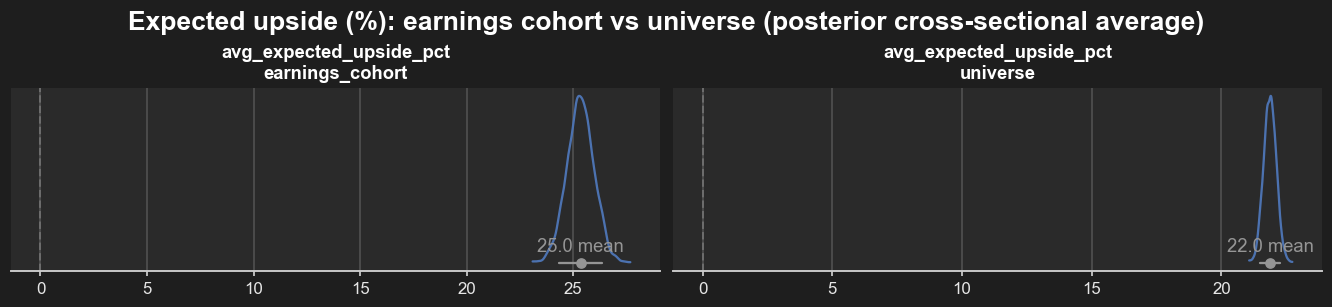

In [37]:
# Section 14: comprehensive earnings-cohort vs historical-data summary. Reuses `results`
# (section 10), `cohort_meta` (section 13), `comparison` (section 12) and `idata` when present.
def _fmt(x, nd=1, suf=''):
    """Format a possibly-NaN/None scalar for narrative output."""
    try:
        if x is None or (isinstance(x, float) and not np.isfinite(x)):
            return 'n/a'
        return f'{x:.{nd}f}{suf}'
    except Exception:
        return 'n/a'


def _label(row):
    t = row.get('ticker')
    return t if isinstance(t, str) and t.strip() else str(row['isin'])


def _band_width_pct(df):
    denom = df['expected_pt'].replace(0, np.nan)
    return (df['expected_pt_hdi_hi'] - df['expected_pt_hdi_lo']) / denom * 100.0


def _shrink_pct(df):
    denom = df['observed_pt'].replace(0, np.nan)
    return (df['expected_pt'] / denom - 1.0) * 100.0


try:
    results
except NameError:
    print('Section 10 `results` not in scope - run sections 5-10 first.')
else:
    universe = results.copy()

    # ---- A. Cross-sectional: earnings cohort vs the rest of the modelled universe ----
    try:
        _cohort_ids = set(cohort_meta['isin'].astype(str))
    except NameError:
        _cohort_ids = None

    if _cohort_ids:
        _in = universe['isin'].astype(str).isin(_cohort_ids)
        cohort, rest = universe[_in].copy(), universe[~_in].copy()
        groups = [('Earnings cohort (+/-5d)', cohort),
                  ('Historical baseline (not reporting)', rest),
                  ('Full universe', universe)]
    else:
        cohort = rest = None
        groups = [('Full universe', universe)]
        print('Section 13 `cohort_meta` not in scope - showing the universe only. '
              'Run Section 13 to populate the earnings cohort comparison.')

    _rows = []
    for label, df in groups:
        if df is None or len(df) == 0:
            continue
        _rows.append({
            'group': label,
            'n_names': int(len(df)),
            'median_upside_%': df['expected_upside_pct'].median(),
            'mean_upside_%': df['expected_upside_pct'].mean(),
            'positive_upside_%': (df['expected_upside_pct'] > 0).mean() * 100.0,
            'median_band_width_%': _band_width_pct(df).median(),
            'median_shrink_vs_consensus_%': _shrink_pct(df).median(),
            'median_n_analysts': (df['n_analysts'].median()
                                  if 'n_analysts' in df else np.nan),
        })
    summary_tbl = pd.DataFrame(_rows).set_index('group').round(2)
    print('Cross-sectional summary - expected price targets by group:')
    display(summary_tbl)

    # Cohort sector tilt (composition of the names reporting this week).
    if cohort is not None and len(cohort) and 'sector' in cohort.columns:
        sector_mix = (cohort.assign(sector=cohort['sector'].fillna('Unknown'))
                      .groupby('sector')
                      .agg(n=('isin', 'size'),
                           median_upside_pct=('expected_upside_pct', 'median'))
                      .sort_values('n', ascending=False).round(2))
        print('\nEarnings-cohort sector tilt:')
        display(sector_mix.head(10))

    # ---- B. Time-series: recent vs historical mingled cohort price-target trail ----
    try:
        _cmp = comparison
    except NameError:
        _cmp = None
    hist_drift = implied_now = first = last = None
    if _cmp is not None and len(_cmp) >= 2:
        first, last = _cmp.iloc[0], _cmp.iloc[-1]
        hist_drift = ((last['observed_pt'] / first['observed_pt'] - 1.0) * 100.0
                      if first['observed_pt'] else np.nan)
        implied_now = ((last['expected_pt'] / last['last_price'] - 1.0) * 100.0
                       if last['last_price'] else np.nan)

    # ---- C. Headline narrative ----
    print('\n' + '=' * 74)
    print('KEY INSIGHTS - recent earnings period vs historical data')
    print('=' * 74)
    if cohort is not None and len(cohort):
        cu = cohort['expected_upside_pct'].median()
        ru = rest['expected_upside_pct'].median() if rest is not None and len(rest) else np.nan
        print(f'- {len(cohort)} names report within +/-5d. Median expected upside '
              f'{_fmt(cu, 1, "%")} vs {_fmt(ru, 1, "%")} for non-reporting names '
              f'(delta {_fmt(cu - ru, 1, " pp")}).')
        print(f'- {_fmt((cohort["expected_upside_pct"] > 0).mean() * 100, 0, "%")} of the cohort '
              f'has positive expected upside; median credible band width '
              f'{_fmt(_band_width_pct(cohort).median(), 1, "%")} '
              f'(universe {_fmt(_band_width_pct(universe).median(), 1, "%")}).')
        sh = _shrink_pct(cohort).median()
        print(f'- Kalman-smoothed targets sit {_fmt(abs(sh), 1, "%")} '
              f'{"above" if sh >= 0 else "below"} raw consensus (median) - shrinkage toward '
              f'the hierarchical group mean.')
        _top = cohort.sort_values('expected_upside_pct', ascending=False).head(3)
        _bot = cohort.sort_values('expected_upside_pct').head(3)
        _names = lambda d: ', '.join(f'{_label(r)} ({_fmt(r["expected_upside_pct"], 0, "%")})'
                                     for _, r in d.iterrows())
        print(f'- Highest expected upside: {_names(_top)}.')
        print(f'- Lowest / most downside : {_names(_bot)}.')
    else:
        print('- Earnings cohort not available (Section 13 was skipped); '
              'cross-sectional cohort insights omitted.')
    if first is not None and last is not None:
        print(f'- Historical target trail ({first["asof_date"]} -> {last["asof_date"]}): mingled '
              f'cohort consensus {"rose" if (hist_drift or 0) >= 0 else "fell"} '
              f'{_fmt(abs(hist_drift), 1, "%")}; latest Kalman-smoothed target implies '
              f'{_fmt(implied_now, 1, "%")} upside vs cohort last price.')
    else:
        print('- Historical mingled trail not available (Section 12 was skipped); '
              'time-series drift insight omitted.')

    # ---- D. Distributional view: cohort vs universe expected upside (arviz_plots KDE) ----
    try:
        if _cohort_ids:
            _eu = idata.posterior['expected_upside'] * 100.0
            _modelled = set(_eu.coords['isin'].values.astype(str).tolist())
            _cohort_post = [i for i in _cohort_ids if i in _modelled]
            if _cohort_post:
                _cohort_avg = _eu.sel(isin=_cohort_post).mean('isin')
                _univ_avg = _eu.mean('isin')
                _stacked = xr.concat(
                    [_cohort_avg, _univ_avg],
                    dim=pd.Index(['earnings_cohort', 'universe'], name='group'),
                ).rename('avg_expected_upside_pct')
                pc_sum = azp.plot_dist(
                    _stacked.to_dataset(), kind='kde',
                    var_names=['avg_expected_upside_pct'],
                    sample_dims=['chain', 'draw'], backend='matplotlib',
                )
                pc_sum.add_title('Expected upside (%): earnings cohort vs universe '
                                 '(posterior cross-sectional average)')
                pc_sum = azp.add_lines(
                    pc_sum, values=0.0,
                    visuals={'ref_line': {'color': '#bbbbbb',
                                          'linestyle': '--', 'linewidth': 1.3}},
                )
                pc_sum.show()
    except Exception as _e:  # pragma: no cover - plot is best-effort
        print(f'Summary KDE overlay skipped: {_e!r}')